# Búsqueda de Grover para la recuperación de secretos LWE

In [211]:
import numpy as np
import qiskit
import matplotlib
import notebook
from qiskit.visualization import array_to_latex, plot_histogram
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
import math
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt


In [212]:
#Umbral elegido para decidir si un residuo es suficientemente pequeño
TAU = 1

### Generación de instancias LWE

In [213]:
#Función para generar instancias LWE
def generar_lwe(n, m, q):

    #Generar matriz A pública aleatoria
    A = np.random.randint(0, q, size=(m, n))

    #Generar secreto s aleatorio
    s = np.random.randint(0, q, size=n)

    #Gnerar vector de errores e
    e = np.random.choice([-1, 0, 1], size=m)
    
    #Calcular cada b con formula b = A*s + e mod q
    As = np.matmul(A, s)
    b = (As + e) % q
    
    return A, s, e, b

In [214]:
#Función para calcular el vector de residuos r
def calcular_residuo(A, s, b, q):
    #r = b - A*s mod q
    As = np.matmul(A, s)
    r = (b - As) % q
    return r

### Predicado oracular

f(s) = 1 si cada componente del vector de residuos r tiene distancia circular ≤ τ <br>
f(s) = 0 en caso contrario

Distancia circular = min(r, q −r)

In [215]:
#Función para evaluar el predicado oracular
def cumple_condicion(r, q):
    #Sacar el minimo entre r y q-r para cada elemento del vector
    dist = np.minimum(r, q - r)

    #Devuelve true si todos los elementos son menores o iguales a τ
    if np.all(dist <= TAU):
        return True
    else:
        return False

### Oráculo de fase


In [216]:
#Función para transformar el vector s en un vector de bits
def vector_a_bits(s, num_bits, n):
    s_bits = np.array([], dtype=int)
    for i in range(n):
        bits = [int(b) for b in format(s[i], f'0{num_bits}b')]
        s_bits = np.append(s_bits, bits)
    return s_bits

In [217]:
#Función para implementar el circuito del oráculo de fase
def oracle(num_qubits, num_bits, s, n):
    
    #Crear el circuito vacío
    circuito = QuantumCircuit(num_qubits)

    #Pasar s a bits
    s_bits = vector_a_bits(s, num_bits, n)
    print("s en bits:", s_bits)

    #Aplicar X a los 0
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])

    #Aplicar multicontrolled Z para añadir fase de -1
    circuito.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    
    #Deshacer X aplicado
    for bit in enumerate(s_bits):
        if bit[1] == 0:
            circuito.x(bit[0])
    
    return circuito

### Caso de prueba 1:

In [218]:
n1 = 1
m1 = 3
q1 = 8
num_qubits1 = 3
num_bits1 = int(np.ceil(np.log2(q1)))

In [219]:
#Generar instancia LWE
A1, s1, e1, b1 = generar_lwe(n1, m1 ,q1)

display(array_to_latex(A1, prefix="A1"))
display(array_to_latex(s1, prefix="s1"))
display(array_to_latex(b1, prefix="b1"))
display(array_to_latex(e1, prefix="e1"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [220]:
#Calcular residuo
r1 = calcular_residuo(A1, s1, b1, q1)

display(array_to_latex(r1, prefix="r1"))

<IPython.core.display.Latex object>

In [221]:
#Comprobar condición
print("s1 cumple condicion:", cumple_condicion(r1, q1))

s1 cumple condicion: True


s en bits: [0 1 1]


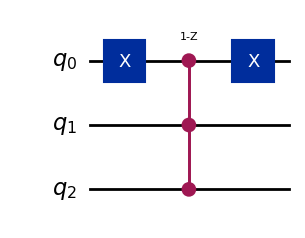

In [222]:
#Crear el circuito del oráculo de fase
circuito1 = oracle(num_qubits1, num_bits1, s1, n1)
display(circuito1.draw(output="mpl"))

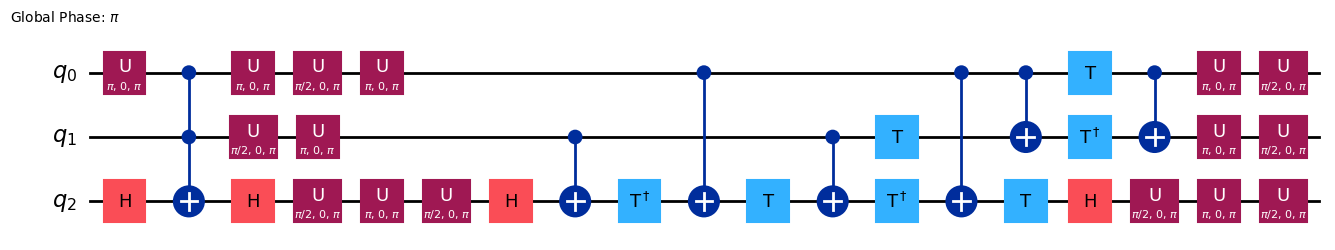

In [223]:
#Construir el operador de Grover
grover_op1 = grover_operator(circuito1)
grover_op1.decompose().draw(output="mpl", style="iqp")

k=1:


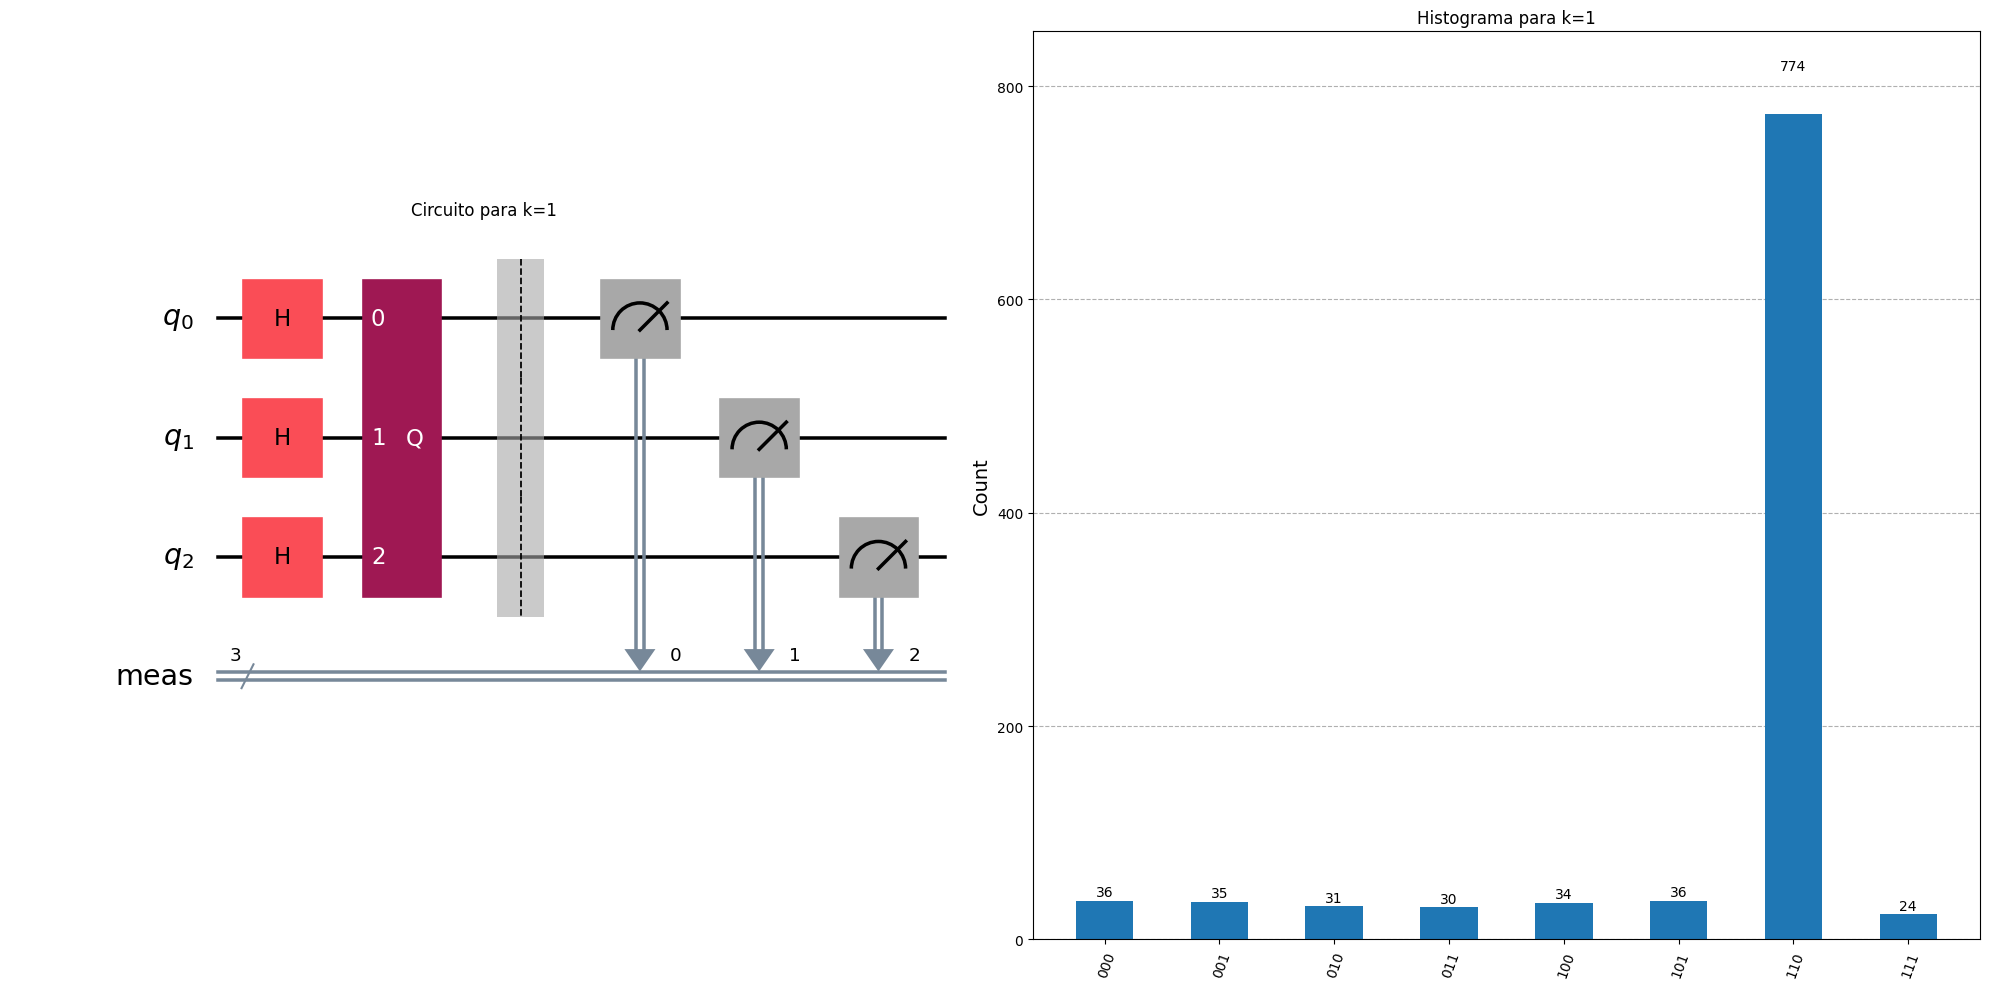

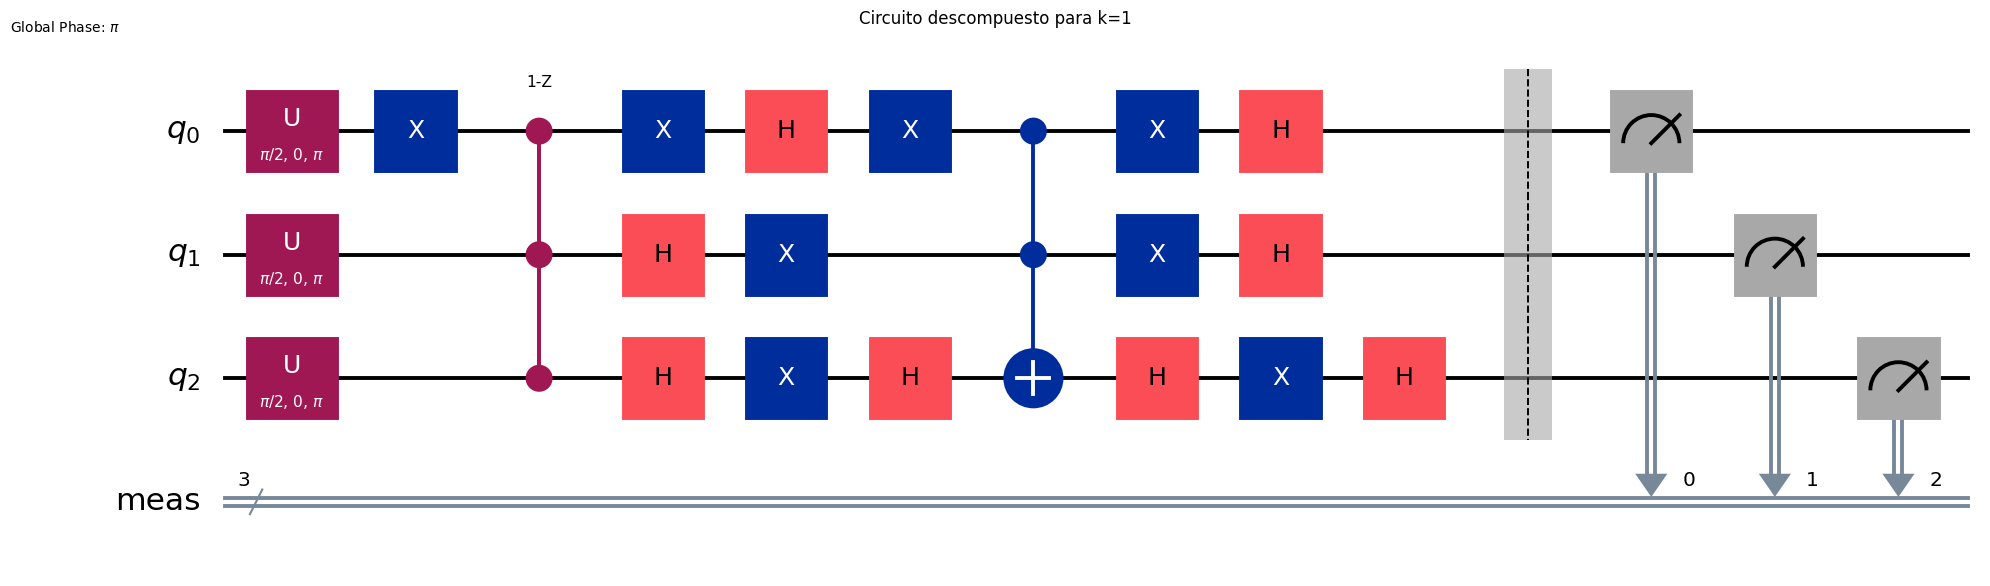

k=2:


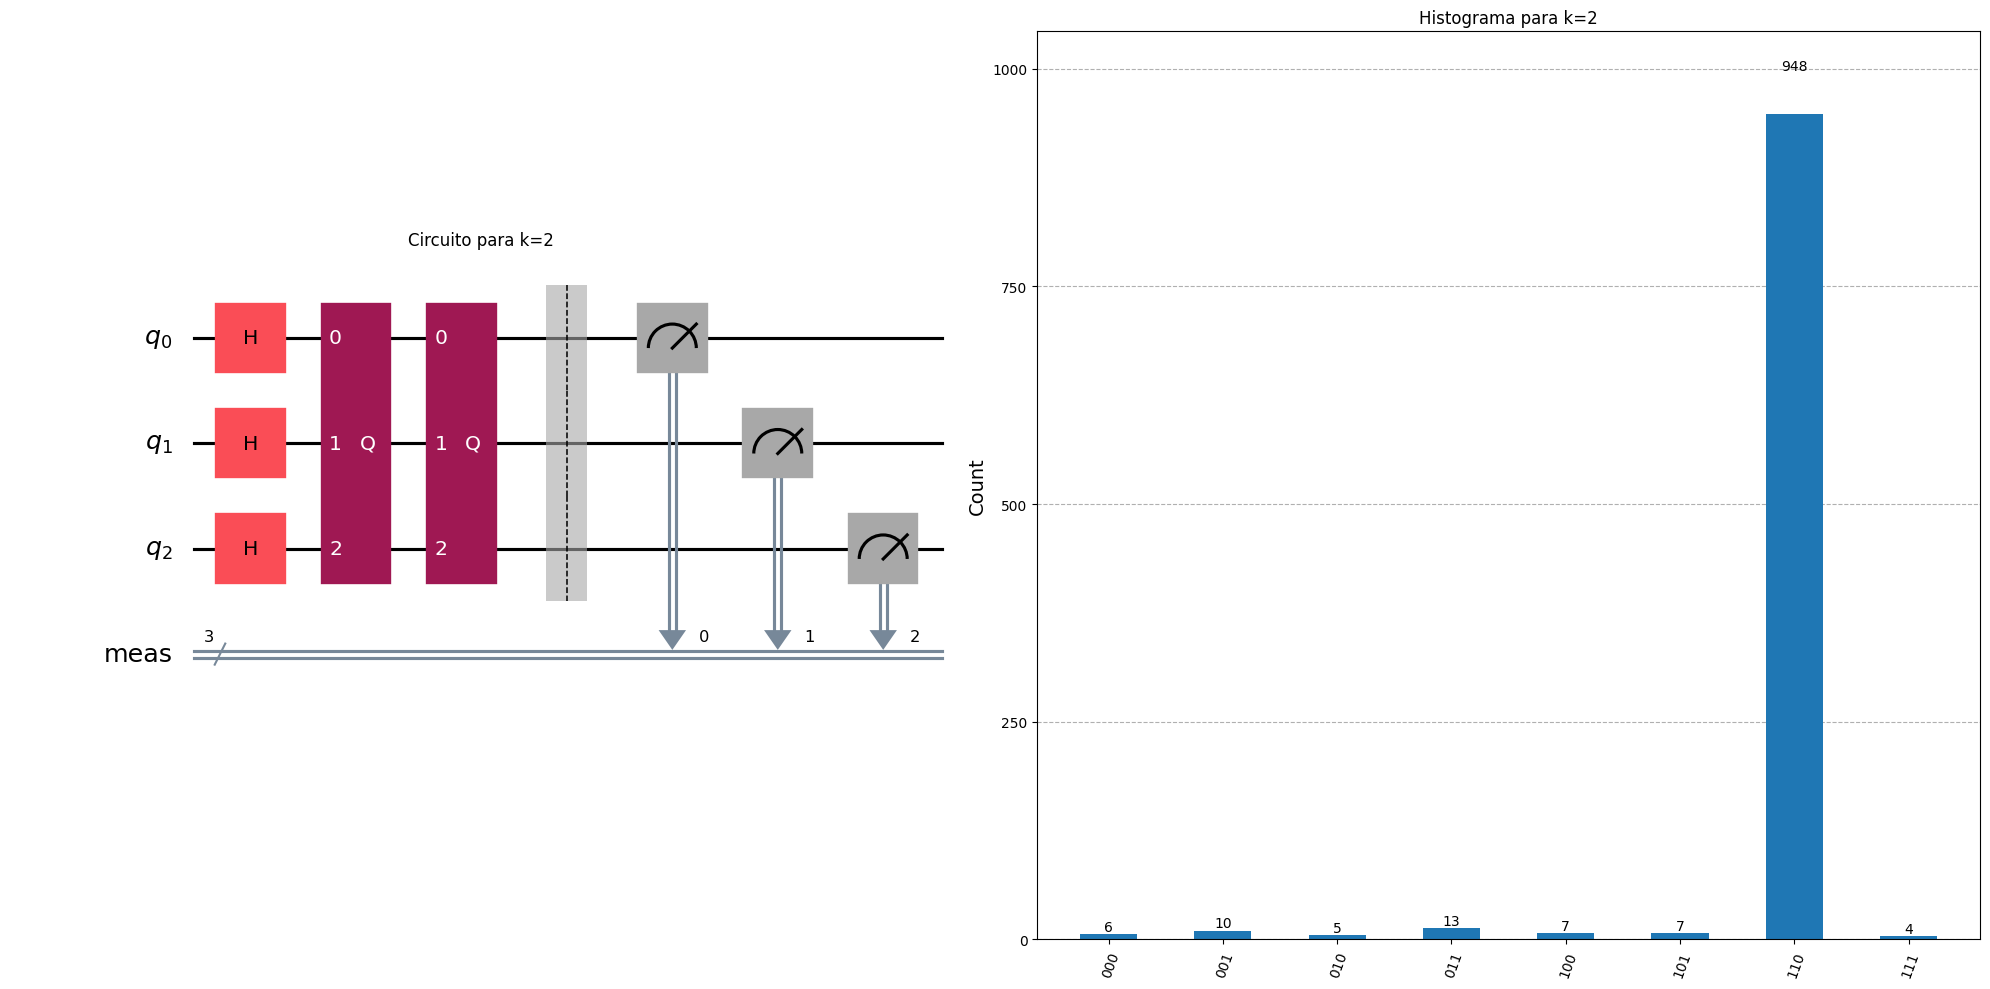

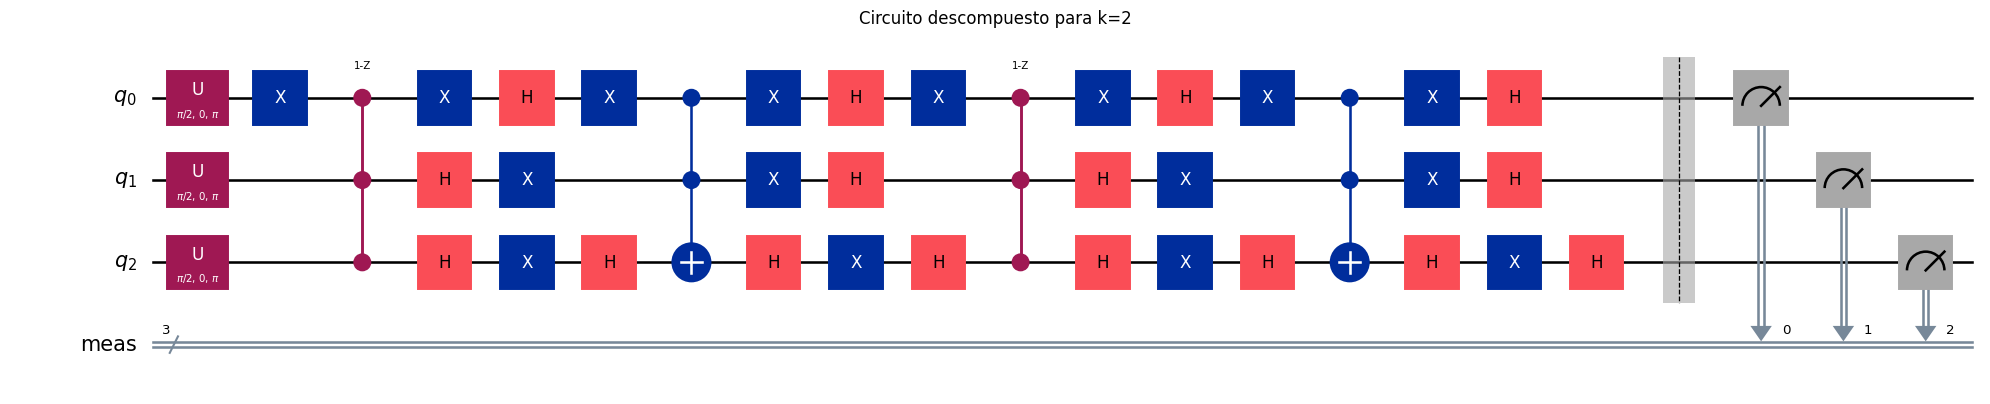

k=3:


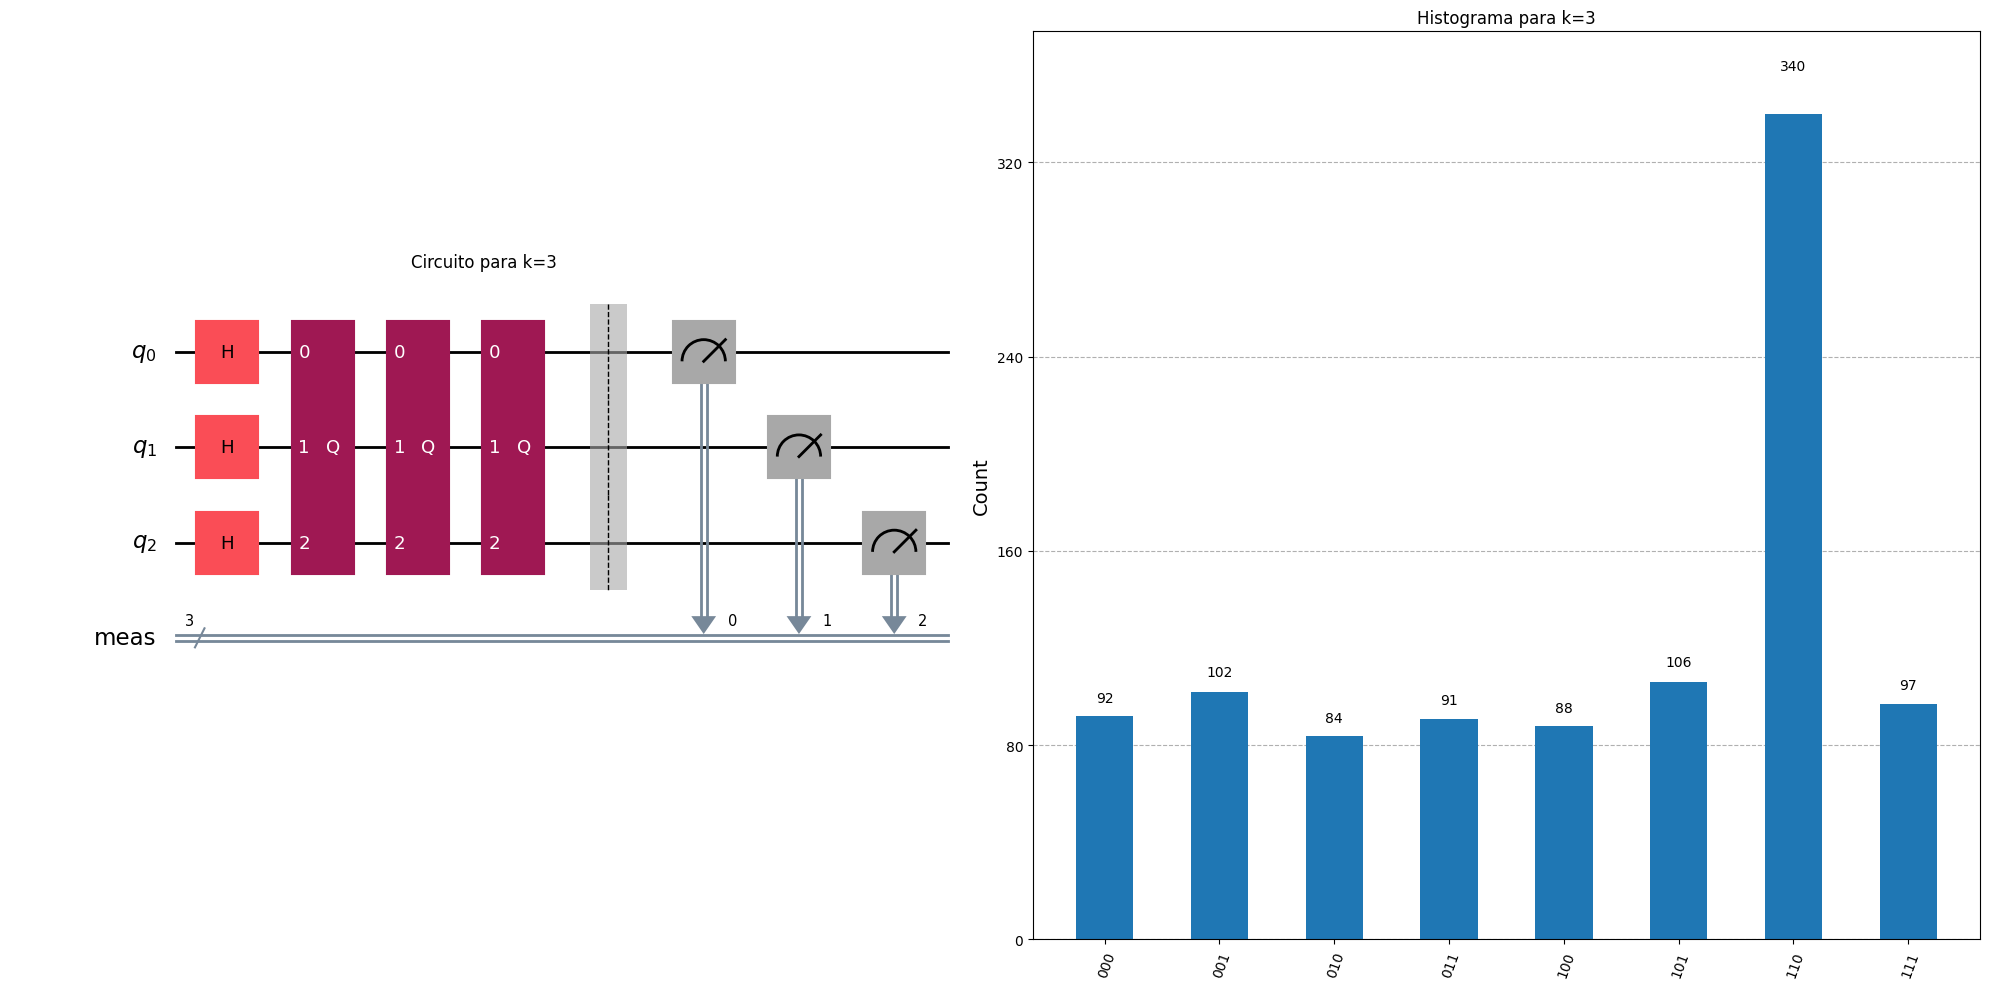

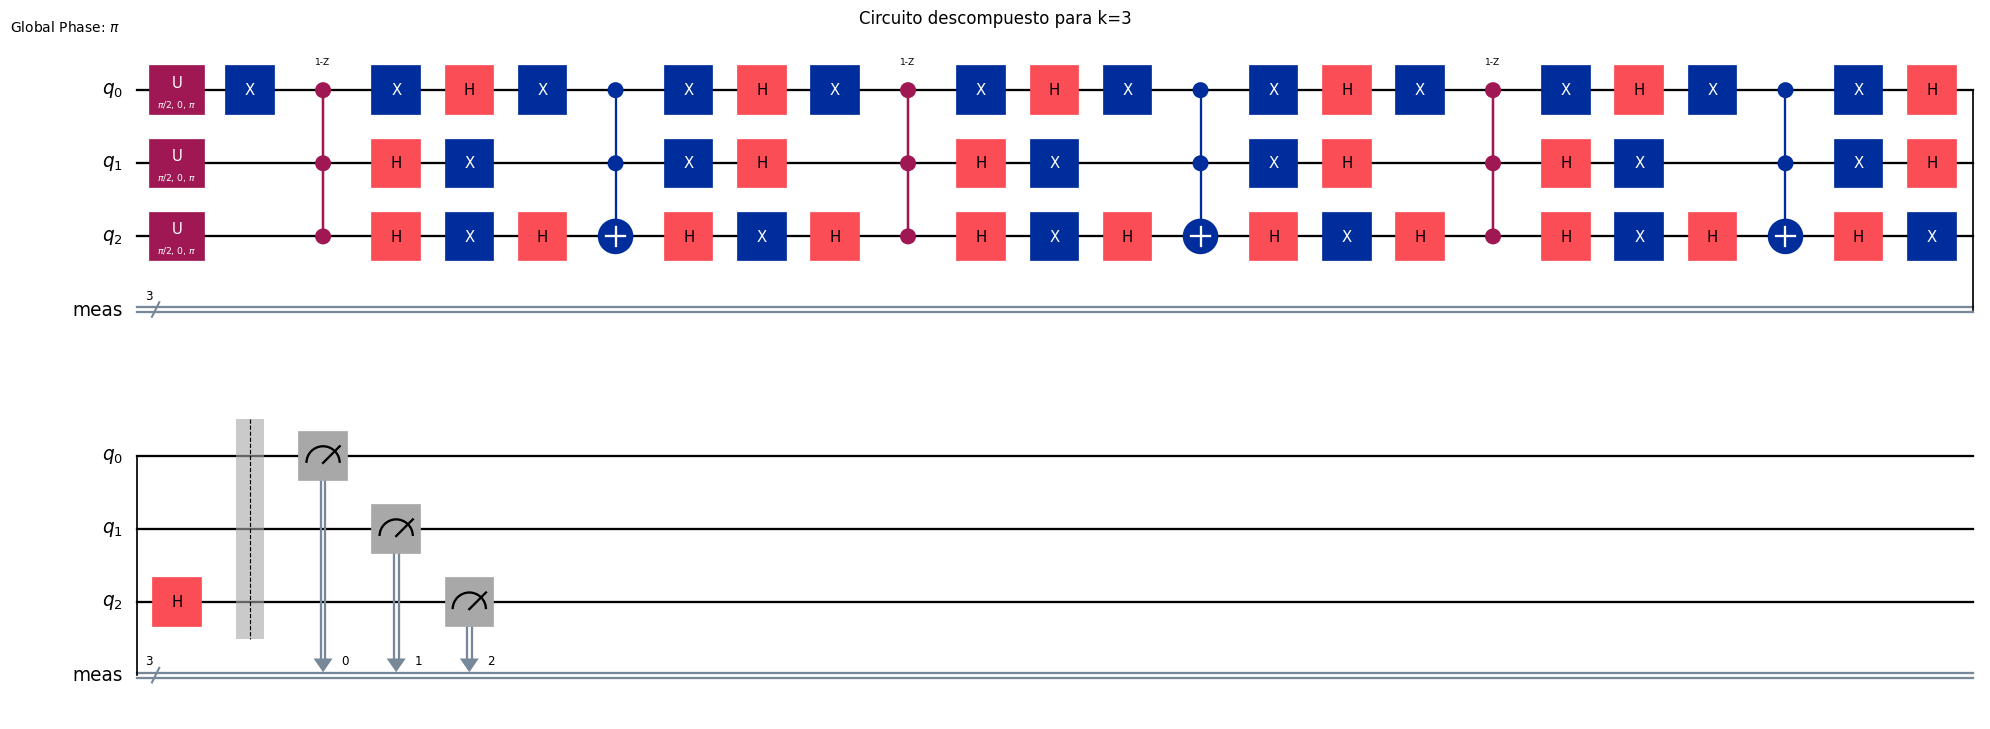

k=4:


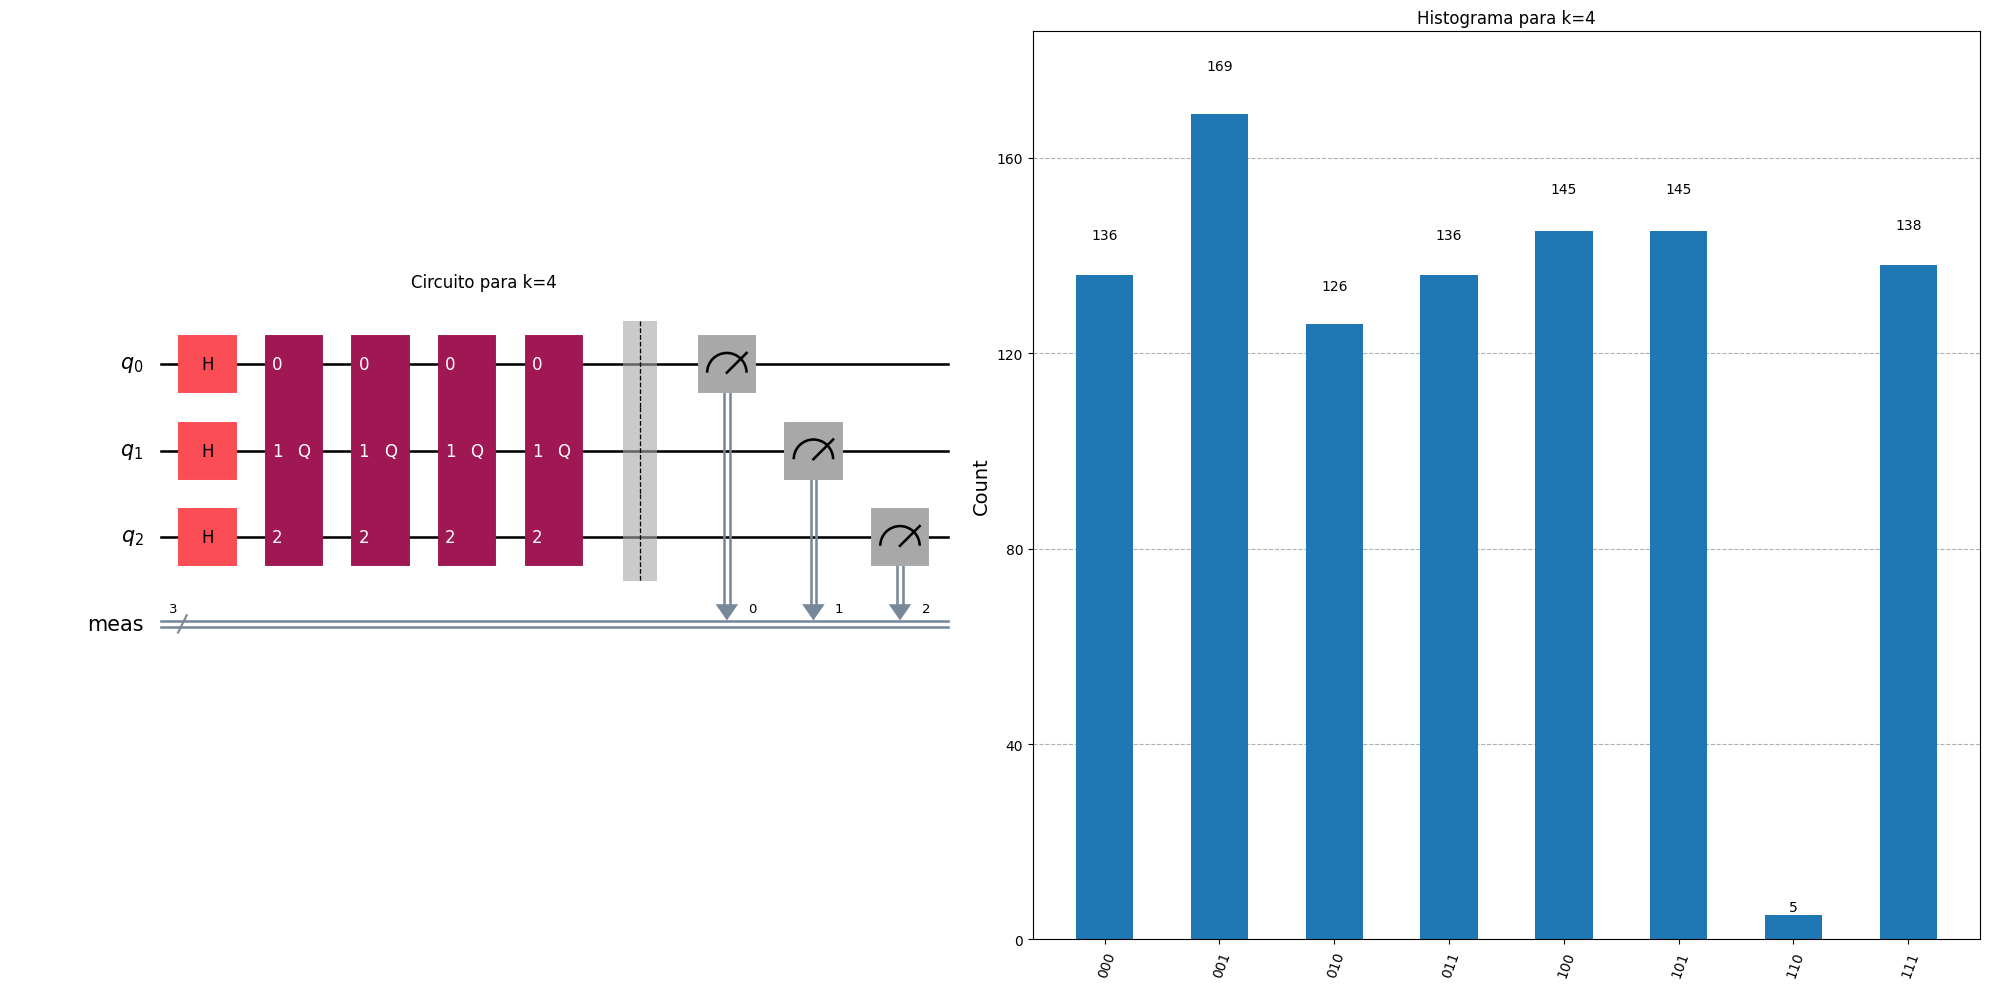

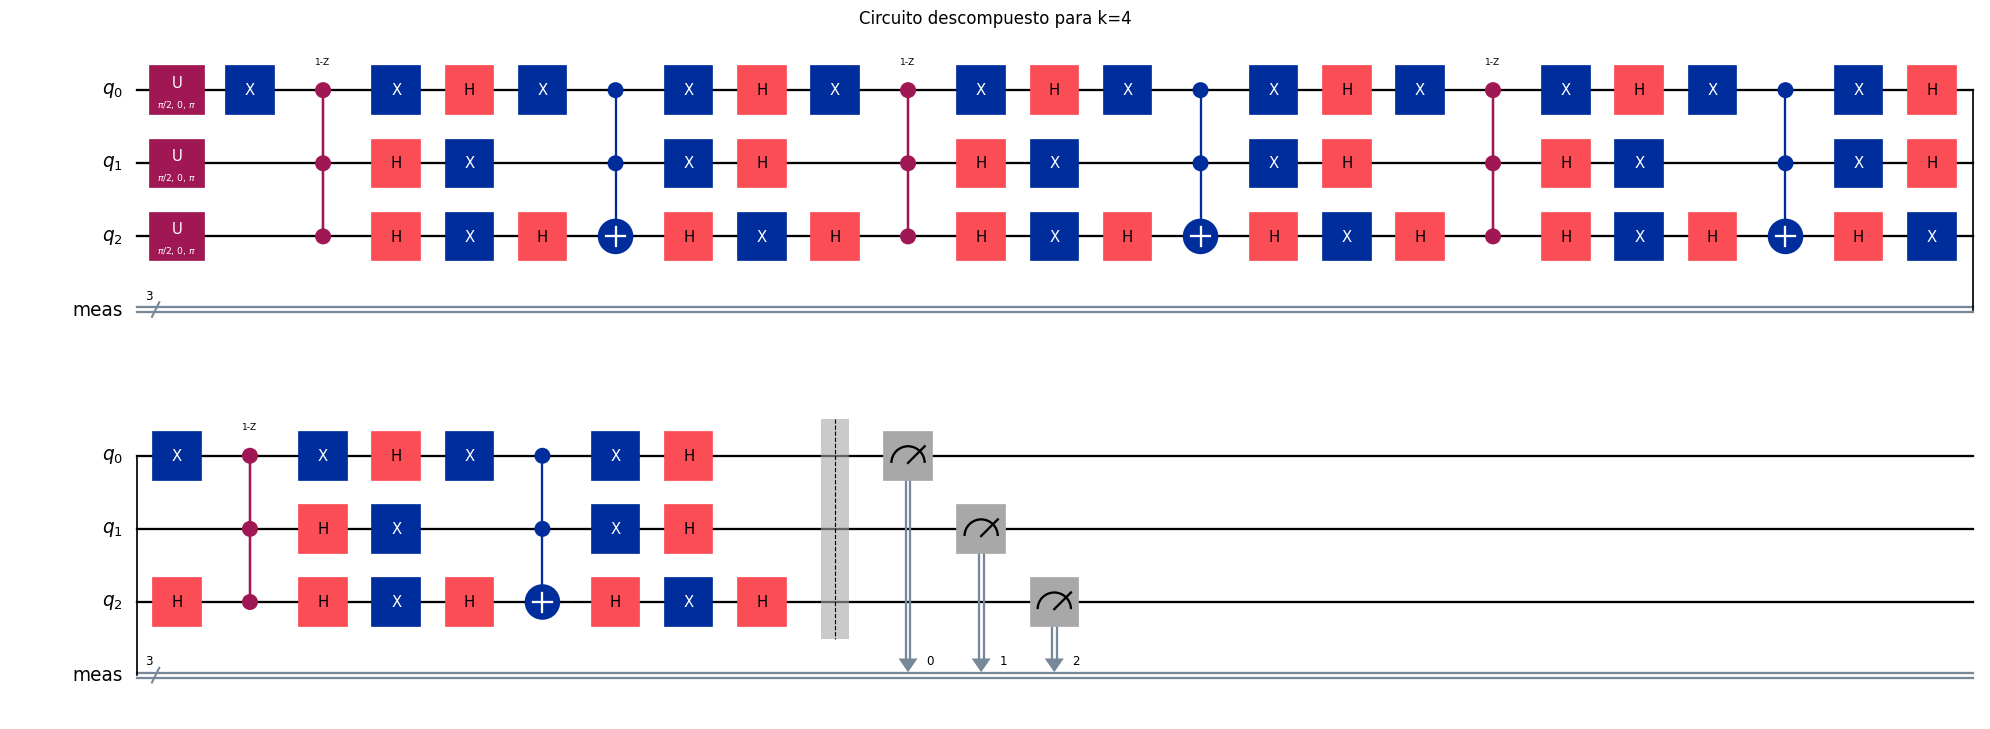

k=5:


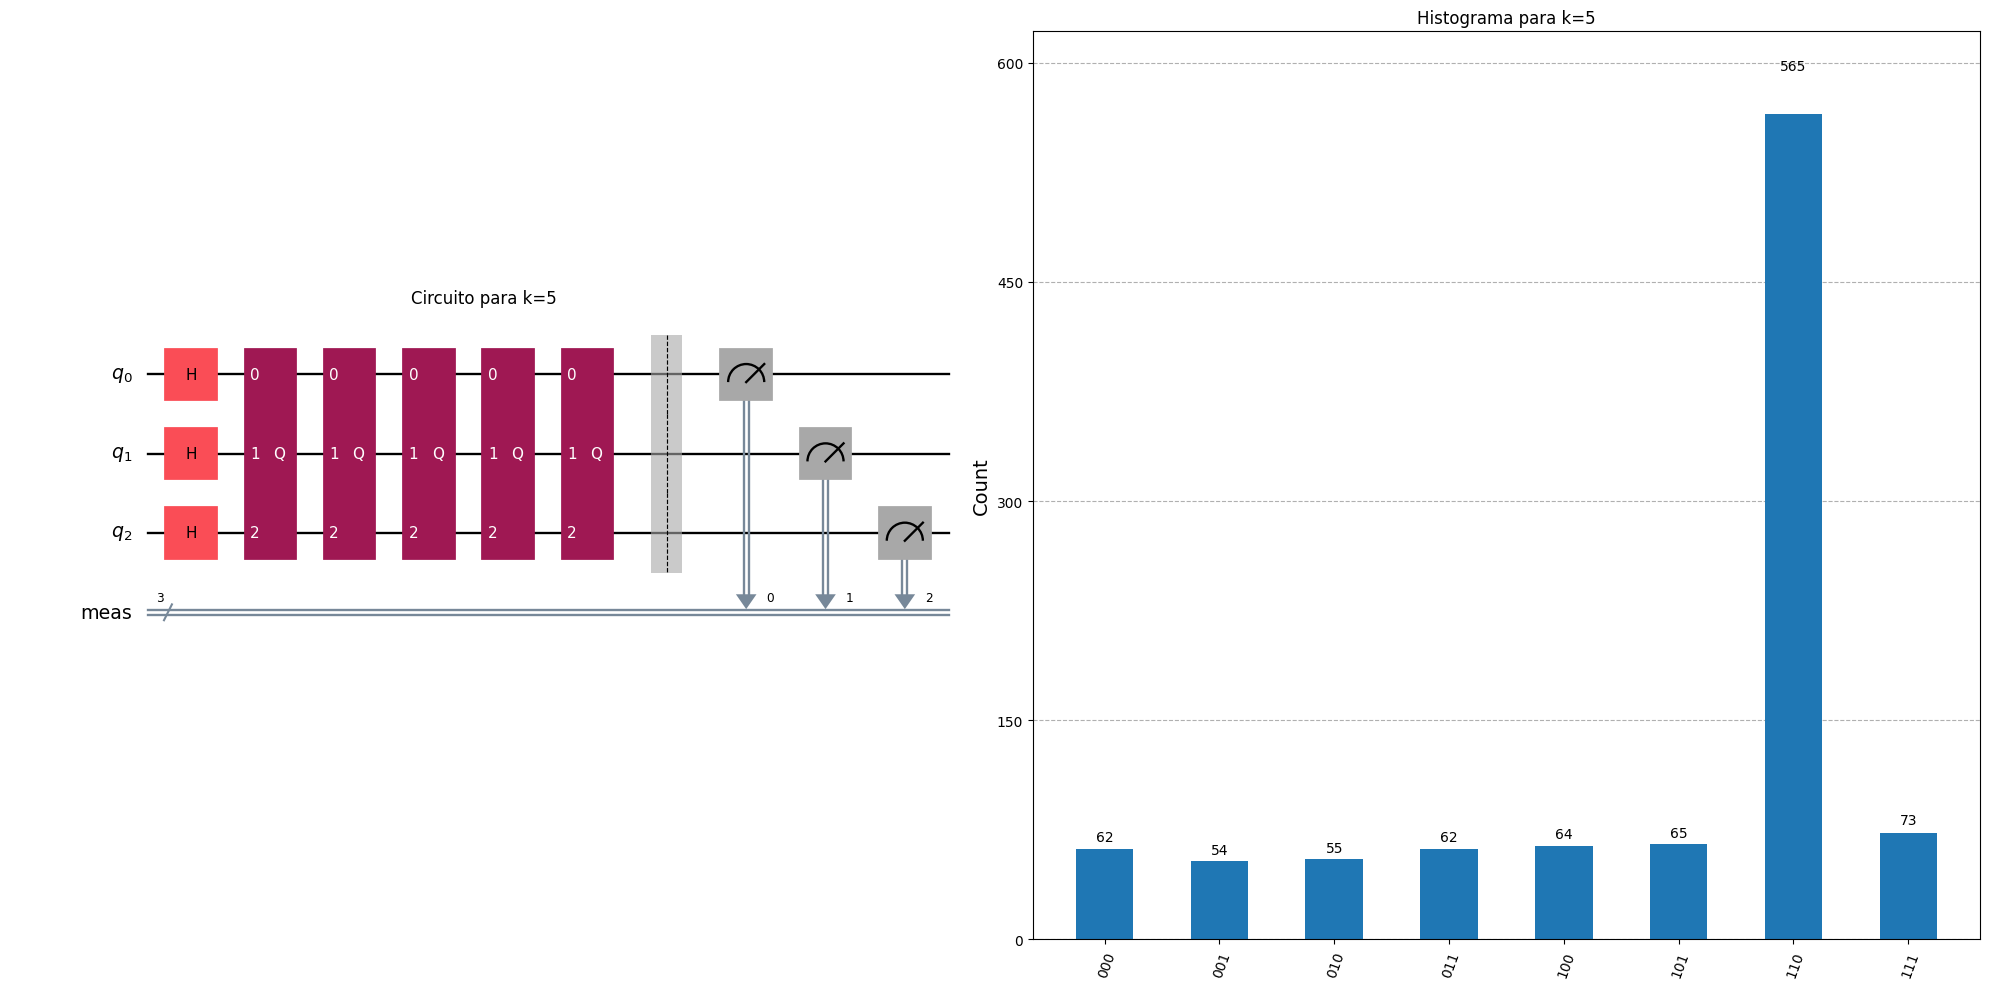

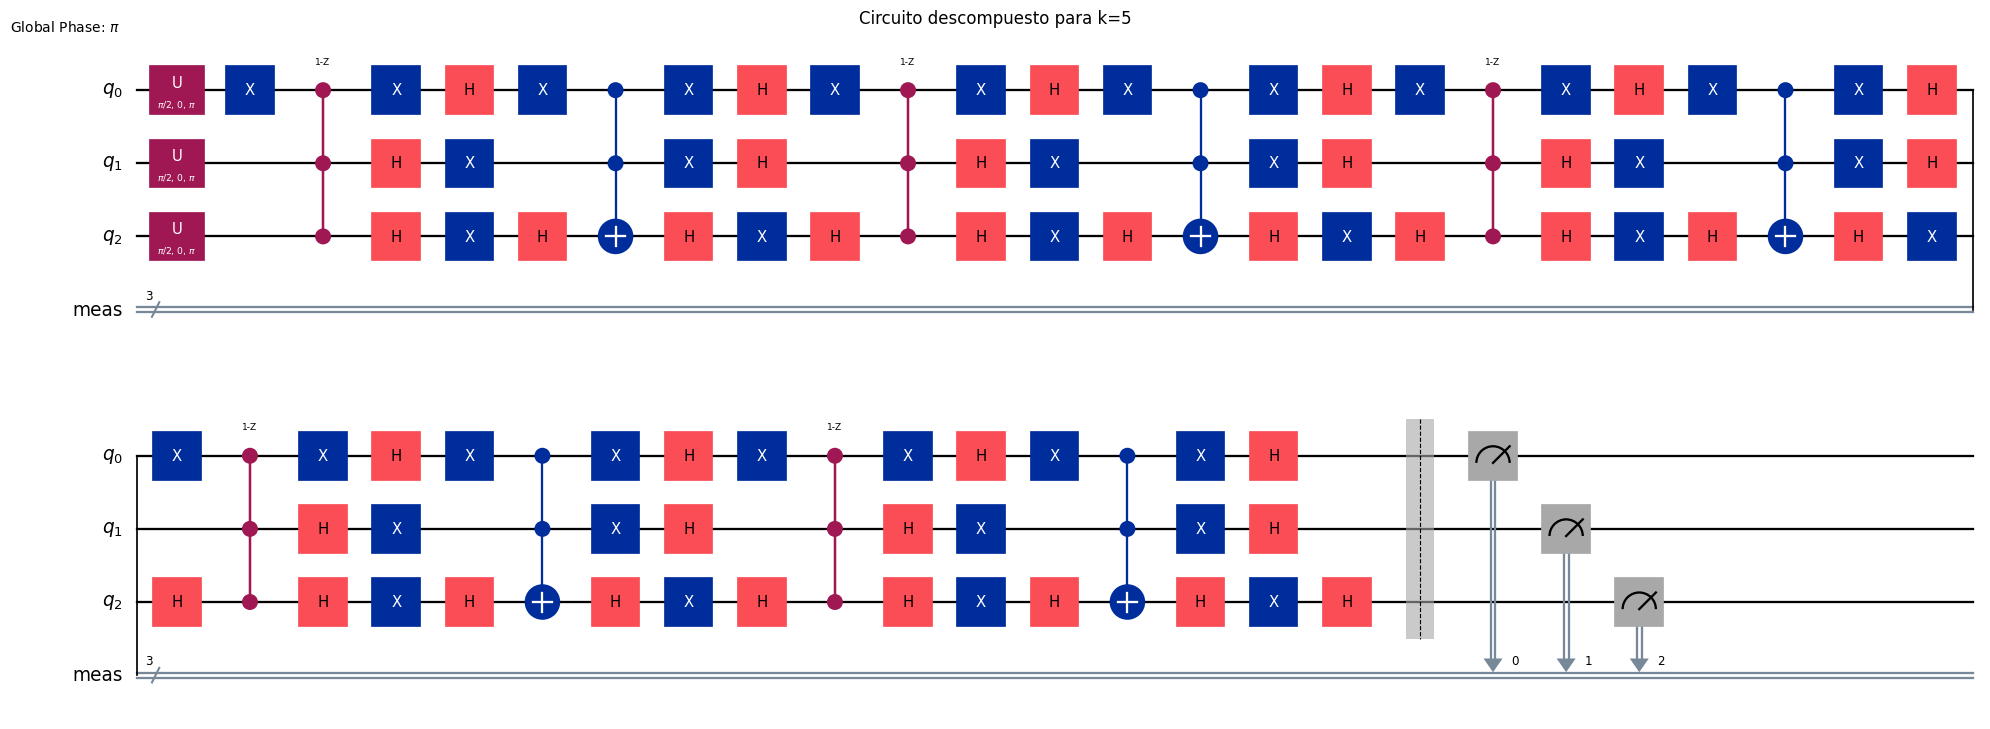

In [224]:
for k in range(1, 6):
    #Crear circuito vacñio
    qc = QuantumCircuit(num_qubits1)

    #Aplicar puertas Hadamard para crear superposición
    qc.h(range(num_qubits1))

    #Aplicar k iteraciones del operador de Grover
    qc.compose(grover_op1.power(k), inplace=True)

    #Simulación
    sv = Statevector.from_instruction(qc)
    #Obtener estadísicas
    statistics = sv.sample_counts(1000)
    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()

    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución de forma experimental con 2 iteraciones.

In [225]:
#Cálculo del valor teorico de iteraciones
it_teoricas1 = (math.pi/4)*math.sqrt(q1**n1)
print("Valor teorico de iteraciones:", it_teoricas1)
it_teoricas_exacto1 = (math.pi/(4*math.asin(1/math.sqrt(q1**n1))))-(1/2)
print("Valor exacto de iteraciones teorico:", it_teoricas_exacto1)

Valor teorico de iteraciones: 2.221441469079183
Valor exacto de iteraciones teorico: 1.6734079041462842


La primera expresión para calcular el número teórico de iteraciones óptimo refleja correctamente el crecimiento asintótico del número de iteraciones. Sin embargo, no nos sirve para elegir el número óptimo entero de iteraciones debido a que en instancias pequeñas.

Para calcularlo, utilizamos la expresión del número exacto de iteraciones teórico y analizamos las probabilidades de éxito en el entero siguiente y el anterior.

In [226]:
prob_anterior1=math.sin(((2*1)+1)*math.asin(1/math.sqrt(q1**n1)))**2
prob_posterior1=math.sin(((2*2)+1)*math.asin(1/math.sqrt(q1**n1)))**2
print("Probabilidad de éxito con 1 iteraciones:", prob_anterior1)
print("Probabilidad de éxito con 2 iteraciones:", prob_posterior1)

Probabilidad de éxito con 1 iteraciones: 0.7812499999999999
Probabilidad de éxito con 2 iteraciones: 0.9453125000000001


En este caso, la probabilidad es bastante mayor tras 2 iteraciones, por lo que podemos concluir que el entero óptimo es 2. Este resultado es el mismo que se ha obtenido experimentalmente.

### Caso de prueba 2:

In [227]:
n2 = 2
m2 = 5
q2 = 4
num_qubits2 = 4
num_bits2 = int(np.ceil(np.log2(q2)))

In [228]:
#Generar instancia LWE
A2, s2, e2, b2 = generar_lwe(n2, m2, q2)

display(array_to_latex(A2, prefix="A2"))
display(array_to_latex(s2, prefix="s2"))
display(array_to_latex(e2, prefix="e2"))
display(array_to_latex(b2, prefix="b2"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [229]:
#Calcular residuo
r2 = calcular_residuo(A2, s2, b2, q2)

display(array_to_latex(r2, prefix="r2"))

<IPython.core.display.Latex object>

In [230]:
#Comprobar condición 
print("s2 cumple condicion:", cumple_condicion(r2, q2))

s2 cumple condicion: True


s en bits: [0 1 1 0]


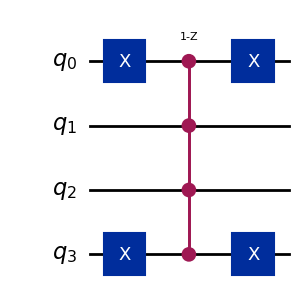

In [231]:
#Crear el circuito del oráculo de fase
circuito2 = oracle(num_qubits2, num_bits2, s2, n2)
display(circuito2.draw(output="mpl"))

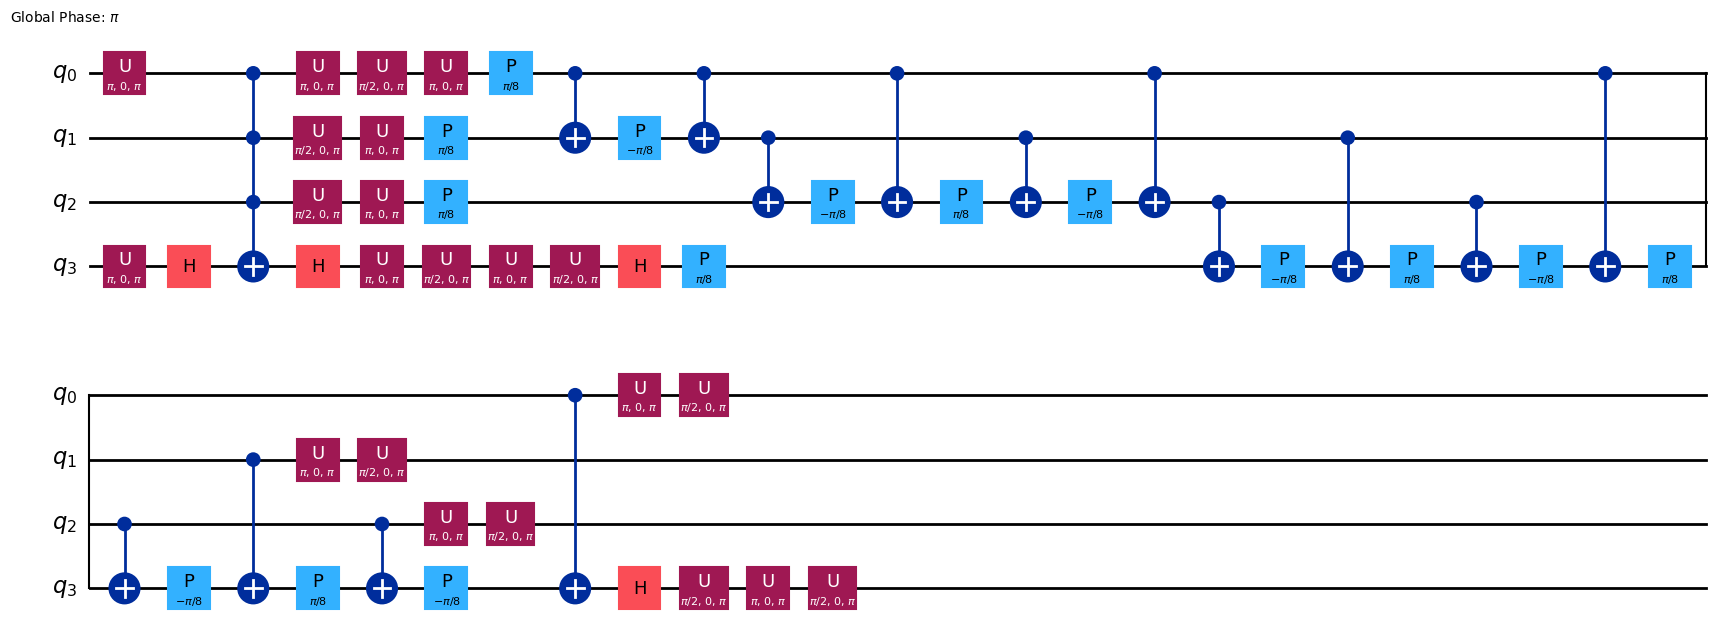

In [232]:
#Construir el operador de Grover
grover_op2 = grover_operator(circuito2)
grover_op2.decompose().draw(output="mpl", style="iqp")

k=1:


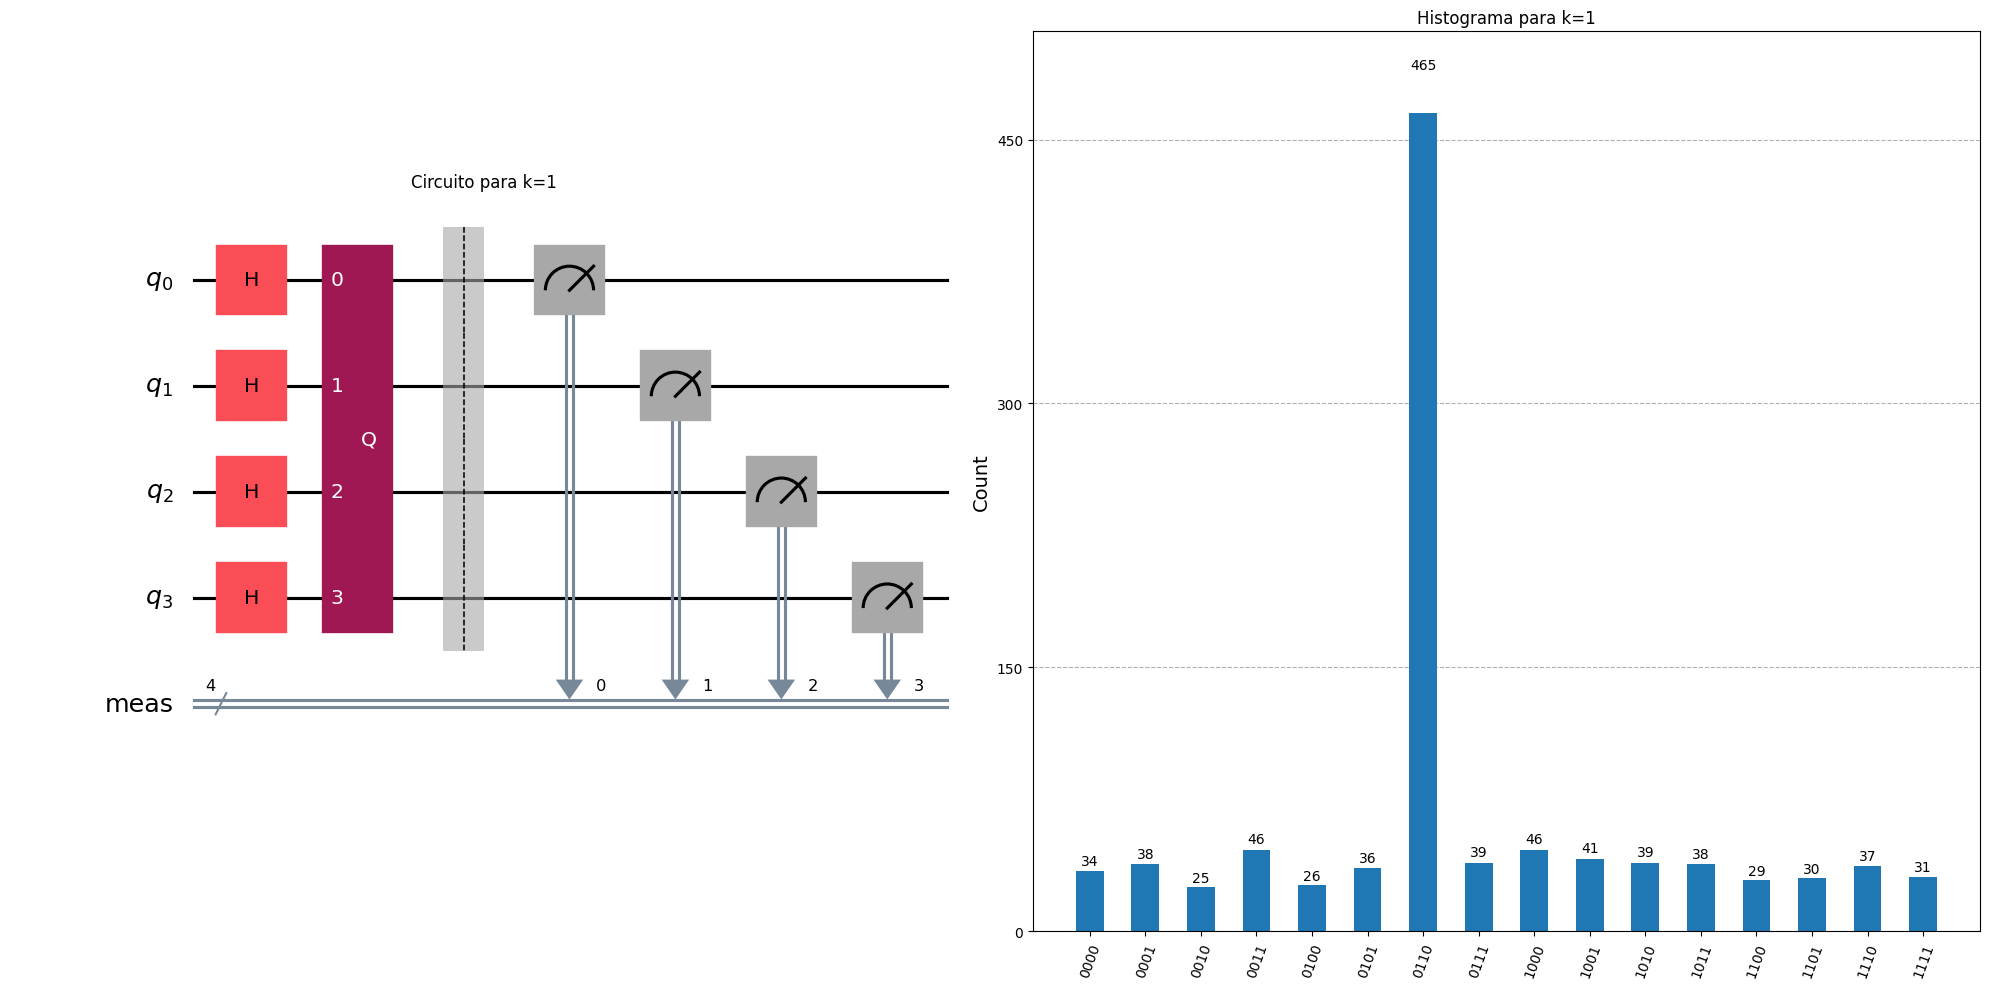

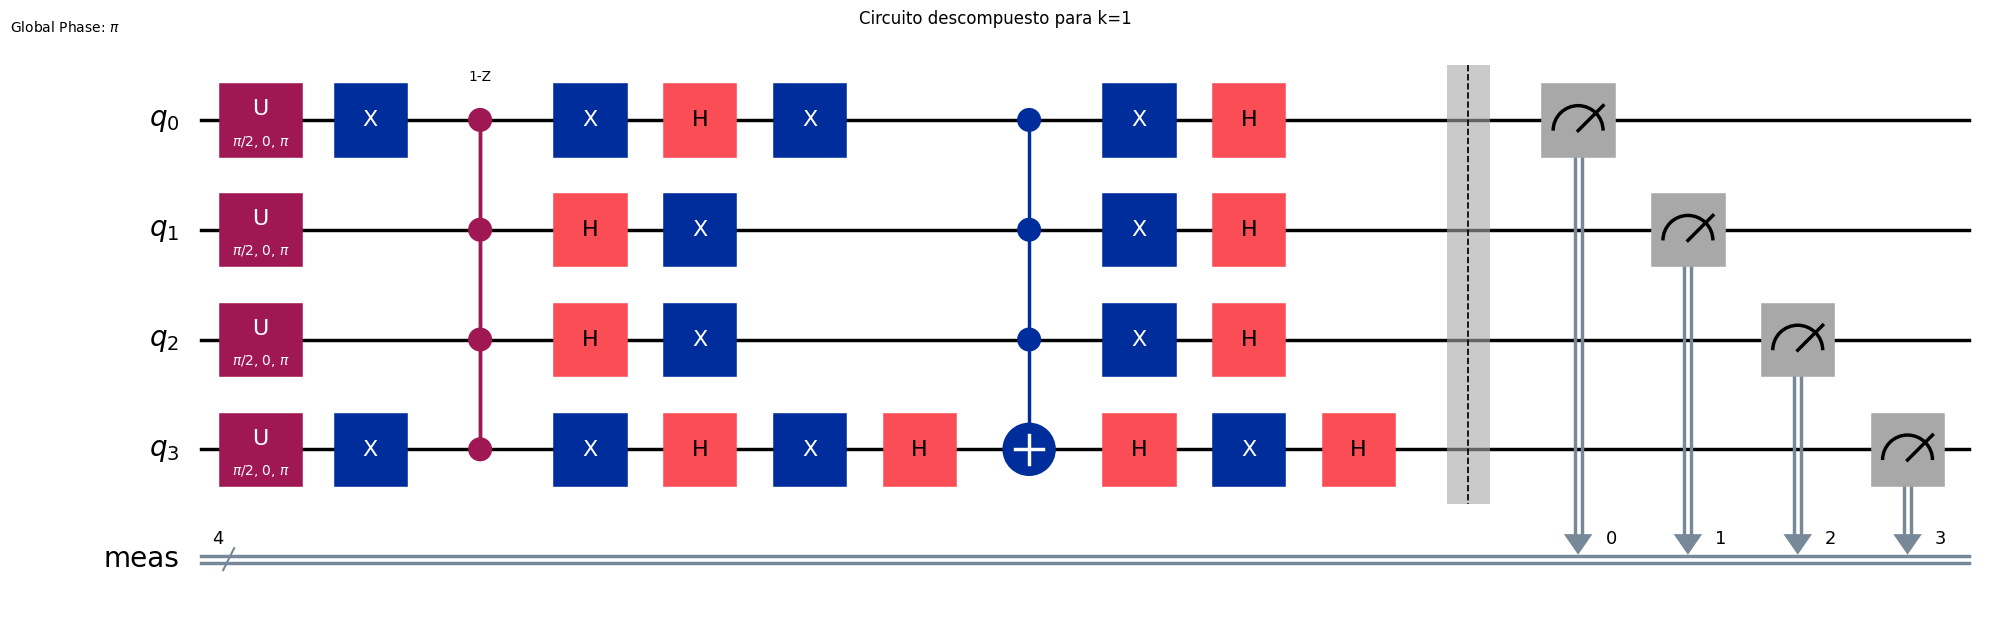

k=2:


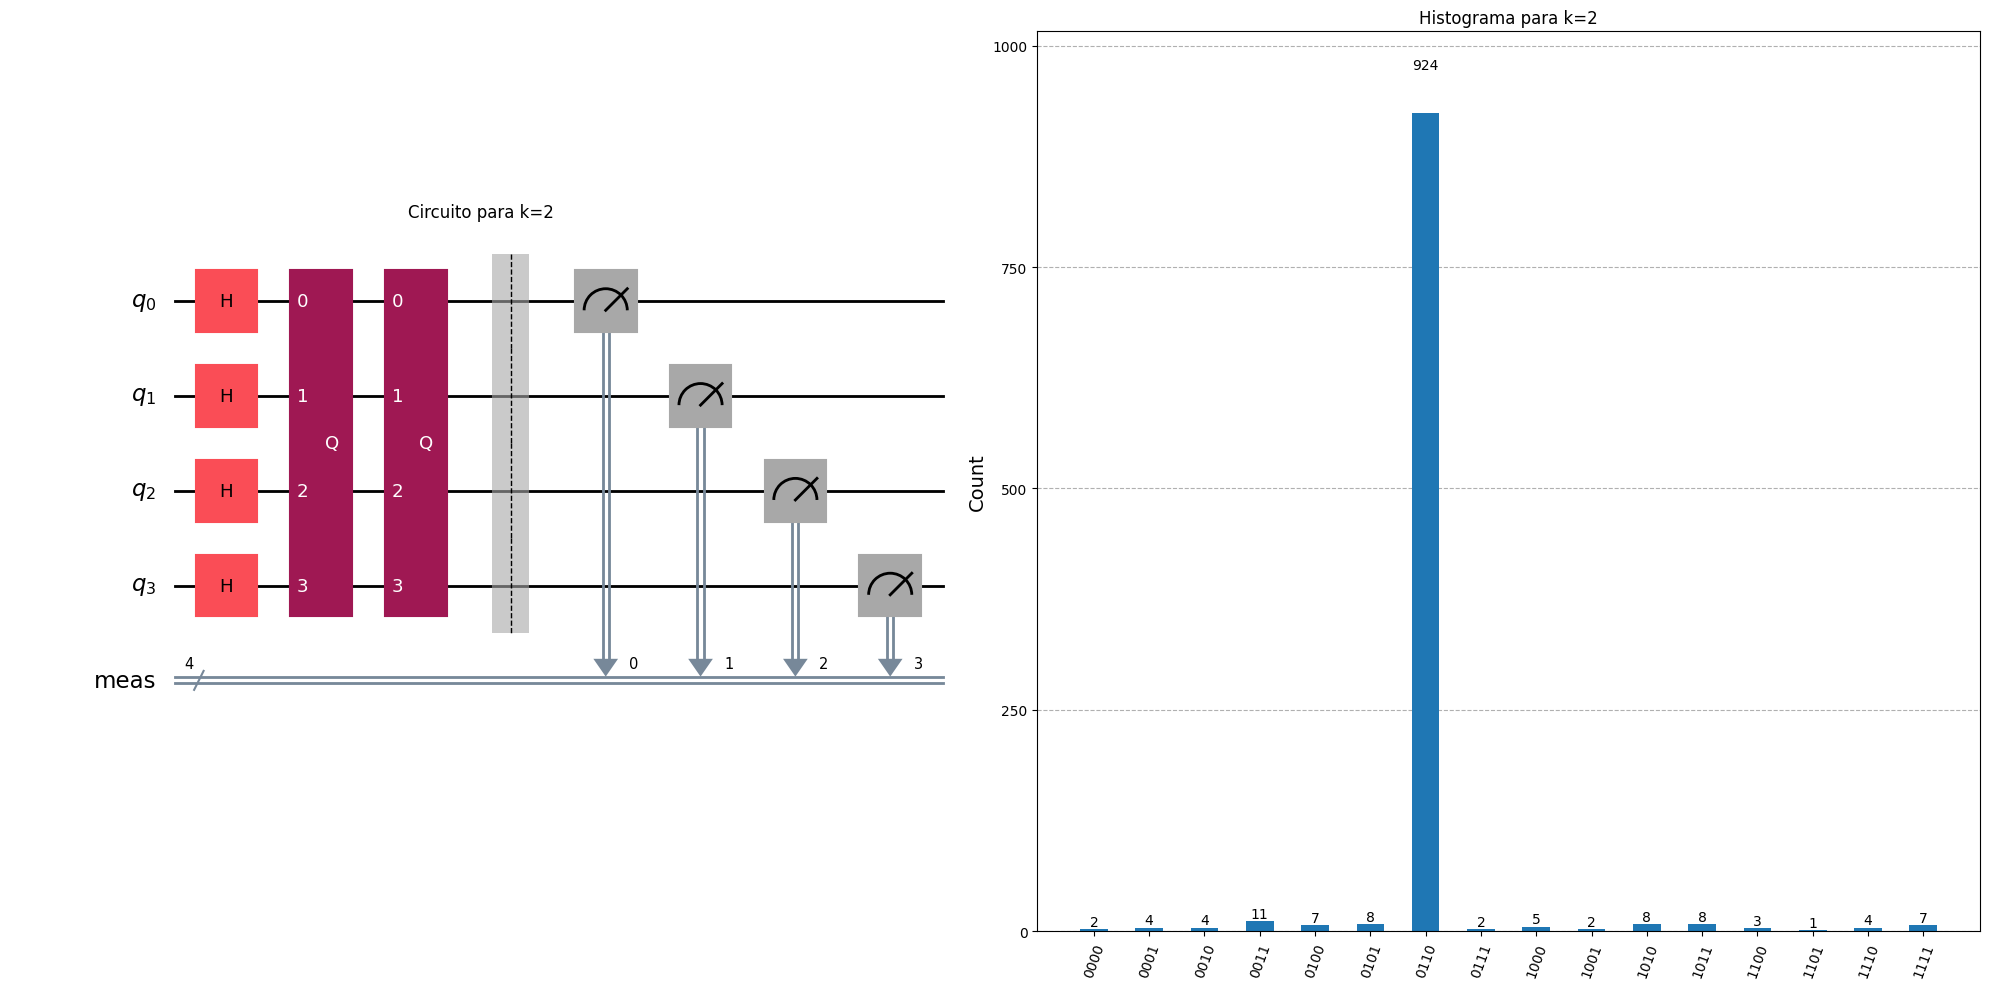

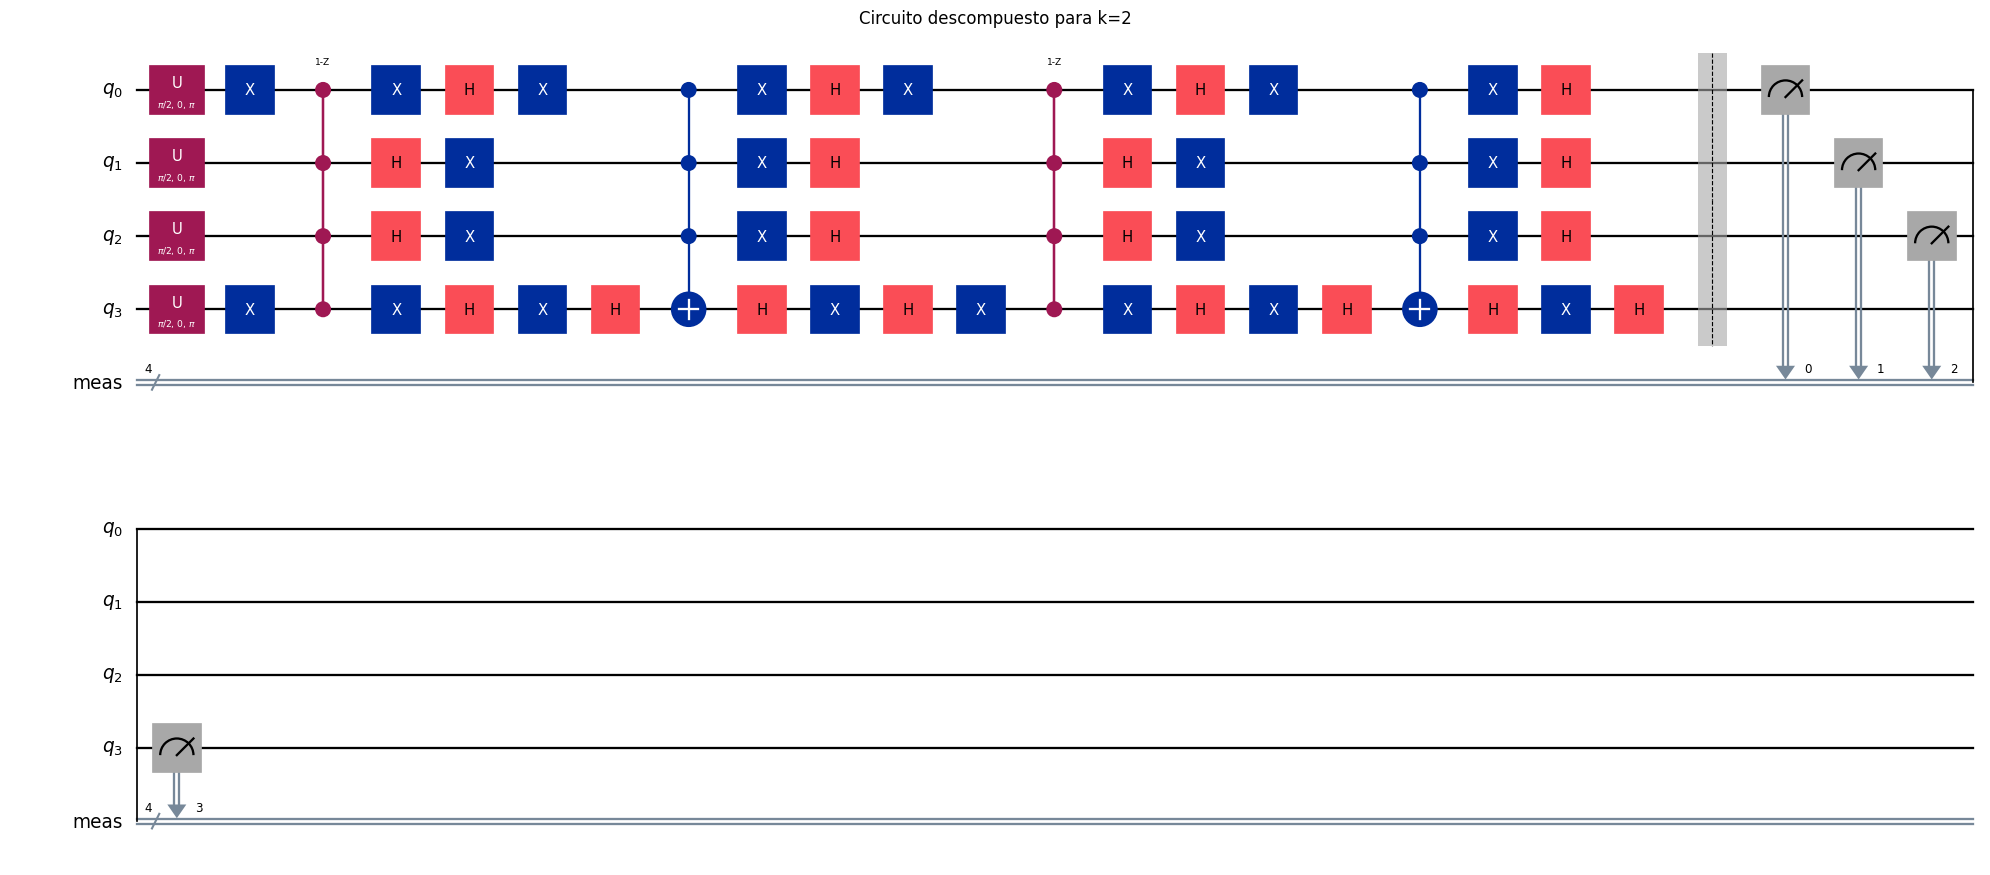

k=3:


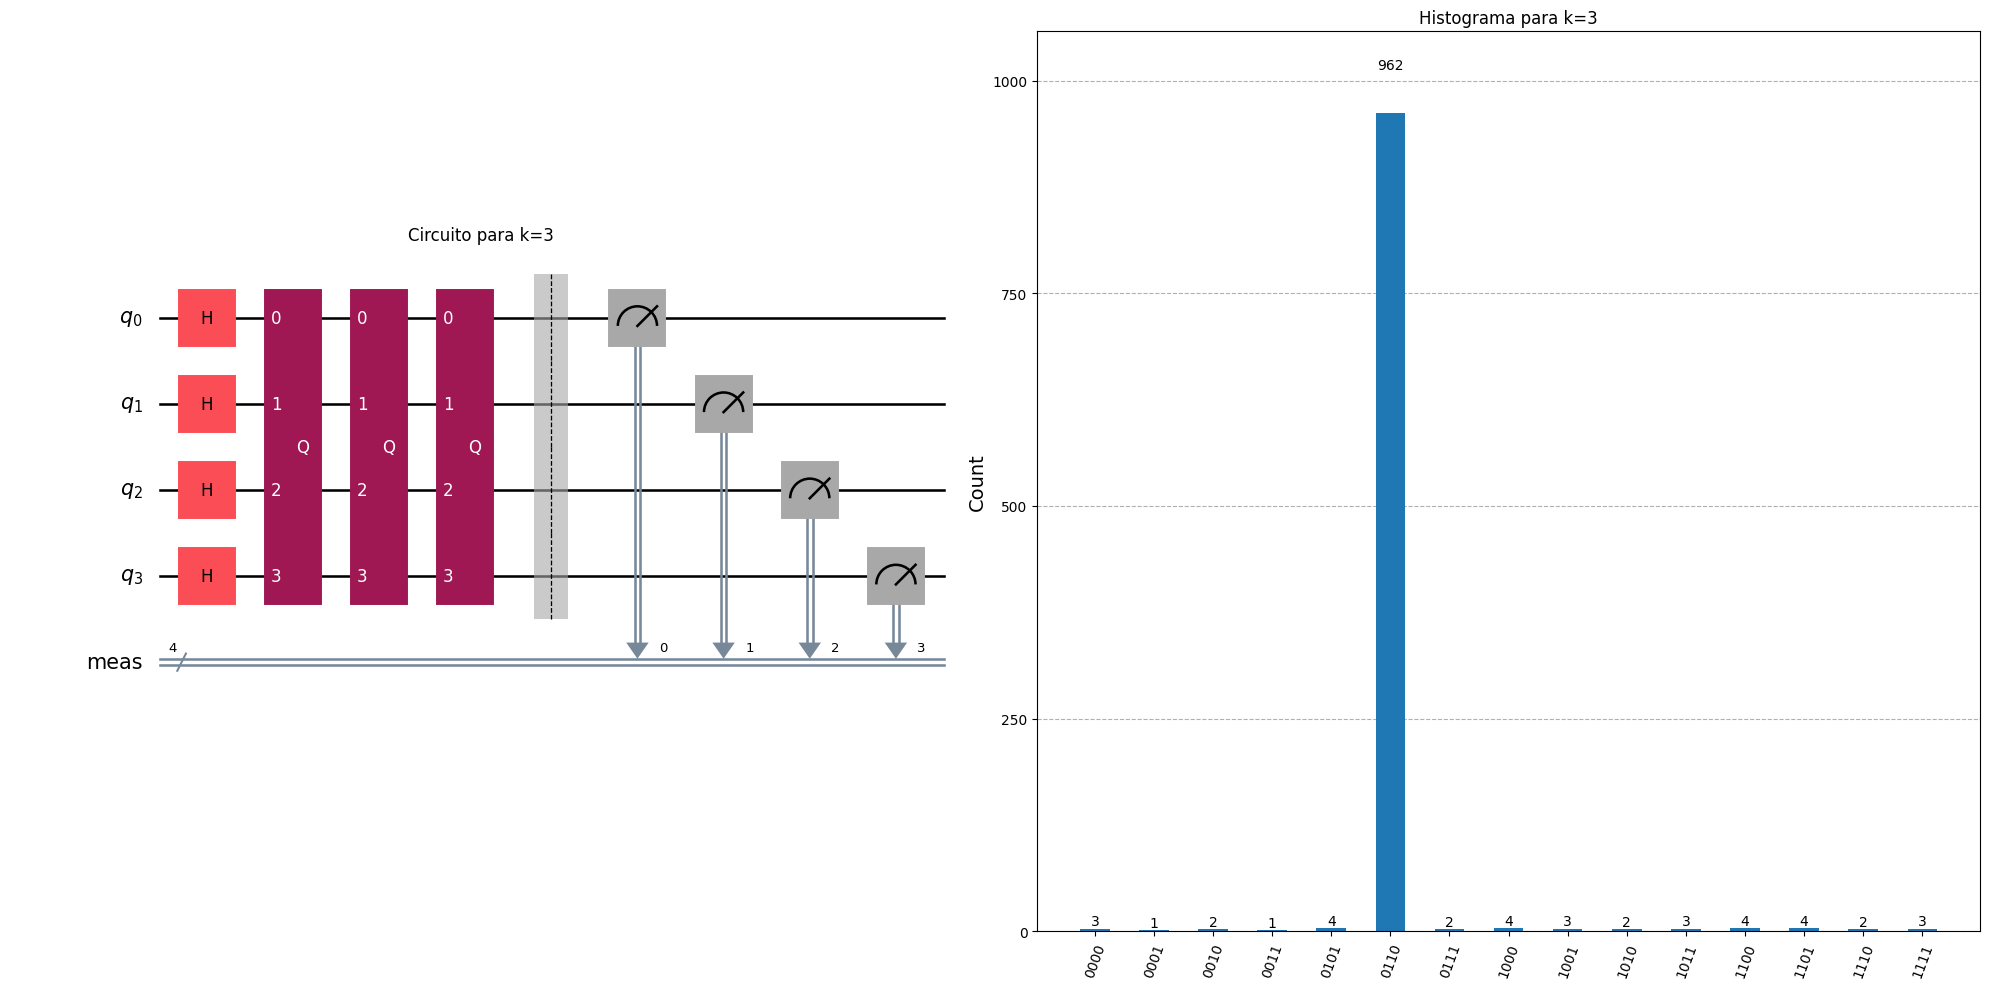

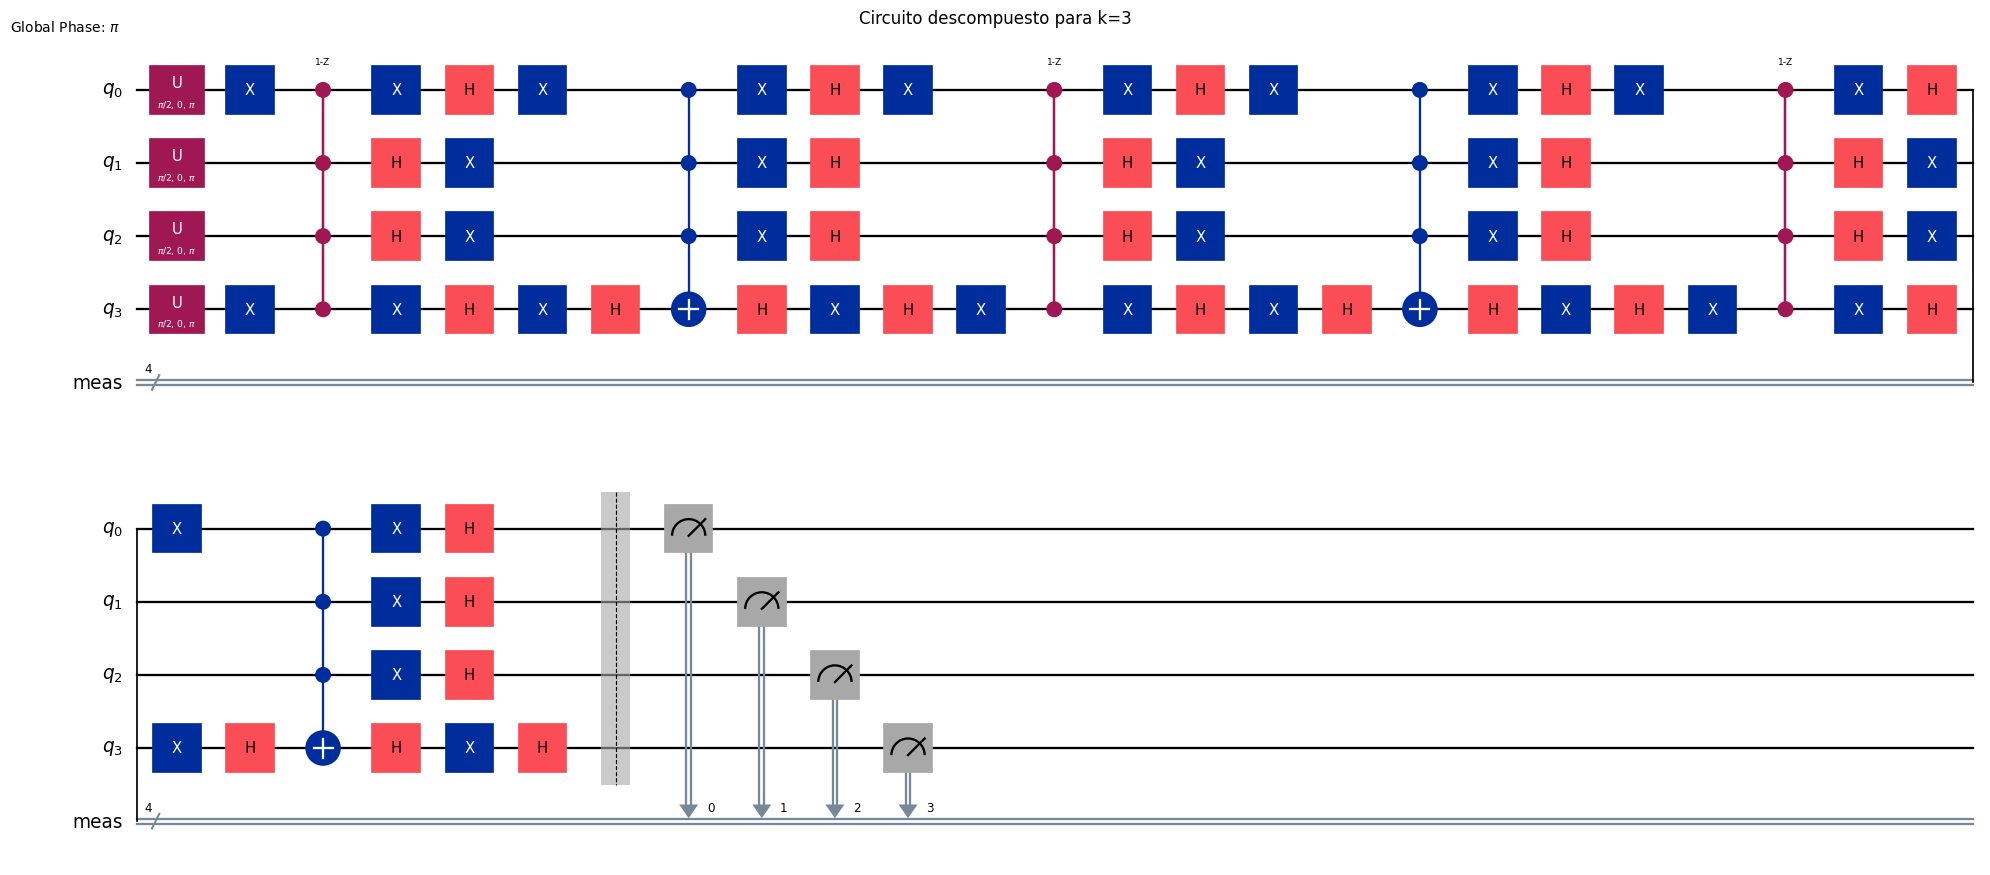

k=4:


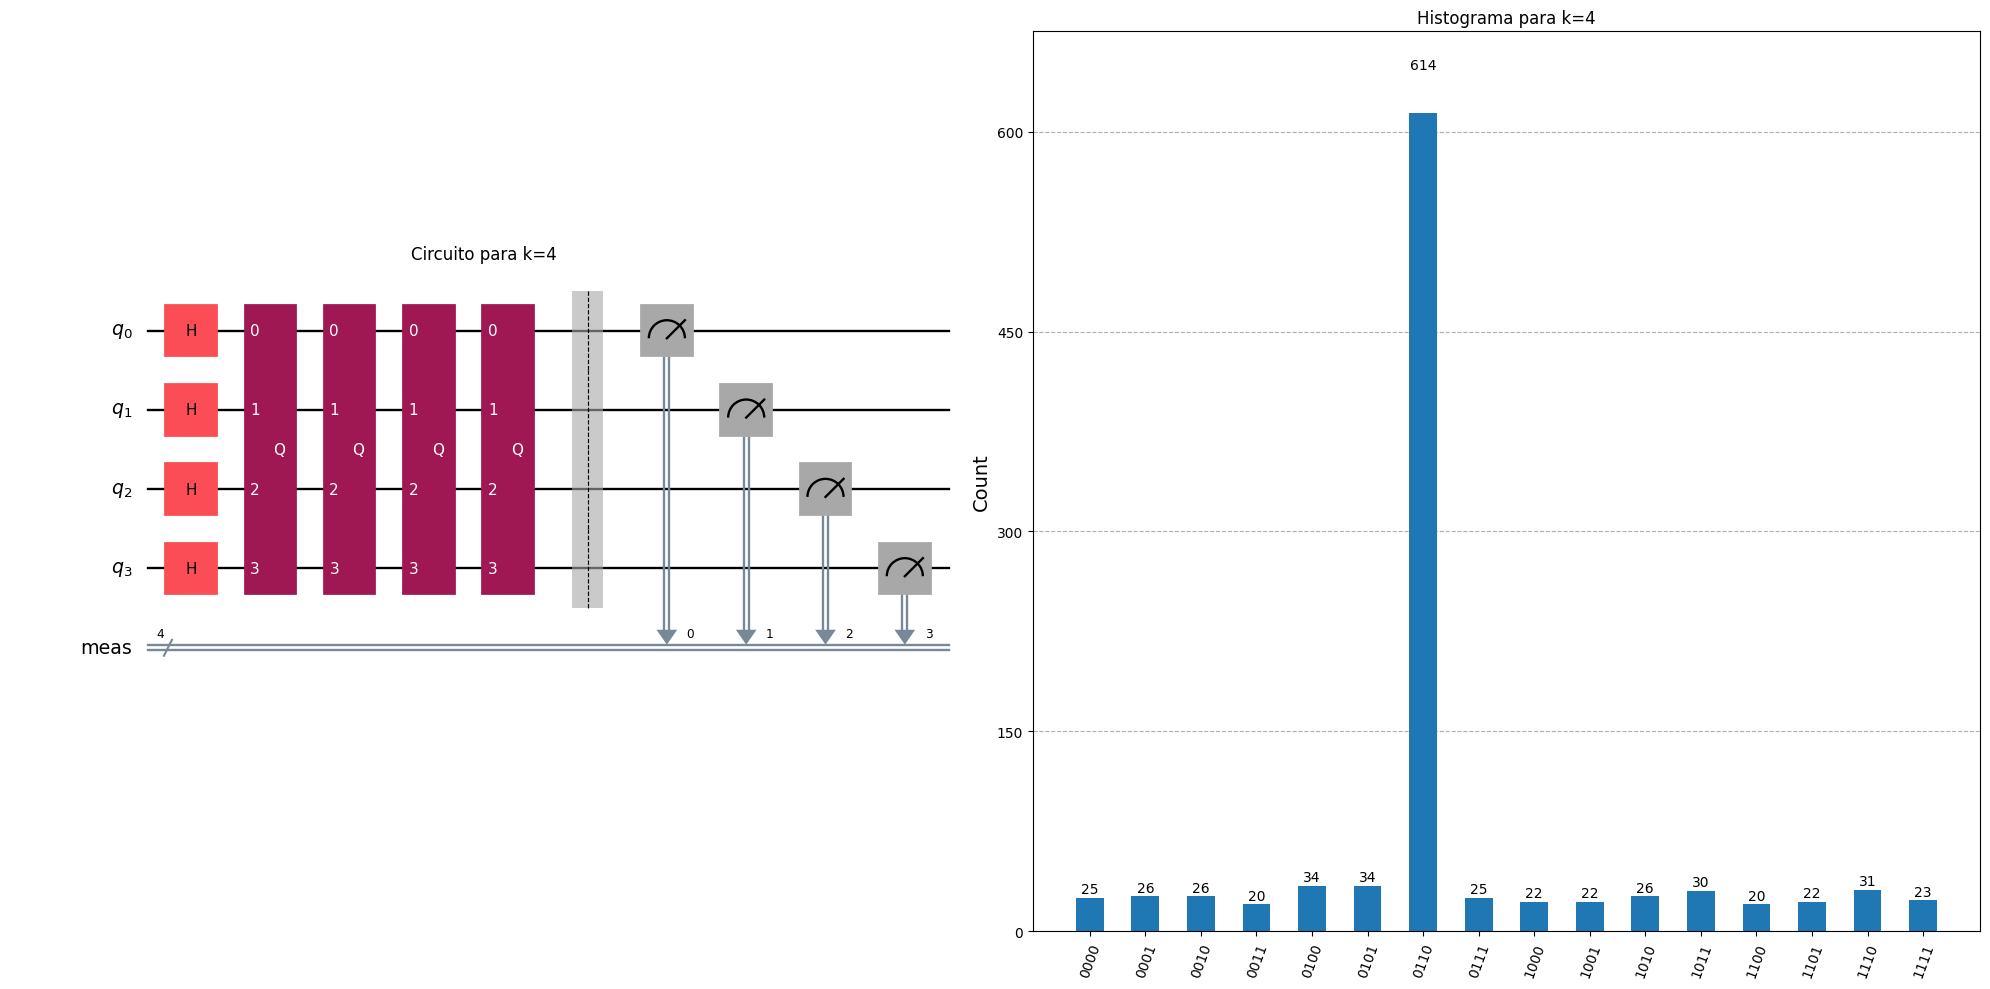

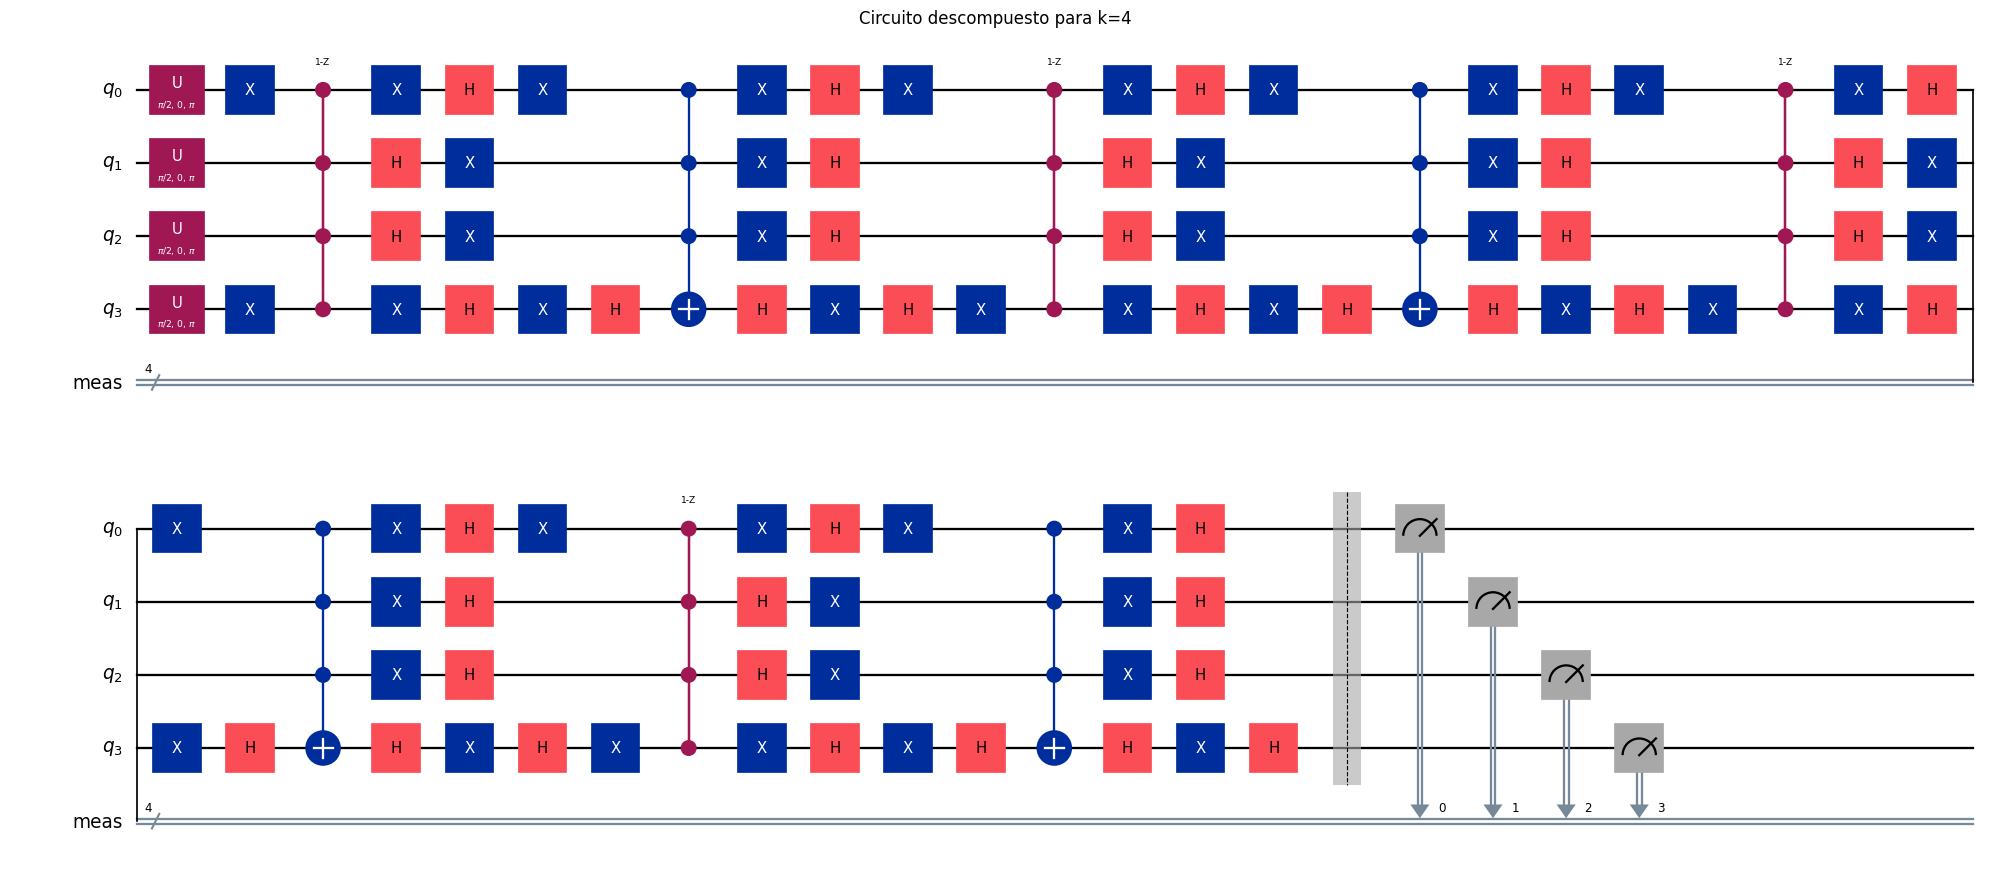

k=5:


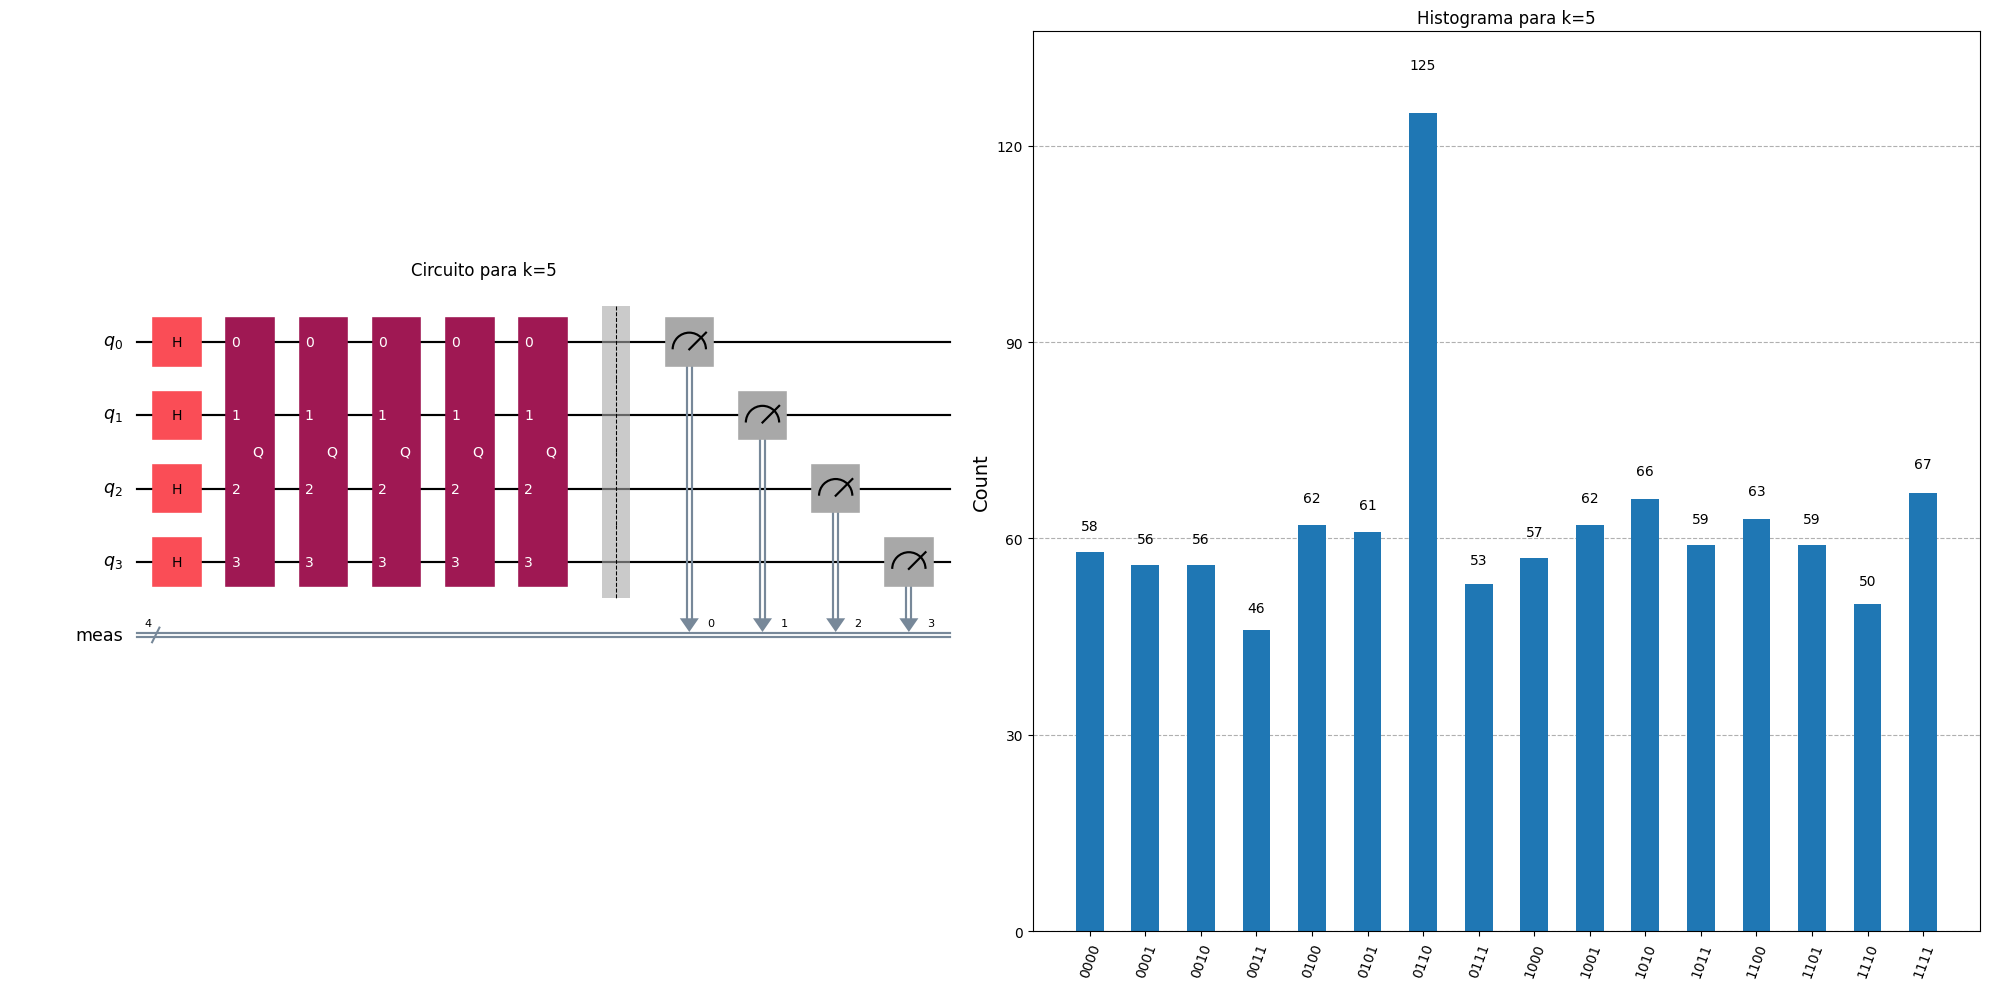

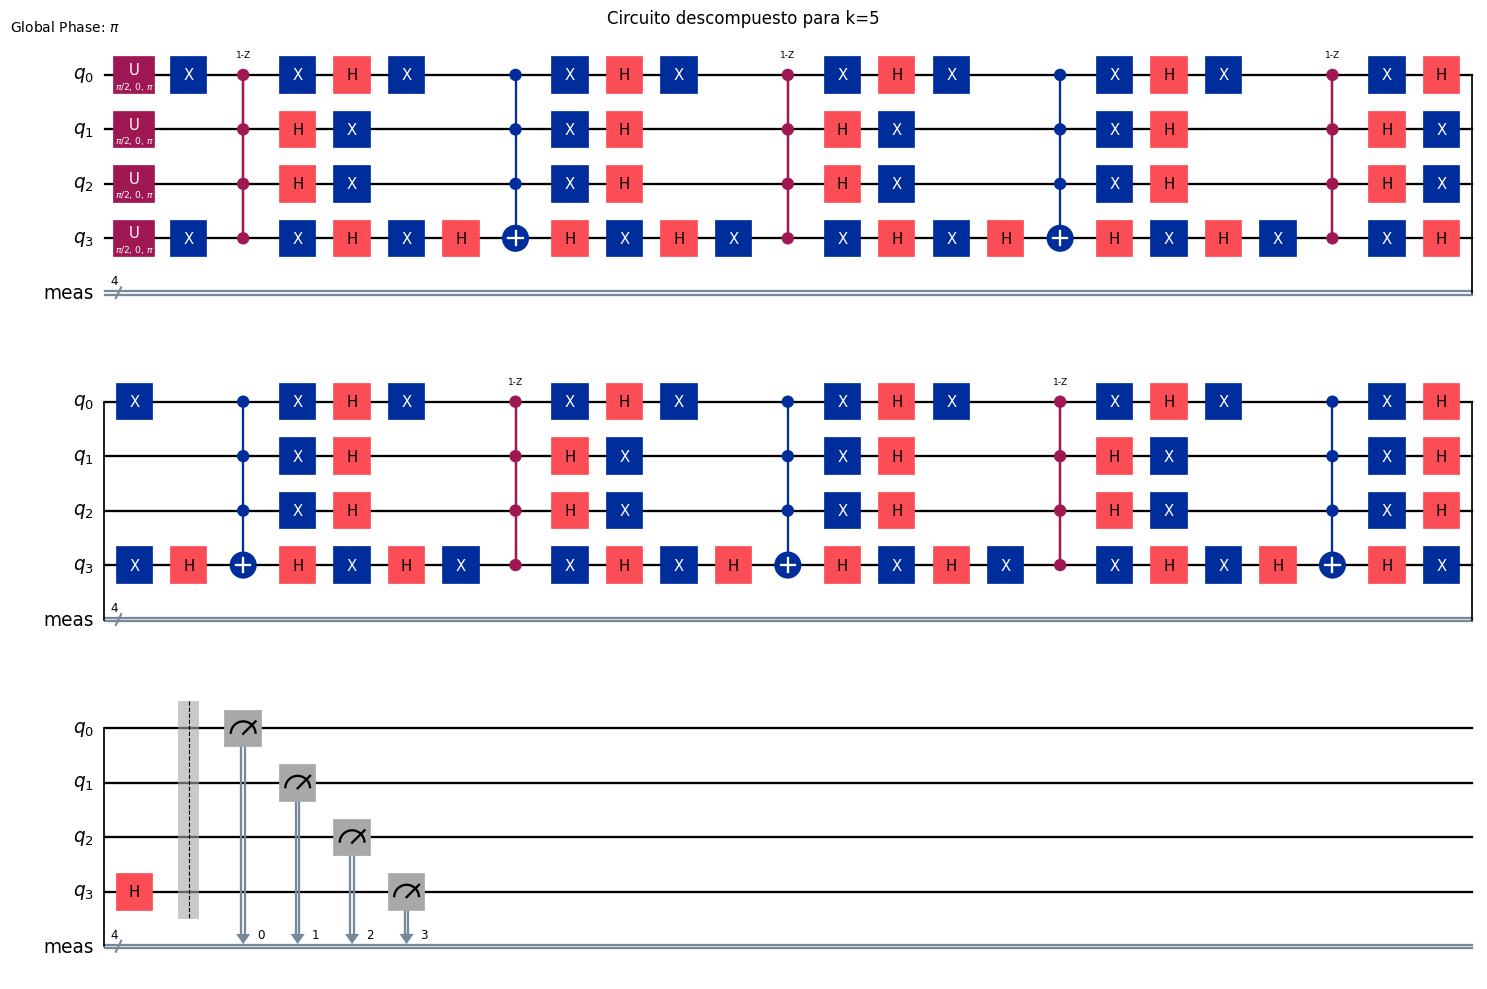

k=6:


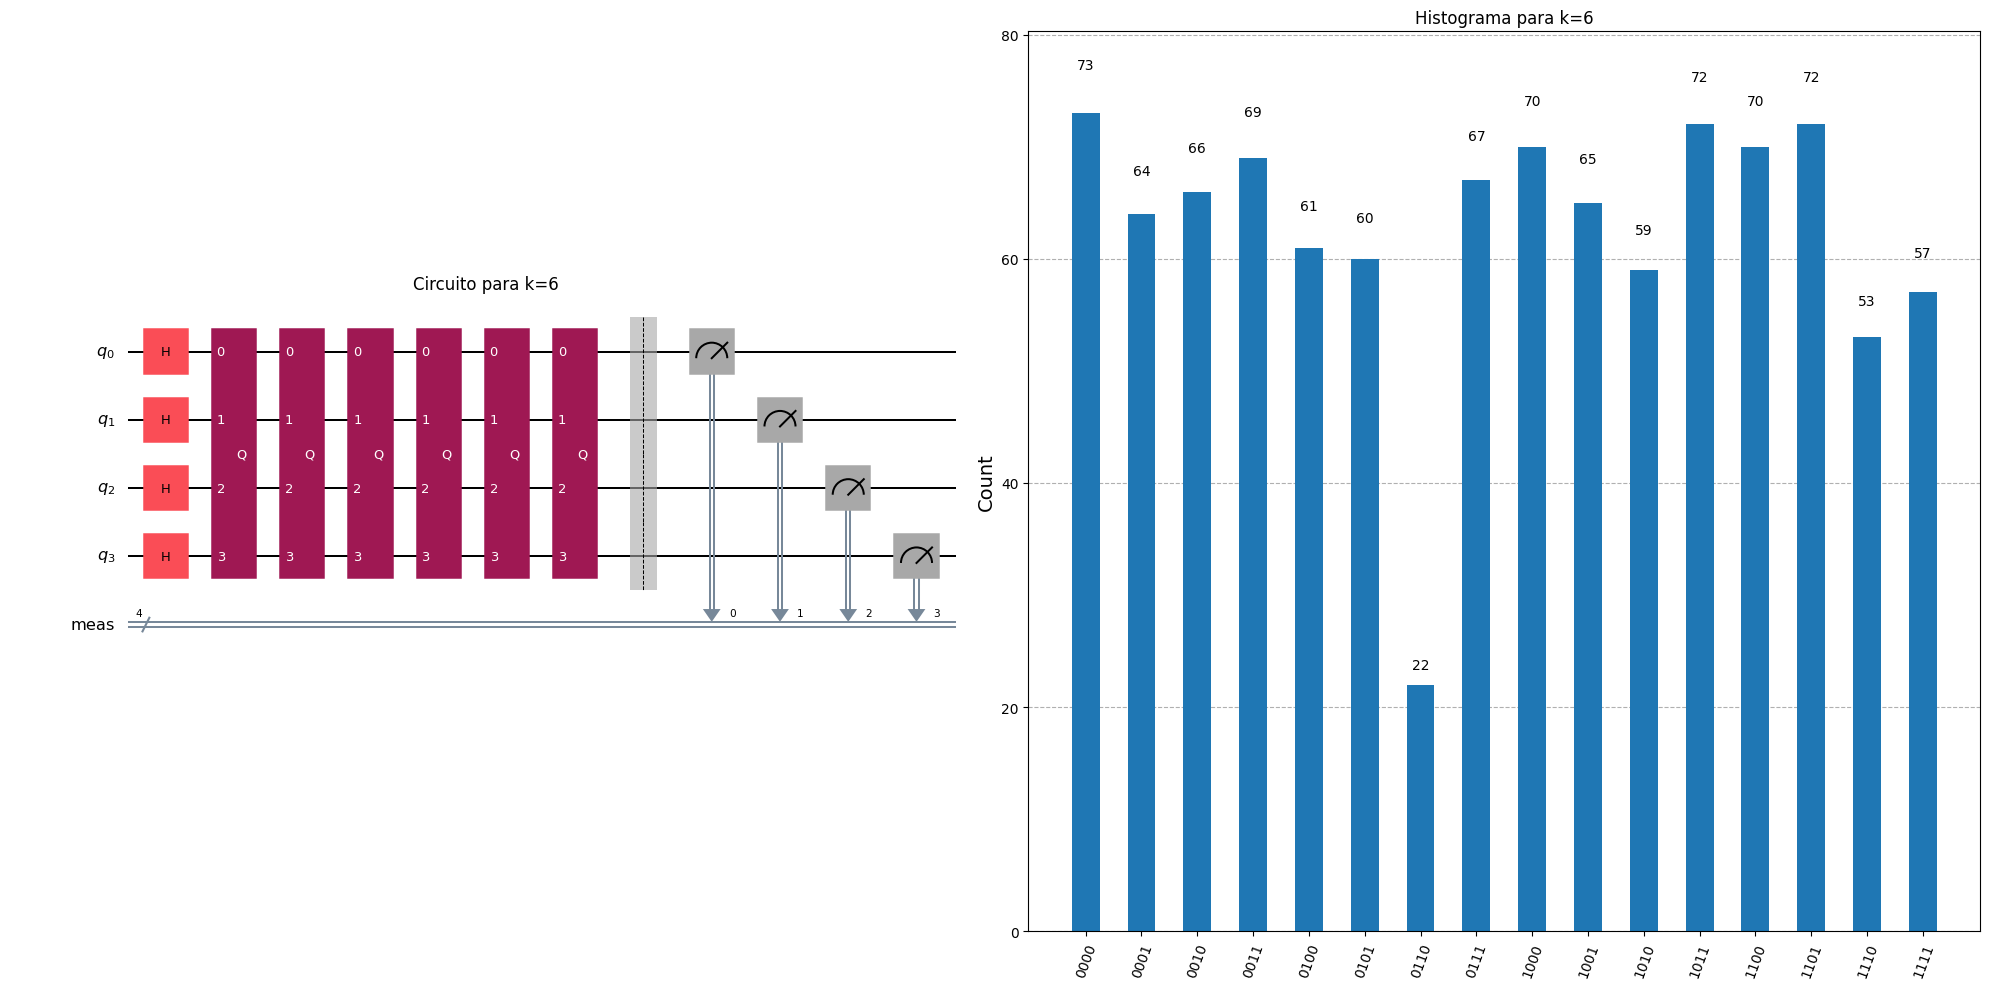

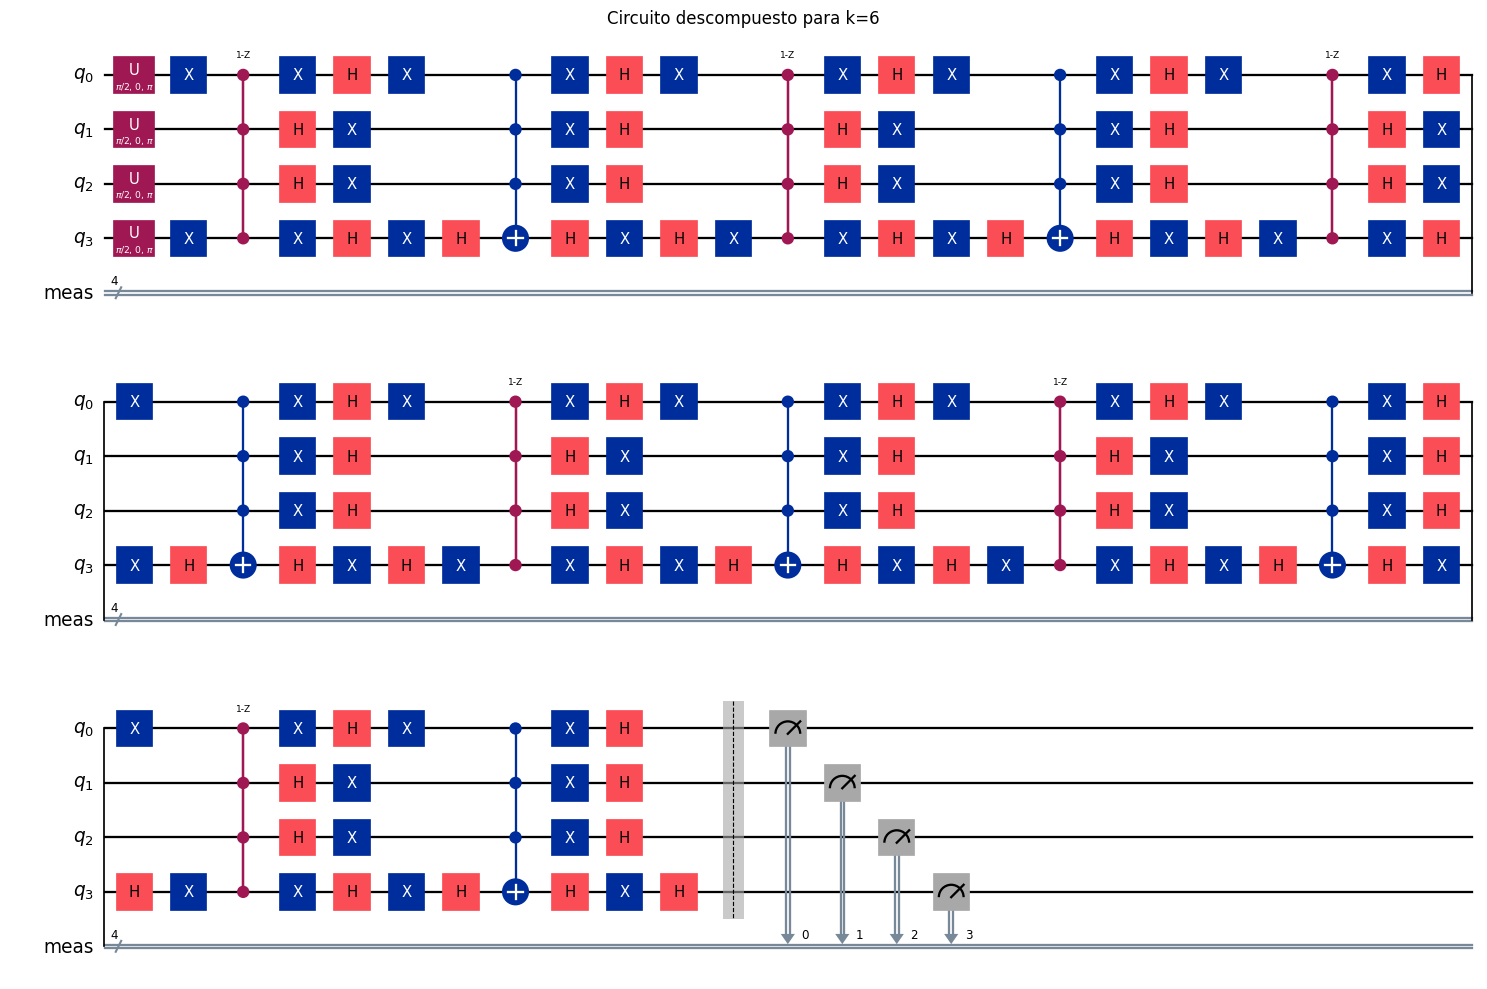

In [233]:
for k in range(1, 7):
    #Crear circuito vacío
    qc = QuantumCircuit(num_qubits2)

    #Aplicar puertas Hadamard para crear superposición
    qc.h(range(num_qubits2))

    #Aplicar k iteraciones del operador de Grover
    qc.compose(grover_op2.power(k), inplace=True)

    #Simulación
    sv = Statevector.from_instruction(qc)
    #Obtener estadísicas
    statistics = sv.sample_counts(1000)

    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()
    
    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución experimentalmente con 3 iteraciones

In [234]:
#Calculo valor teórico de iteraciones
it_teoricas2 = (math.pi/4)*math.sqrt(q2**n2)
print("Valor teórico de iteraciones:", it_teoricas2)
it_teoricas_exacto2 = (math.pi/(4*math.asin(1/math.sqrt(q2**n2))))-(1/2)
print("Valor exacto de iteraciones teórico:", it_teoricas_exacto2)

Valor teórico de iteraciones: 3.141592653589793
Valor exacto de iteraciones teórico: 2.6082688394304085


El procedimiento para calcular el entero óptimo de iteraciones es el mismo que en el anterior caso.

In [235]:
prob_anterior2=math.sin(((2*2)+1)*math.asin(1/math.sqrt(q2**n2)))**2
prob_posterior2=math.sin(((2*3)+1)*math.asin(1/math.sqrt(q2**n2)))**2
print("Probabilidad de éxito con 2 iteraciones:", prob_anterior2)
print("Probabilidad de éxito con 3 iteraciones:", prob_posterior2)

Probabilidad de éxito con 2 iteraciones: 0.908447265625
Probabilidad de éxito con 3 iteraciones: 0.9613189697265625


La diferencia entre las probabilidades es menor que en el primer caso. Podemos concluir que el entero óptimo es 3 iteraciones que coincide con los resultados experimentales.

### Caso de prueba 3:

In [236]:
n3 = 2
m3 = 5
q3 = 8
num_qubits3 = 6
num_bits3 = int(np.ceil(np.log2(q3)))

In [237]:
#Generar instancia LWE
A3, s3, e3, b3 = generar_lwe(n3, m3 ,q3)

display(array_to_latex(A3, prefix="A3"))
display(array_to_latex(s3, prefix="s3"))
display(array_to_latex(e3, prefix="e3"))
display(array_to_latex(b3, prefix="b3"))


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [238]:
#Calcular residuo
r3 = calcular_residuo(A3, s3, b3, q3)

display(array_to_latex(r3, prefix="r3"))

<IPython.core.display.Latex object>

In [239]:
#Comprobar condición
print("b3 cumple condicion:", cumple_condicion(r3, q3))

b3 cumple condicion: True


s en bits: [1 1 1 1 0 0]


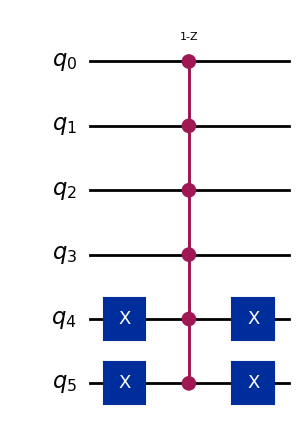

In [240]:
#Crear el circuito del oráculo de fase
circuito3 = oracle(num_qubits3, num_bits3, s3, n3)
display(circuito3.draw(output="mpl"))

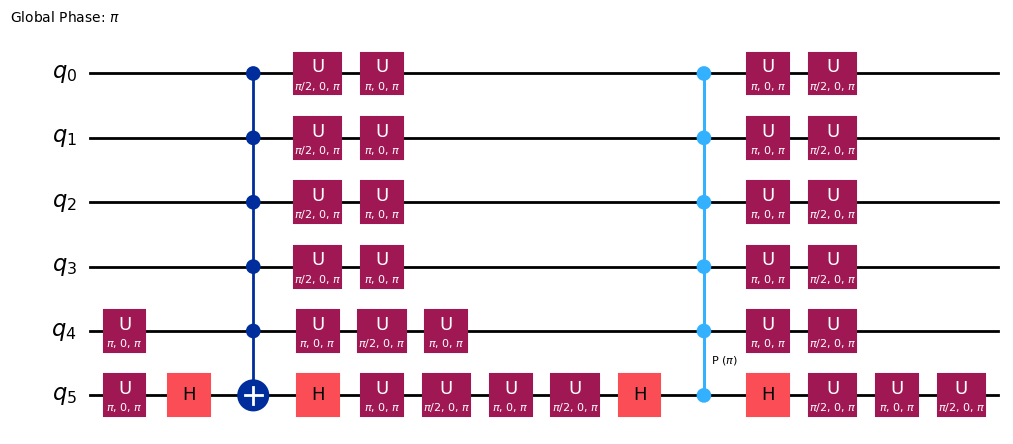

In [241]:
#Construir el operador de Grover
grover_op3 = grover_operator(circuito3)
grover_op3.decompose().draw(output="mpl", style="iqp")

k=1:


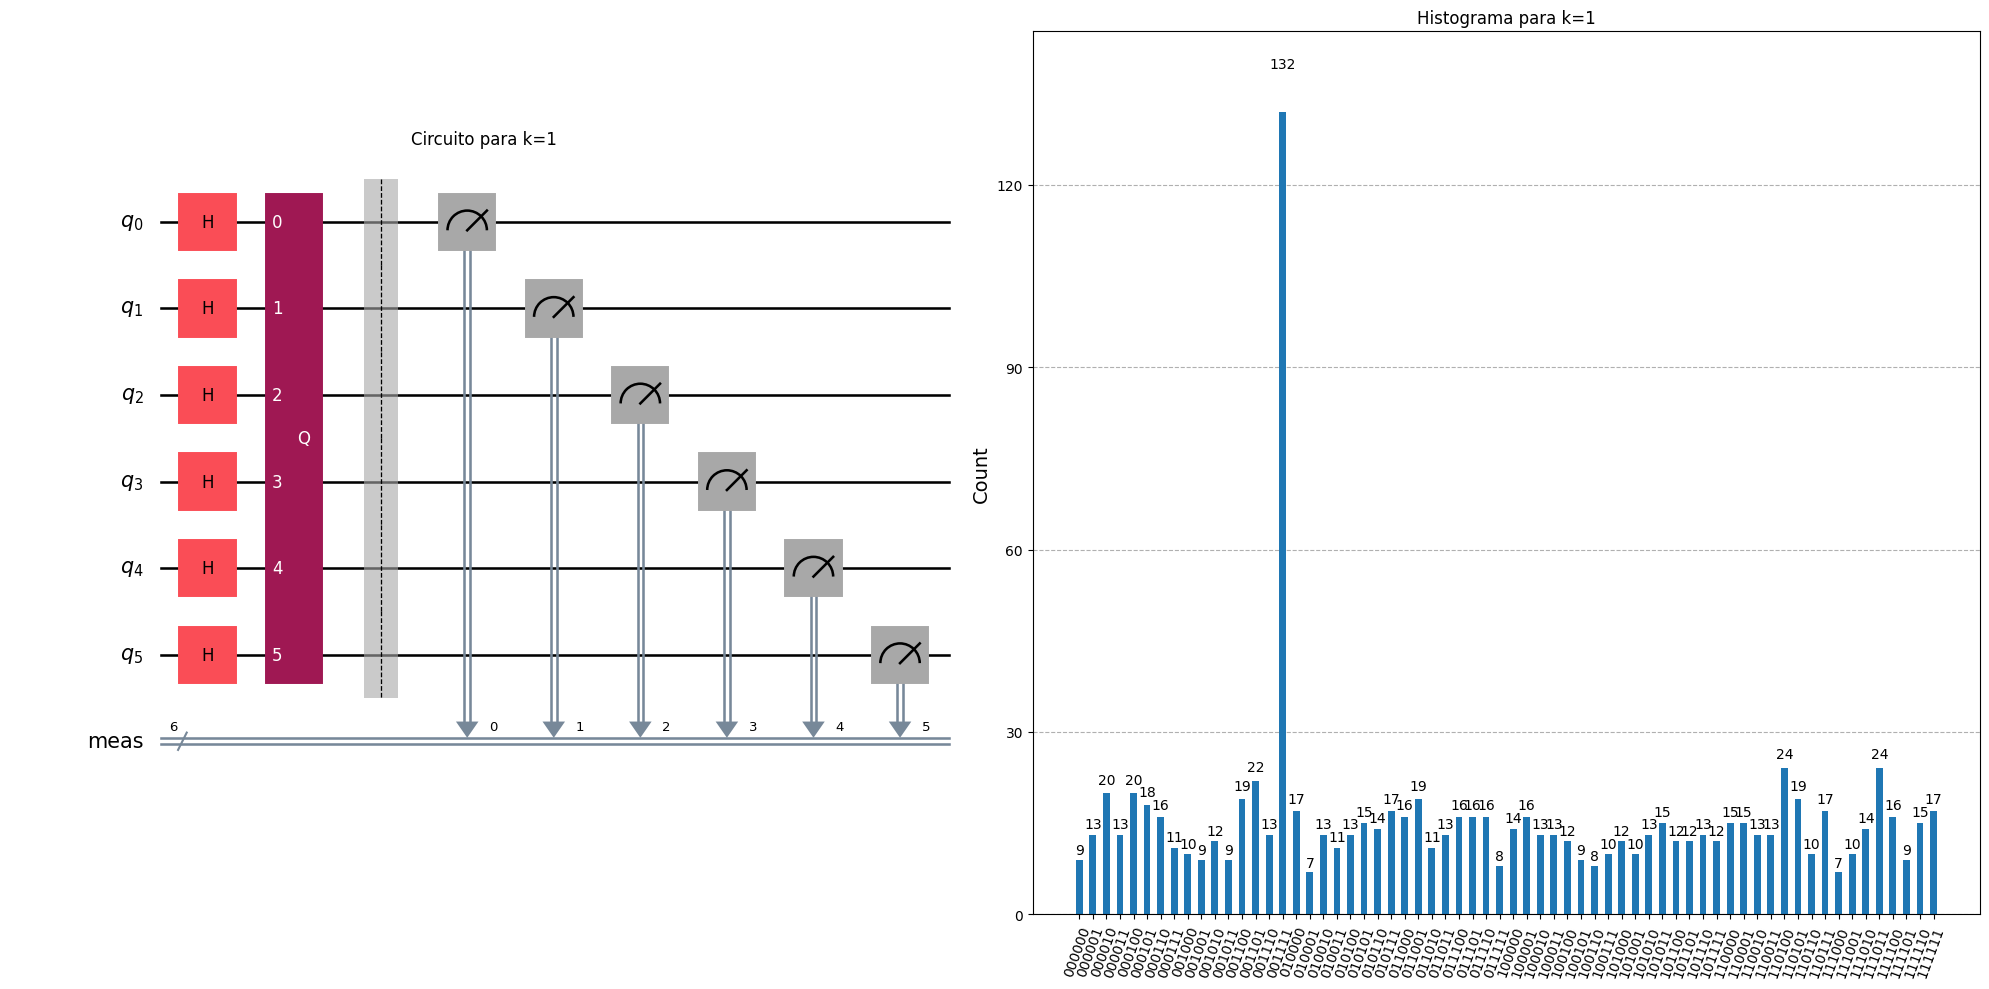

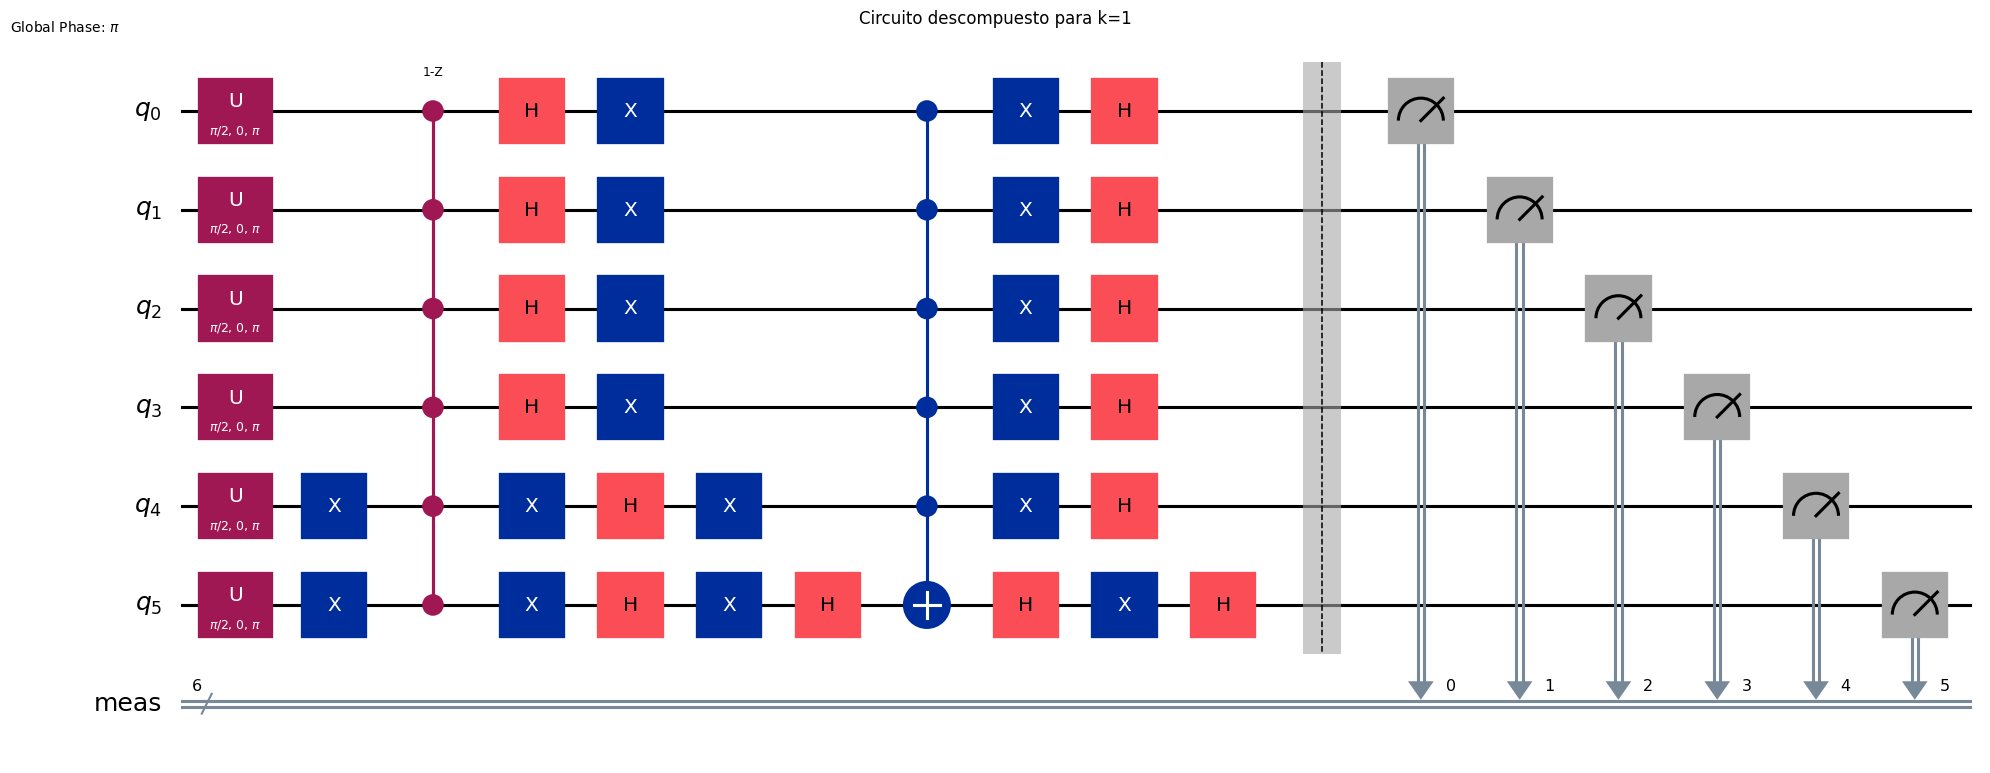

k=2:


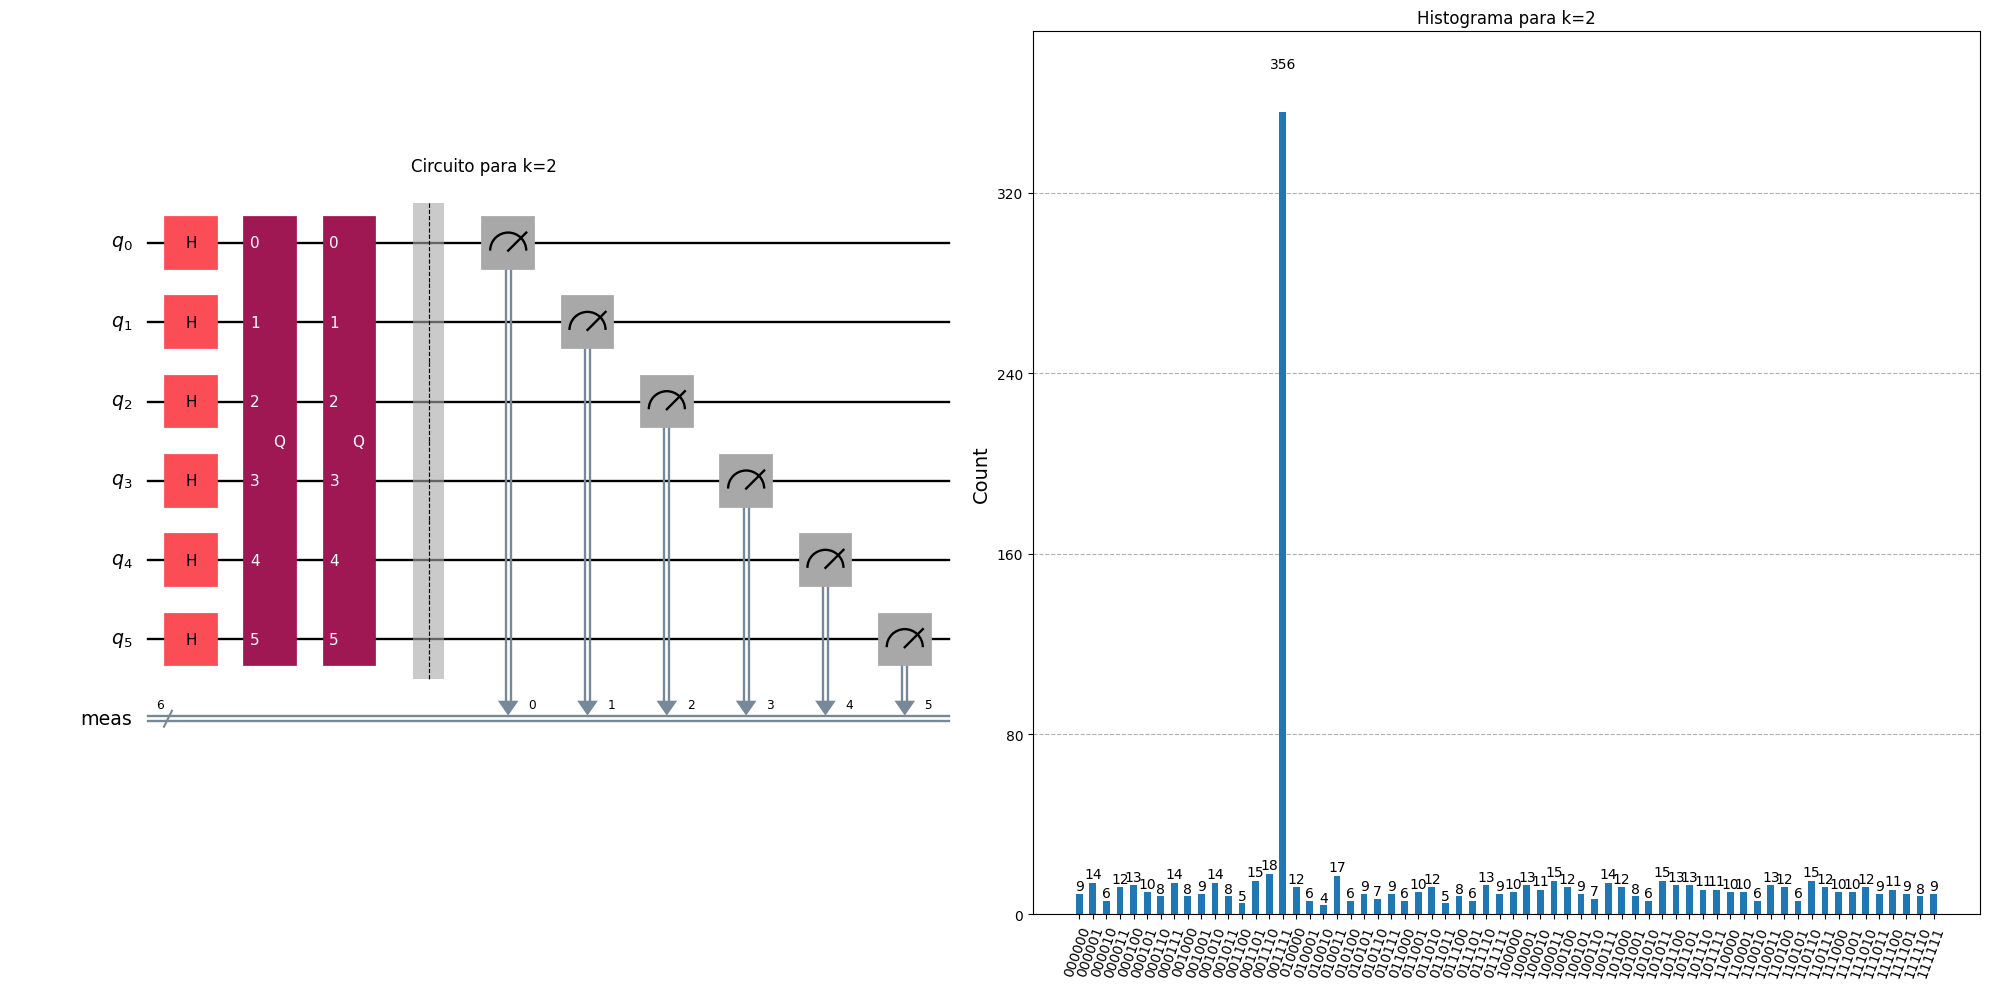

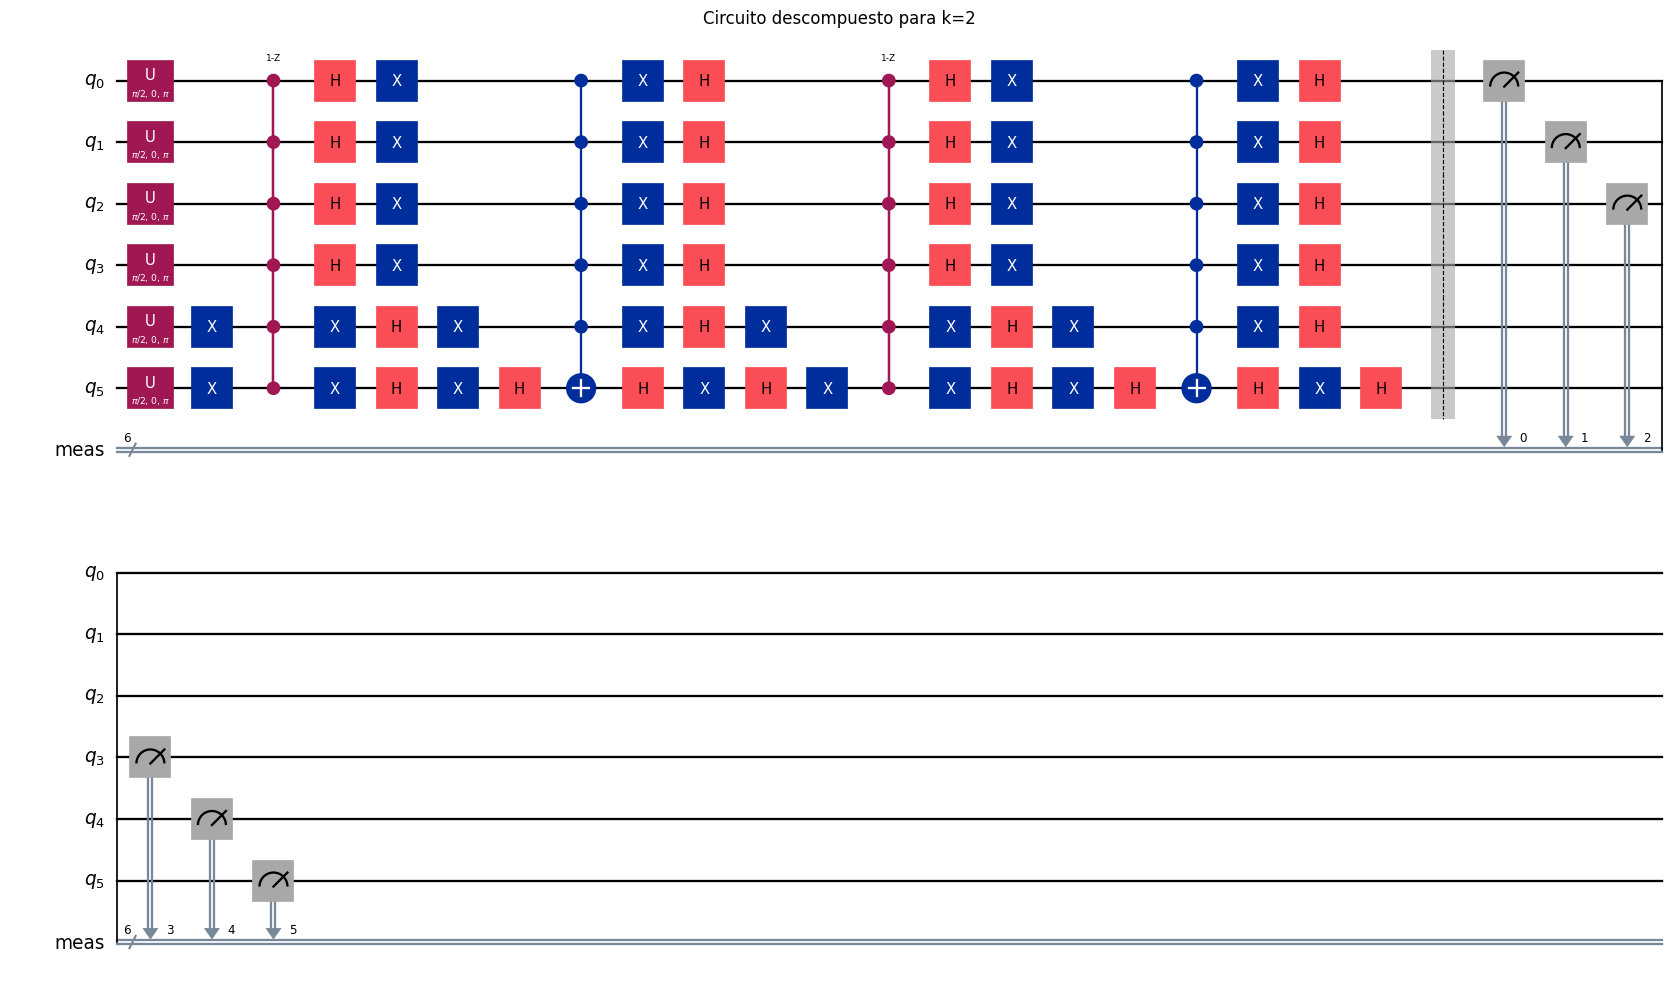

k=3:


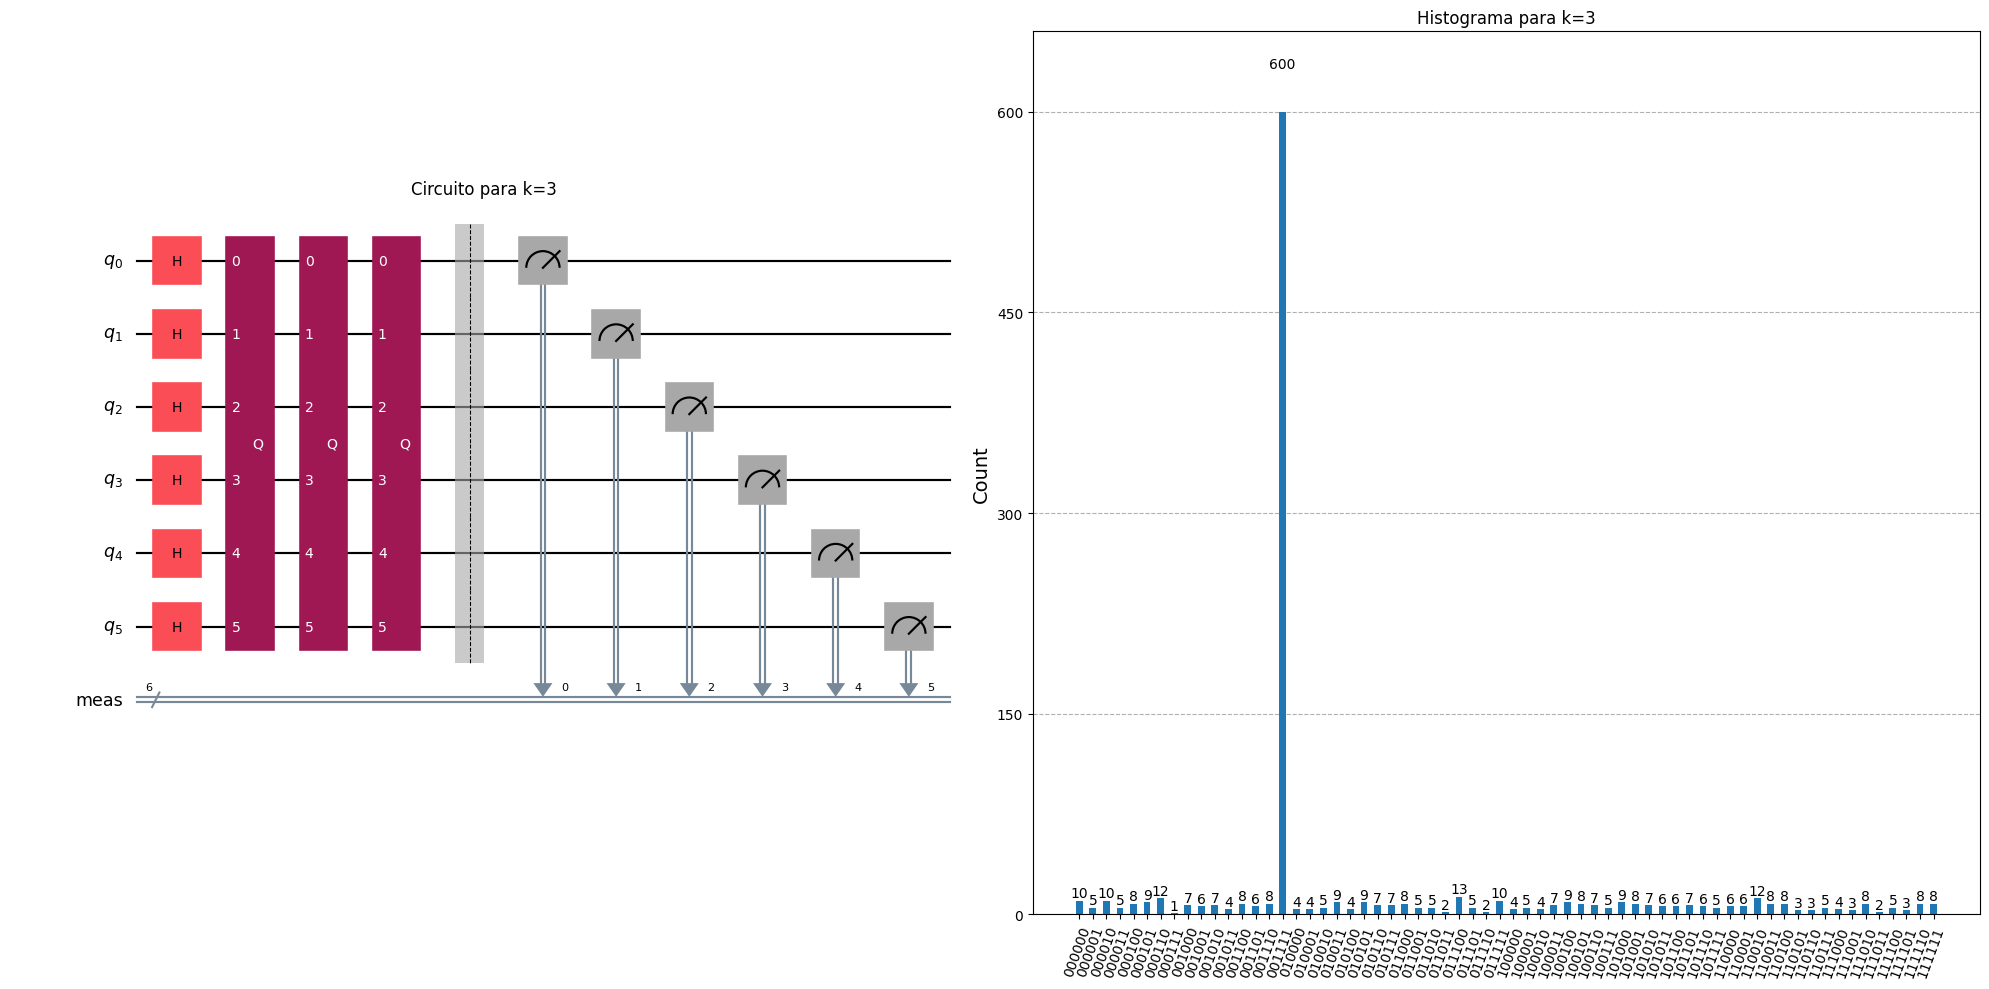

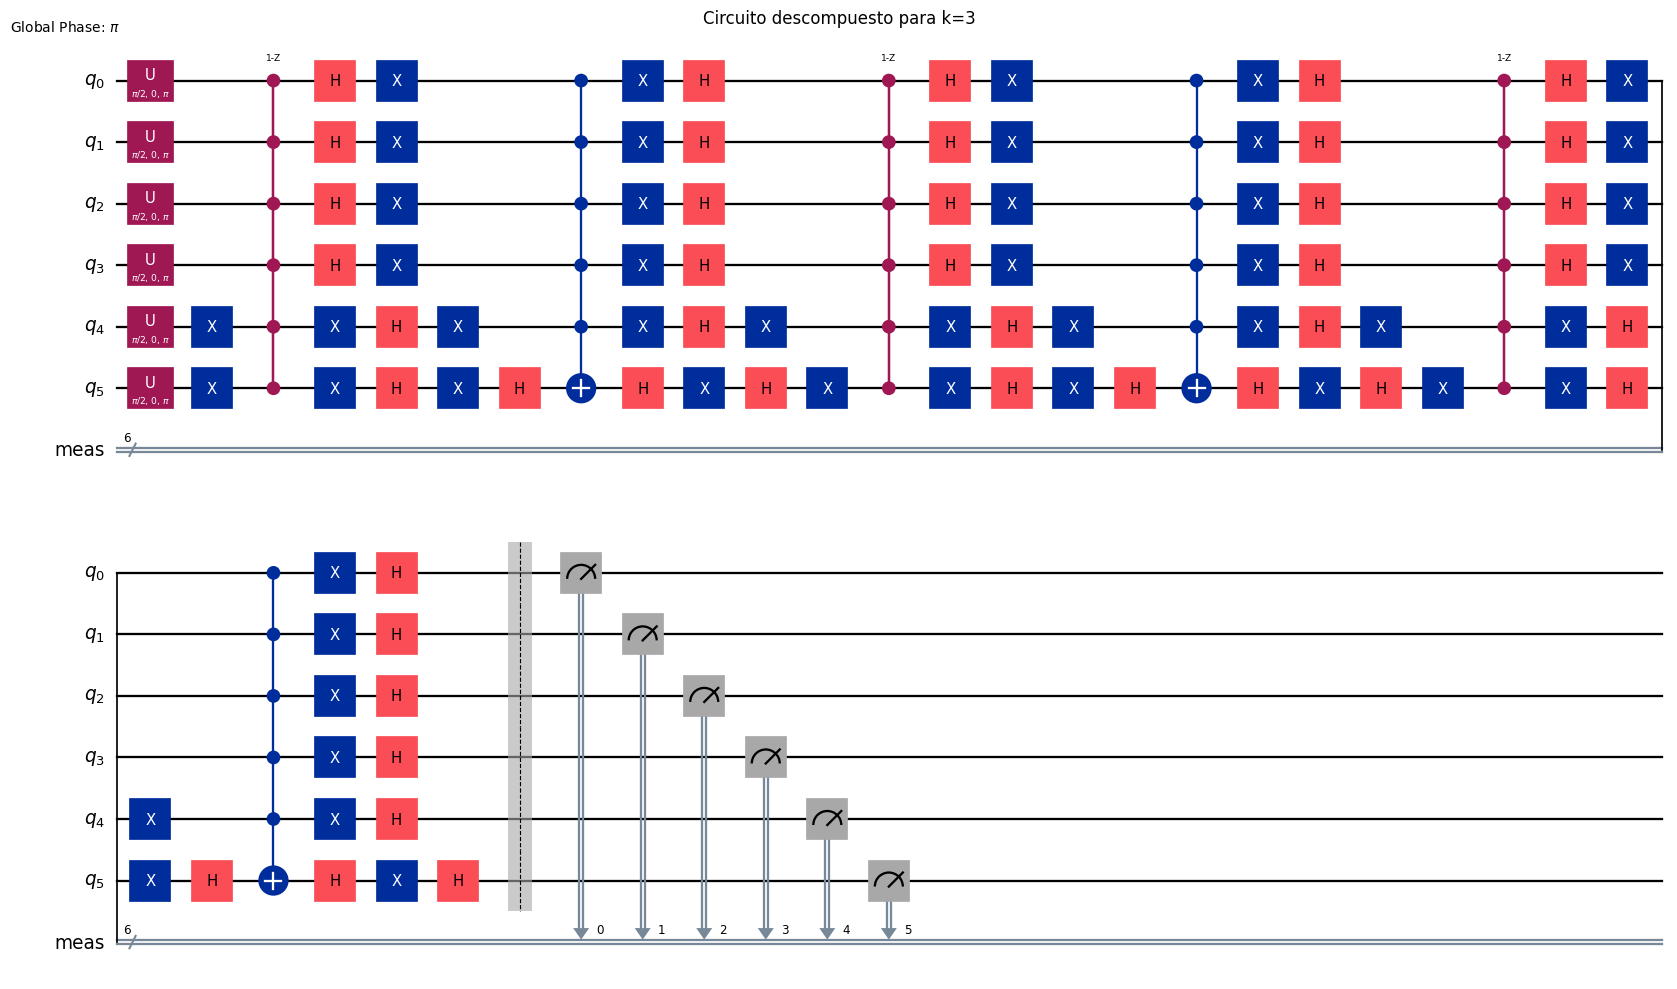

k=4:


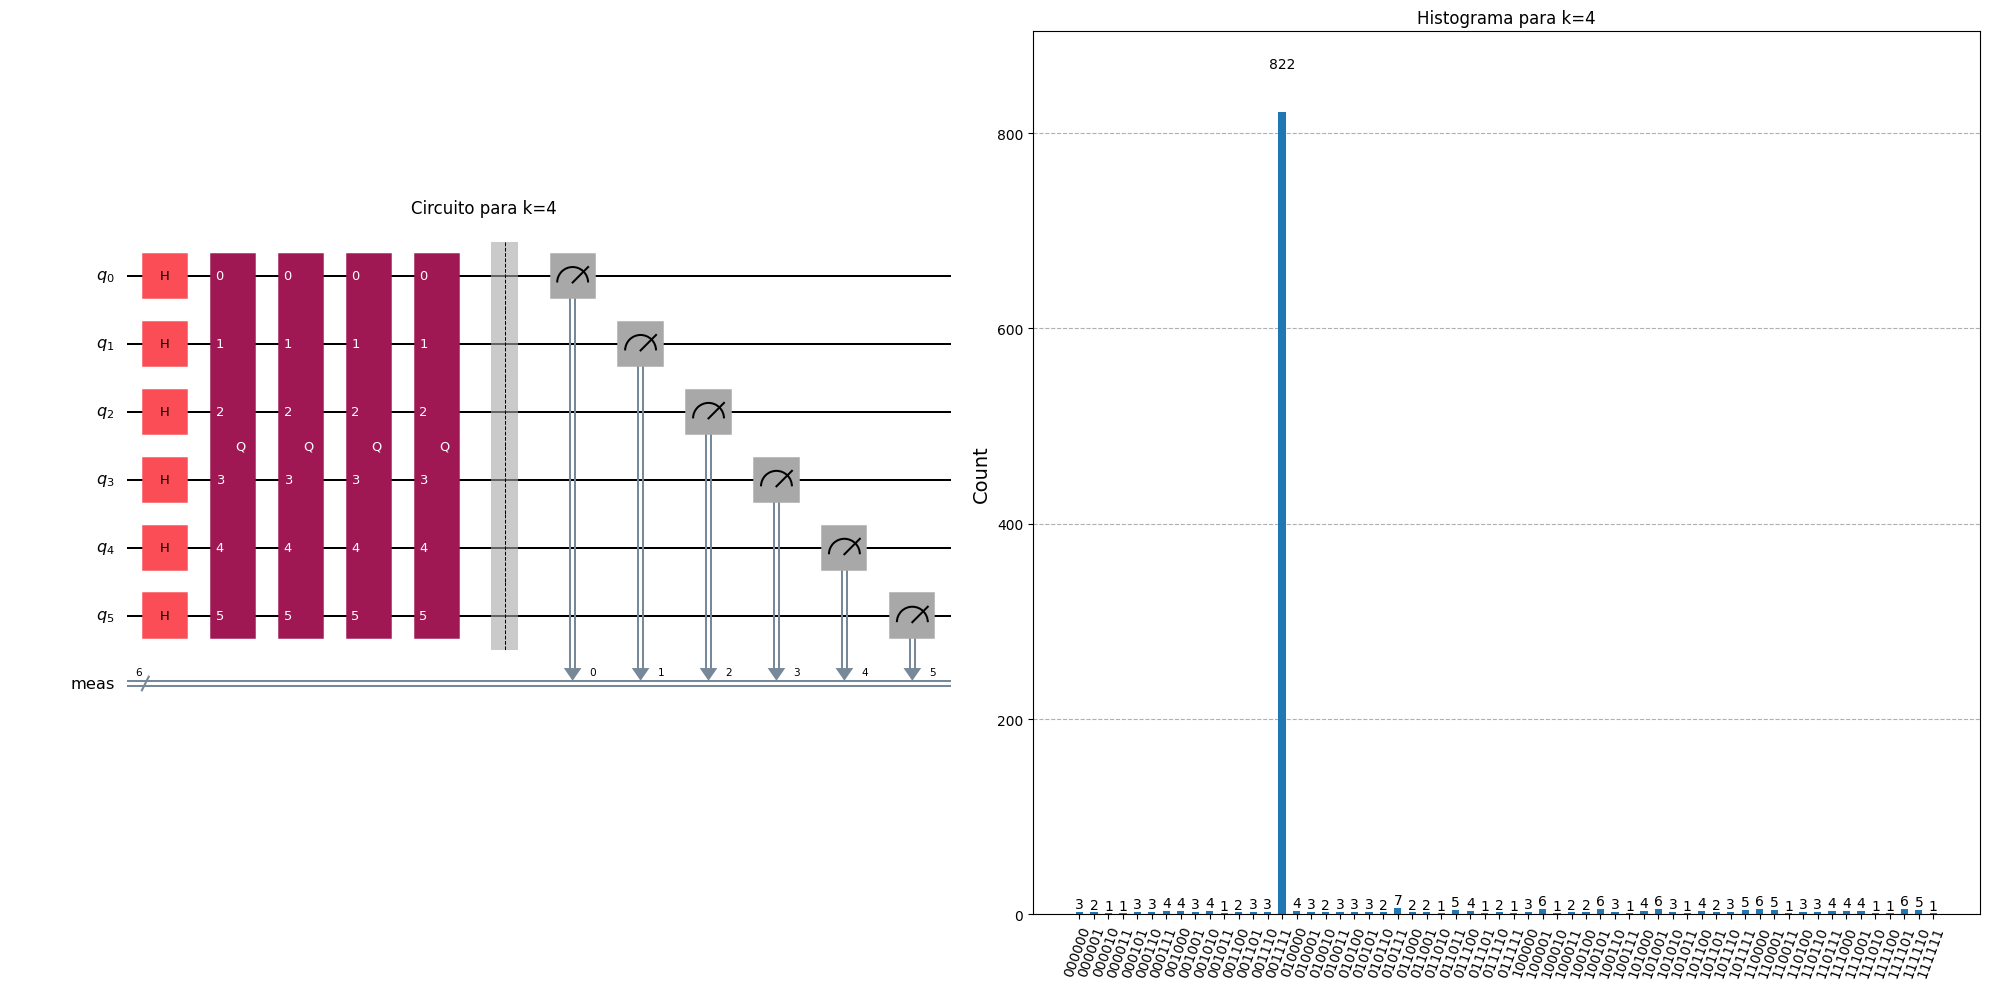

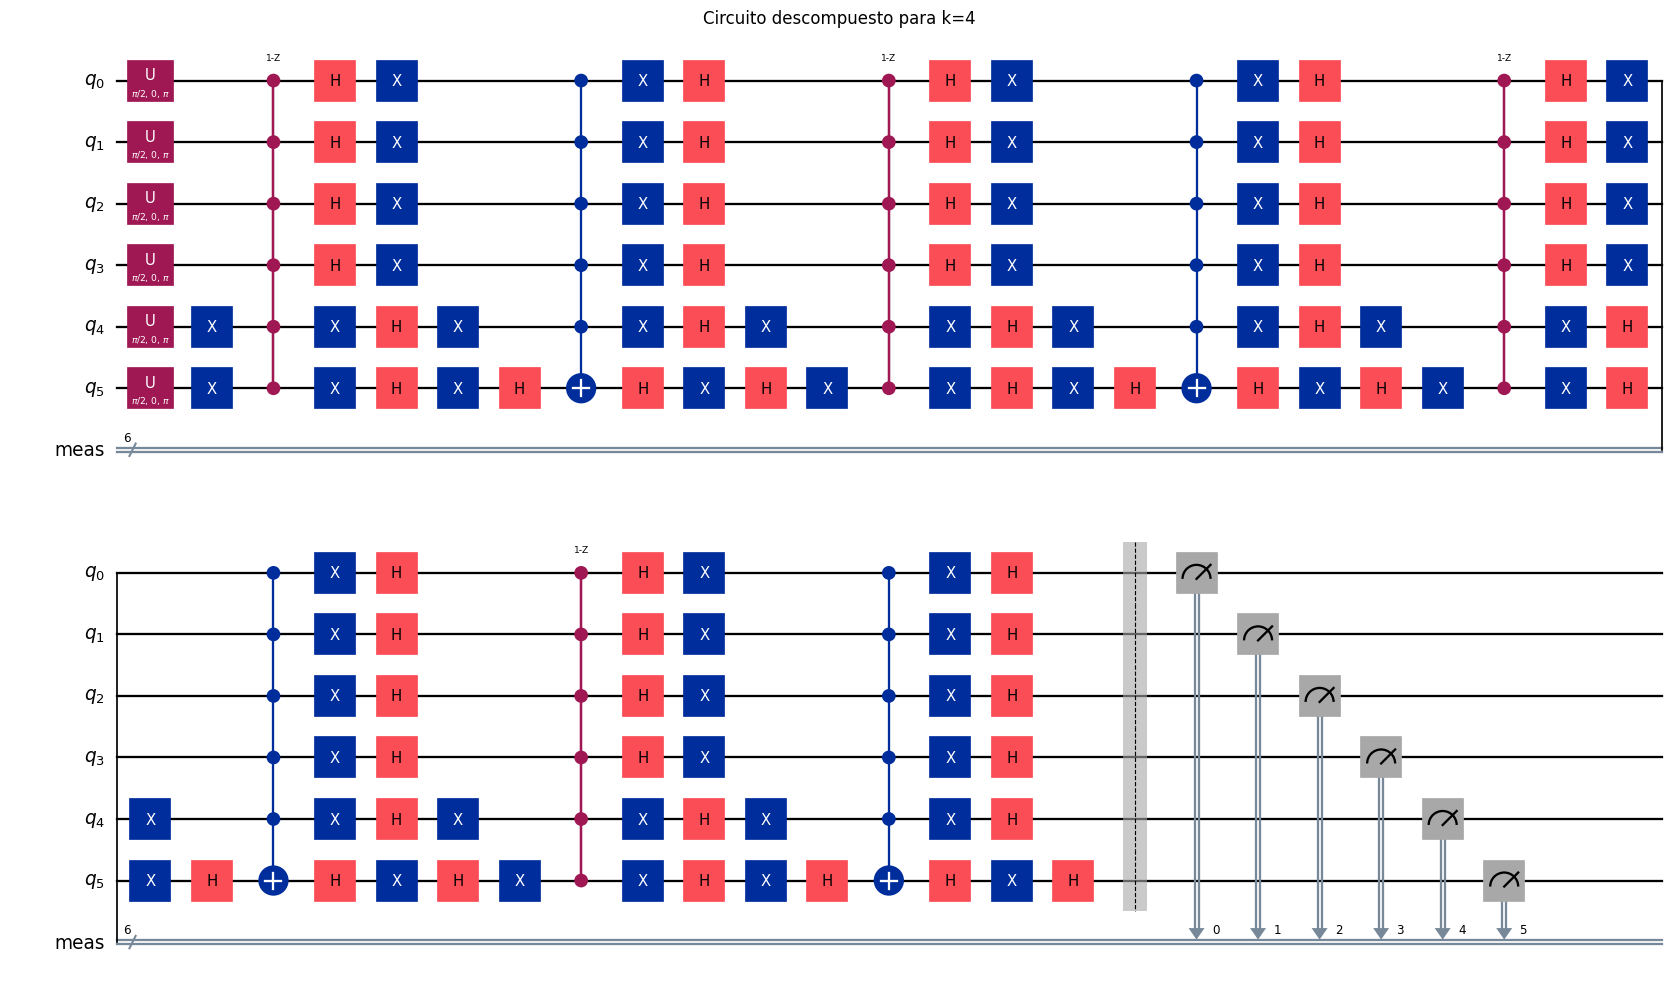

k=5:


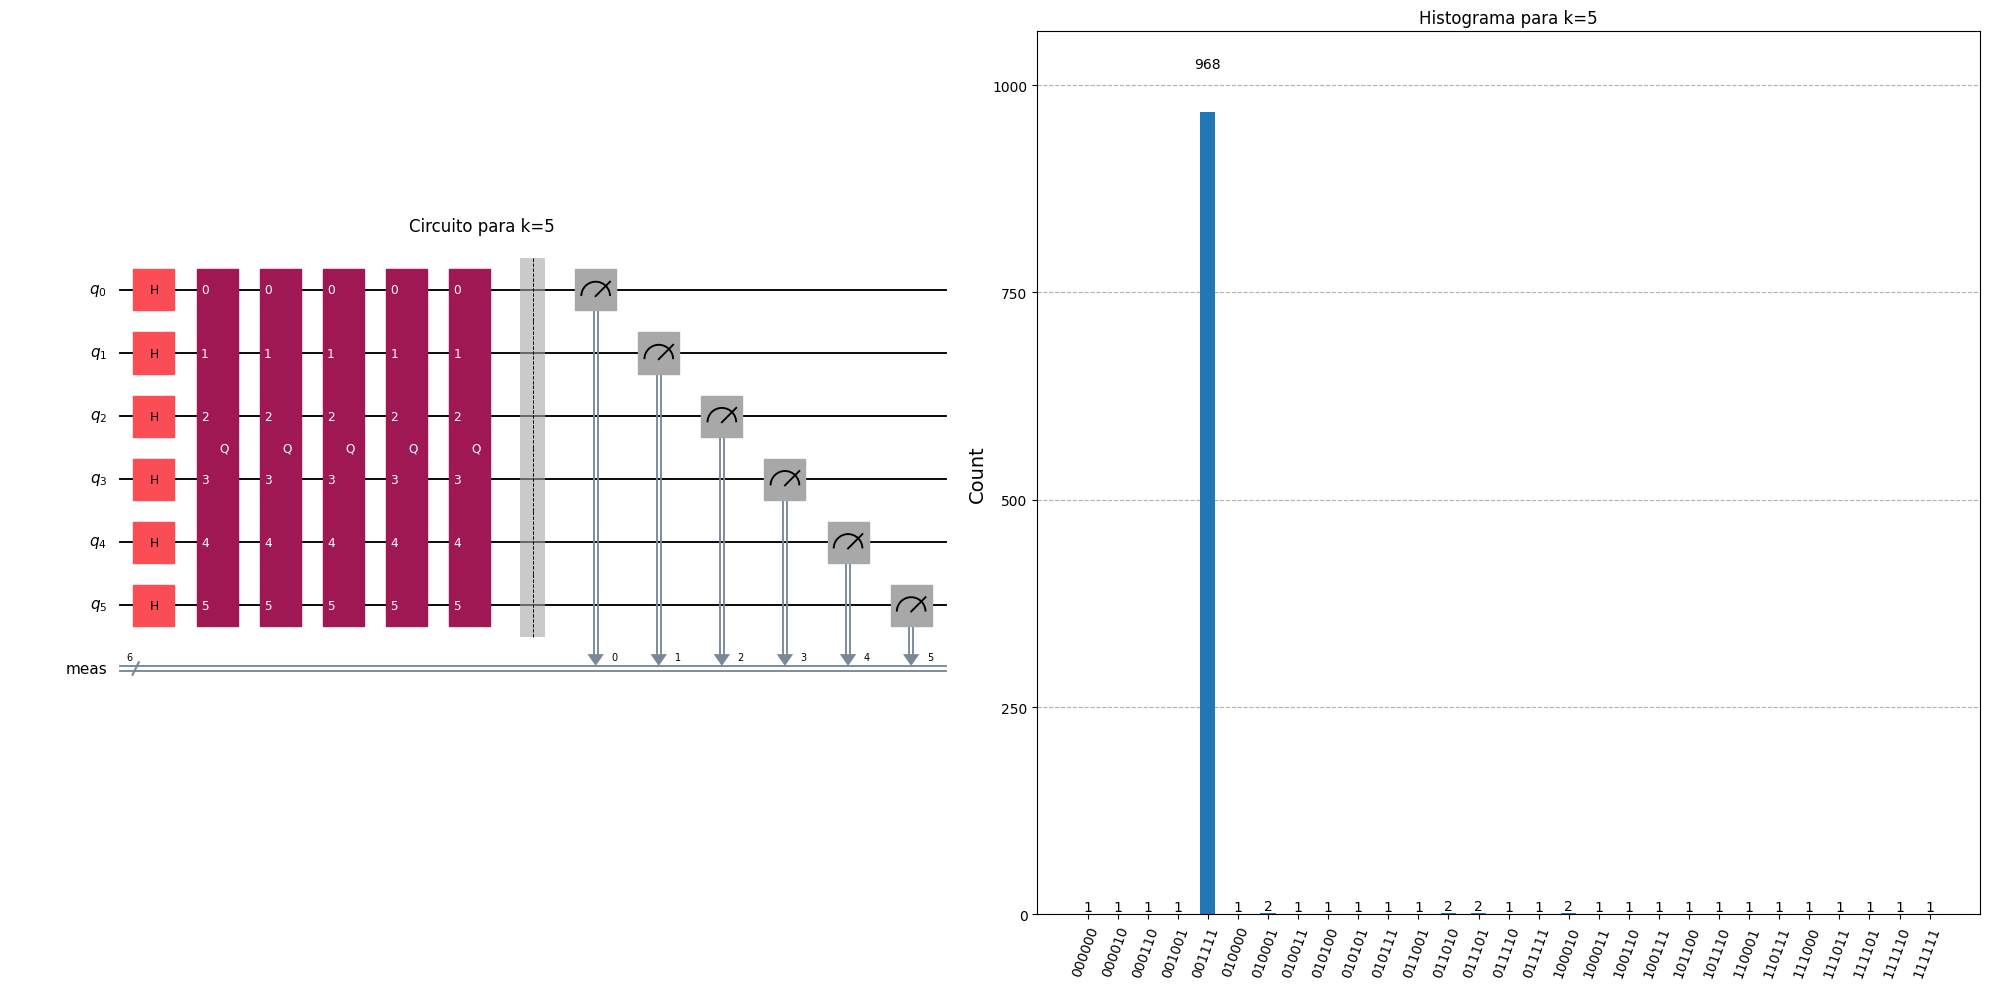

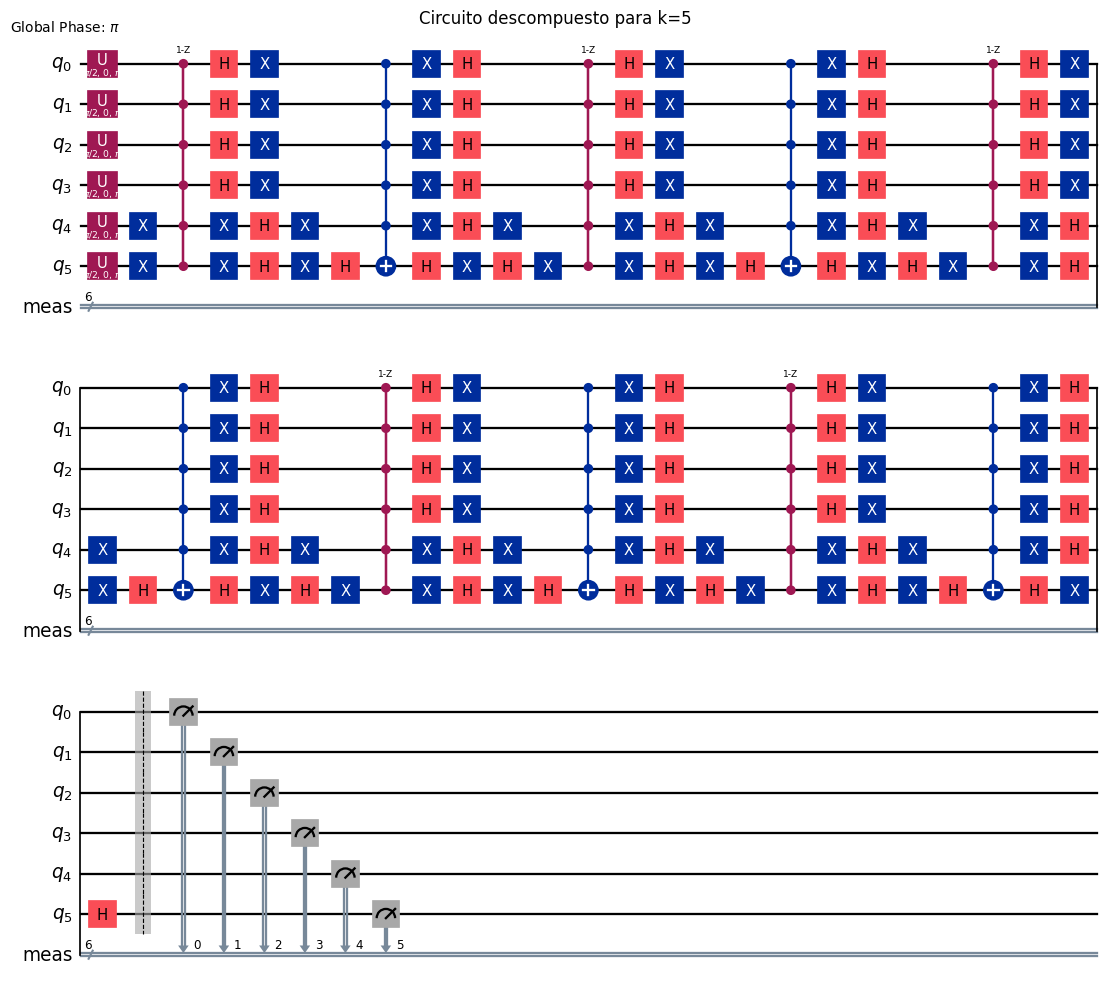

k=6:


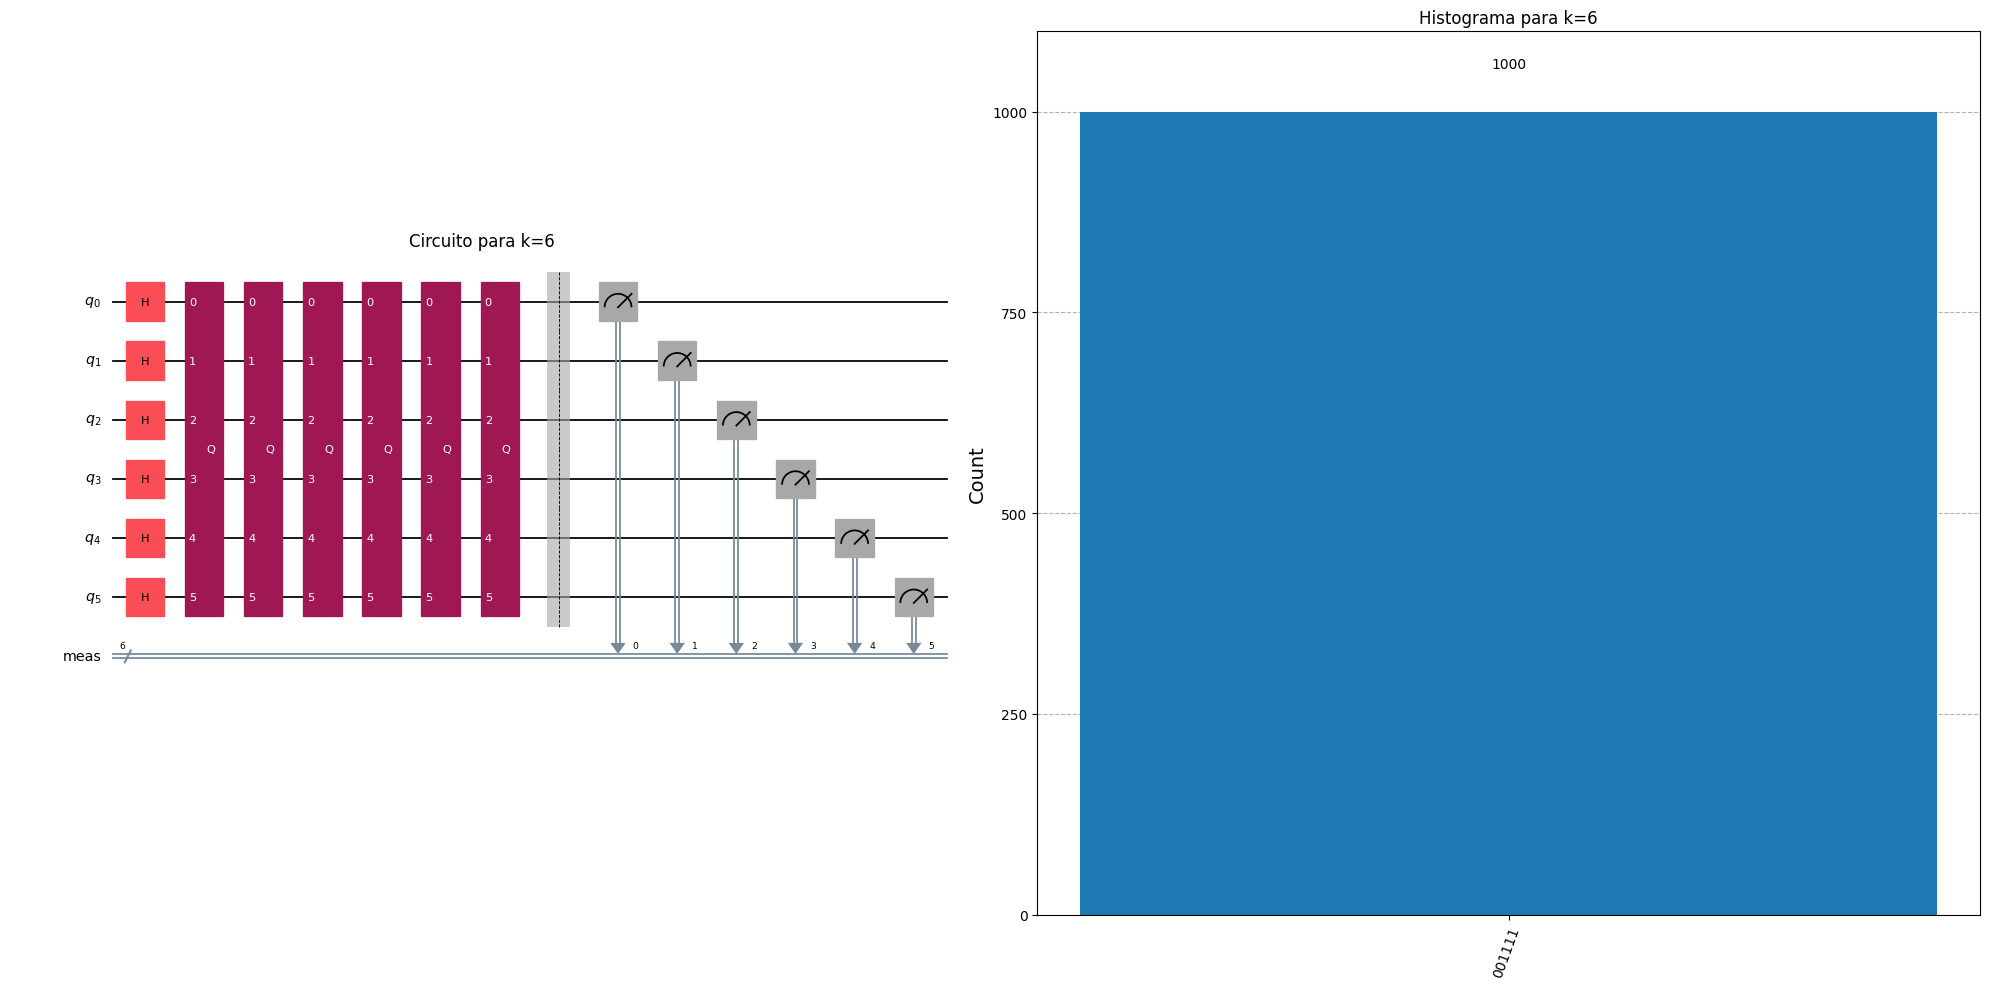

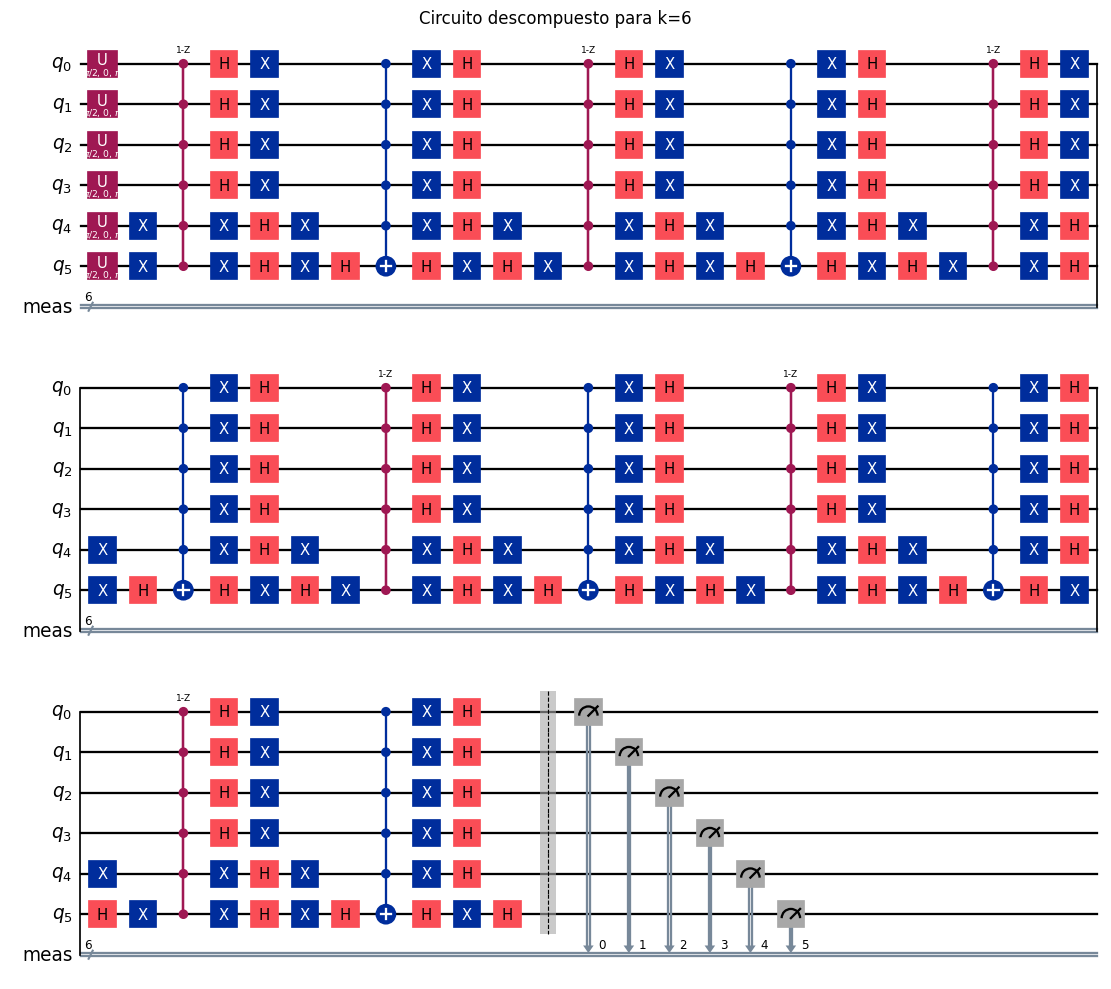

k=7:


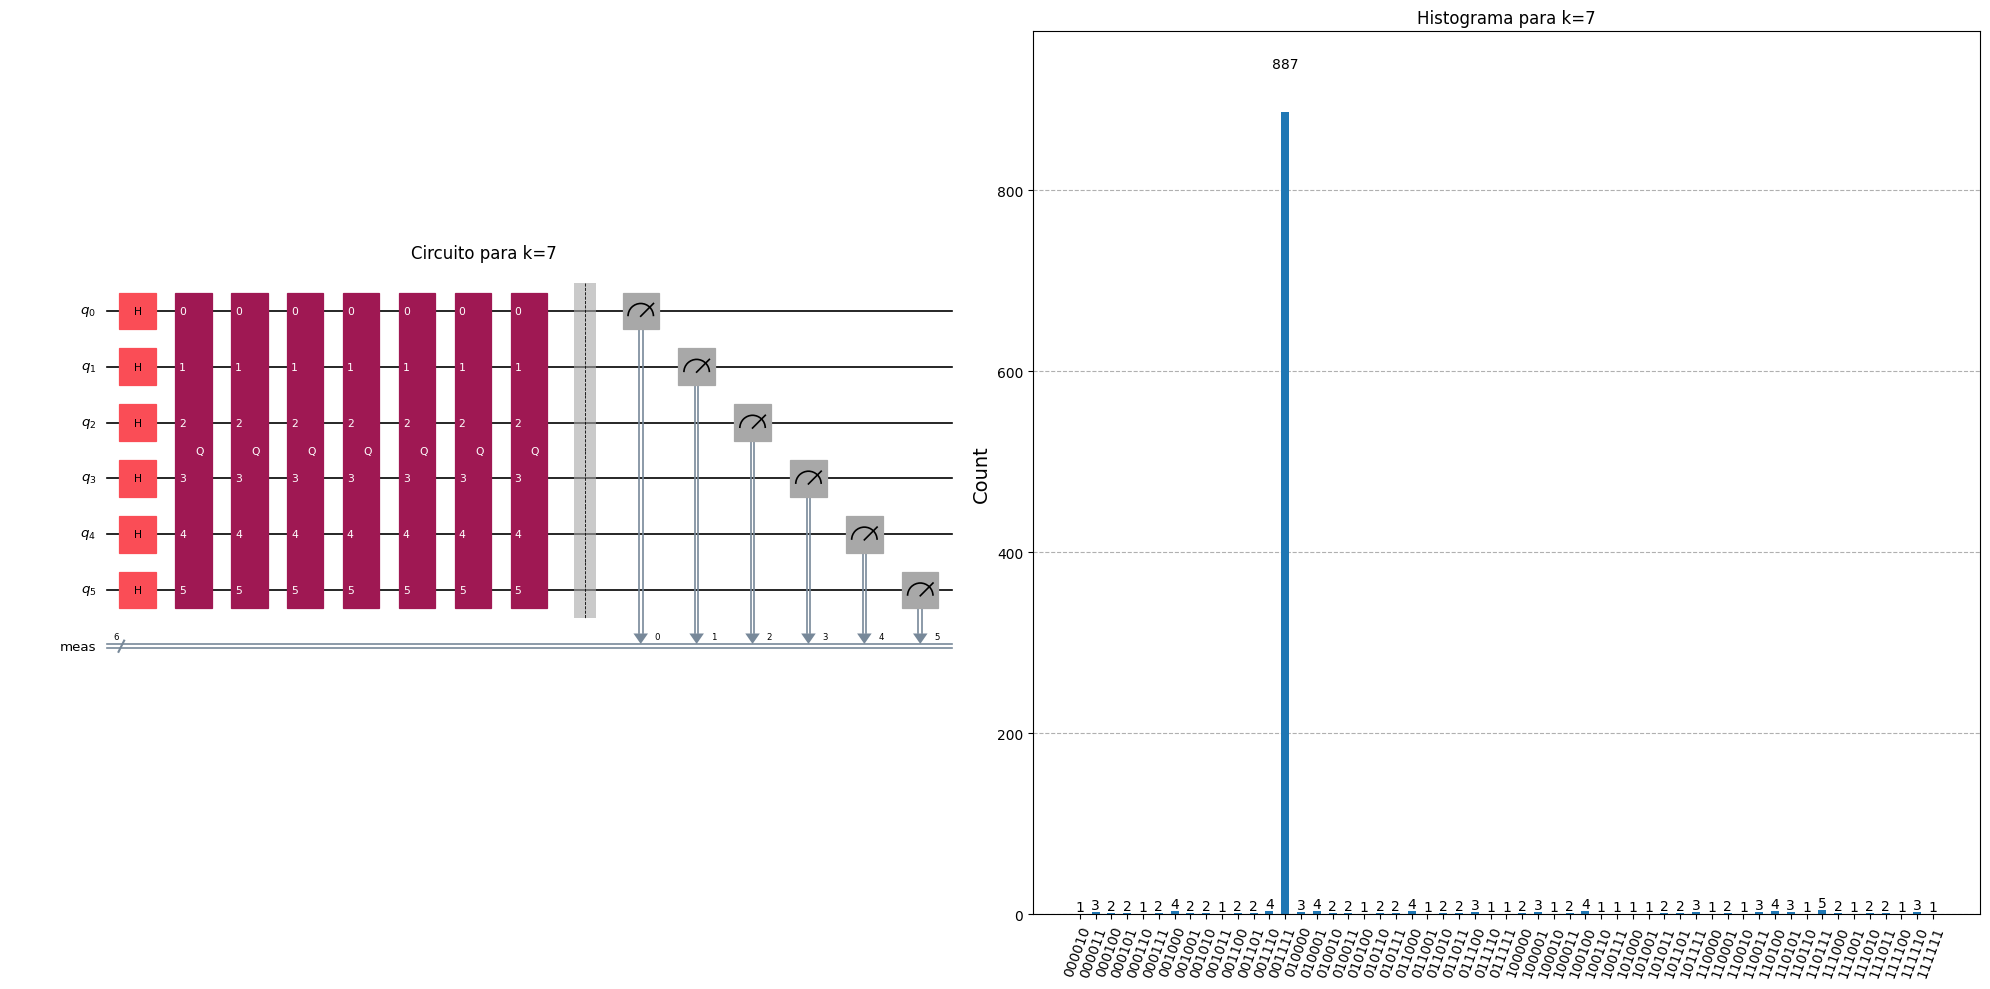

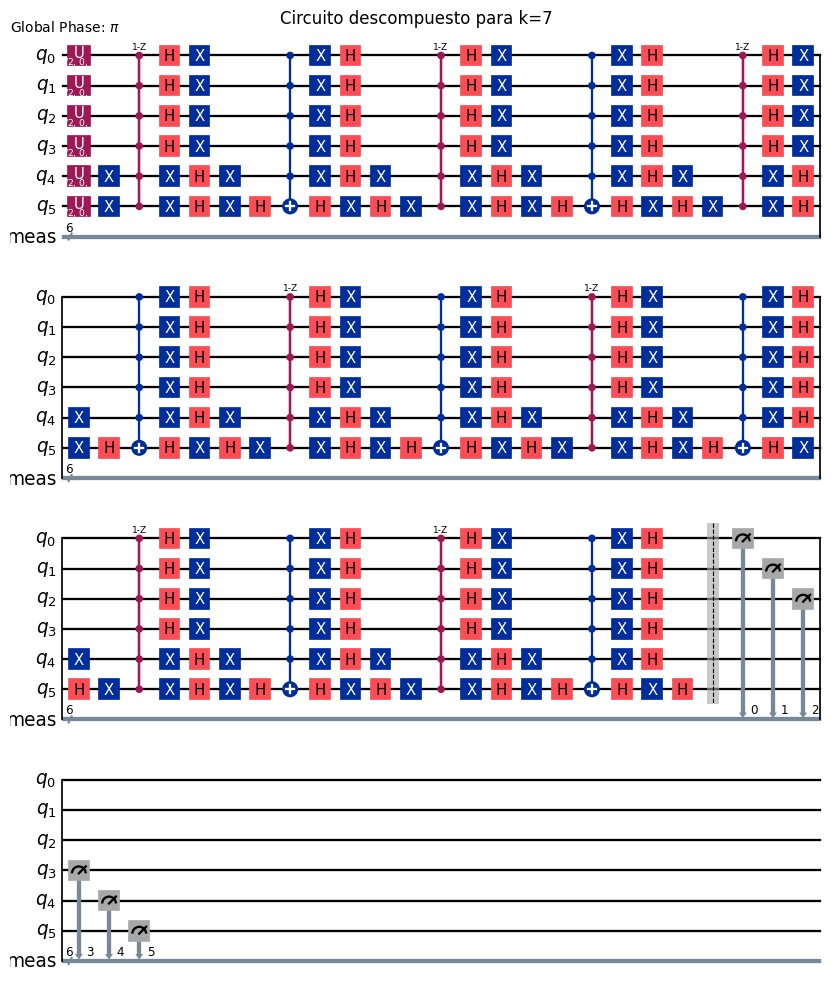

k=8:


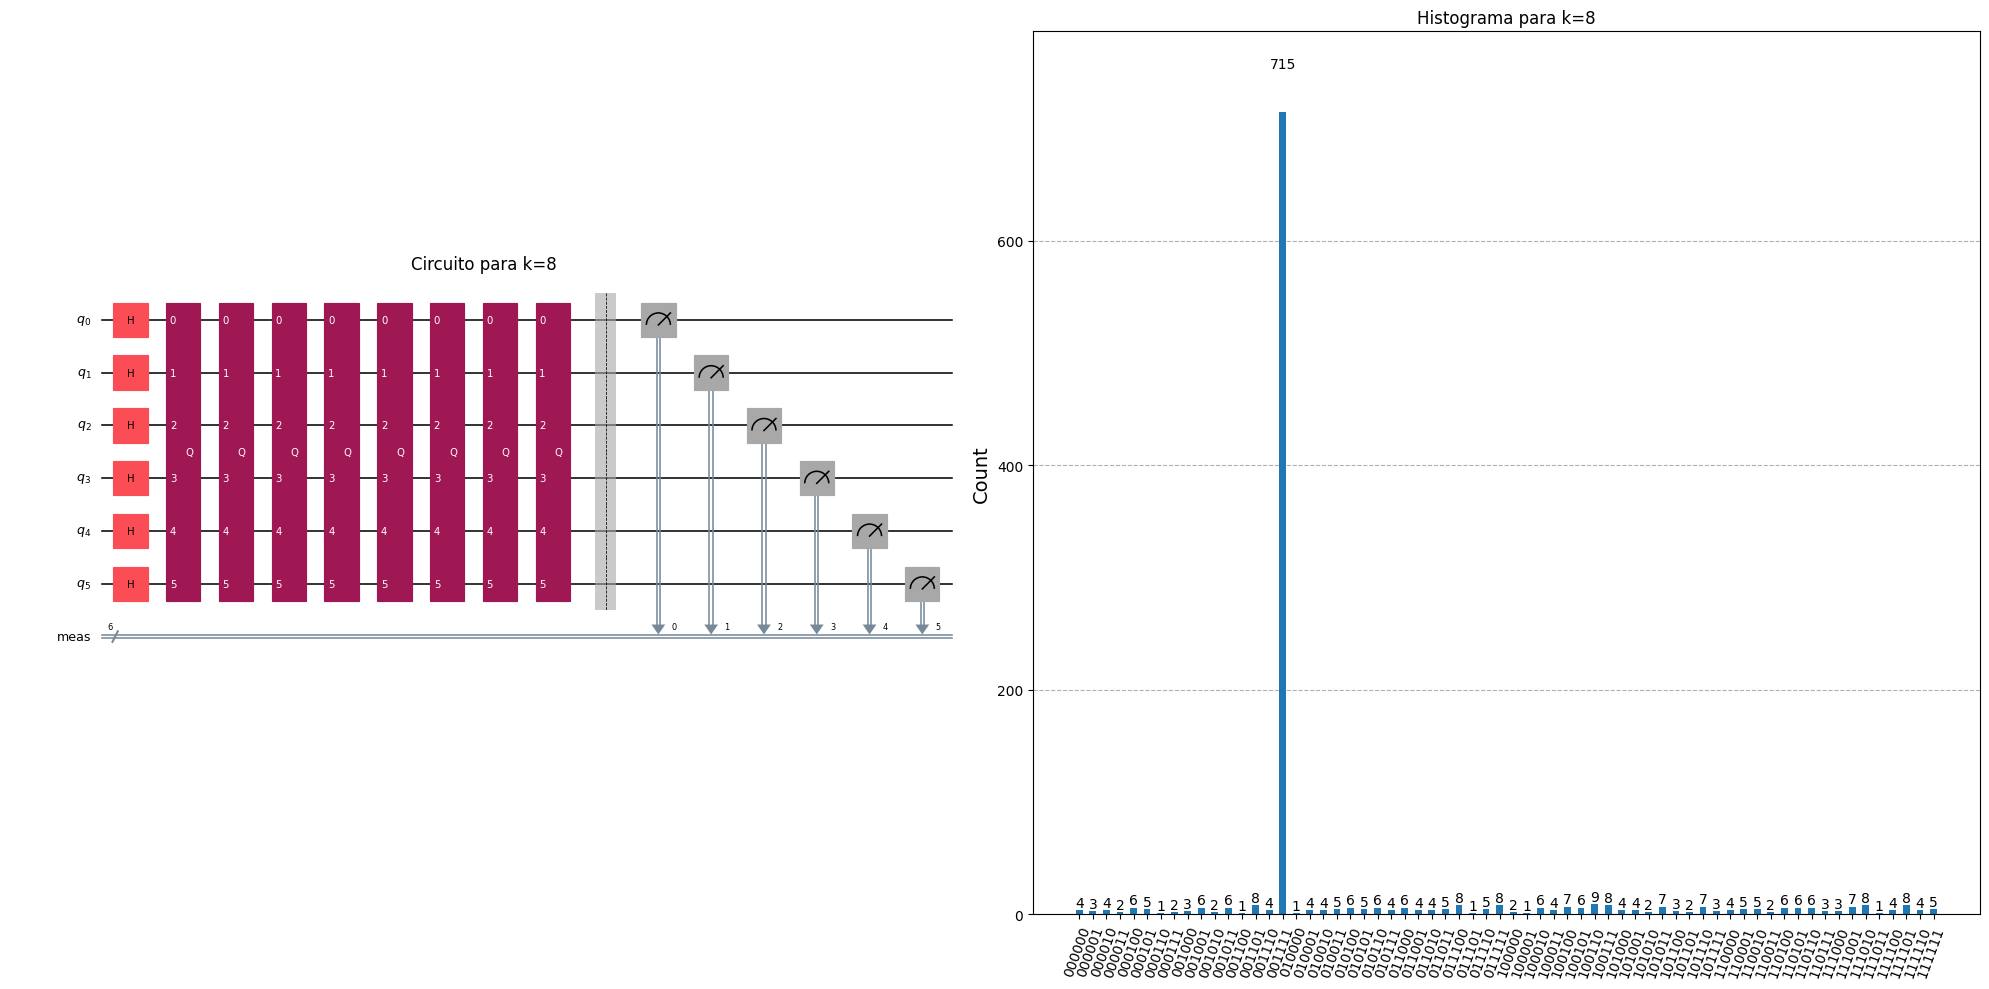

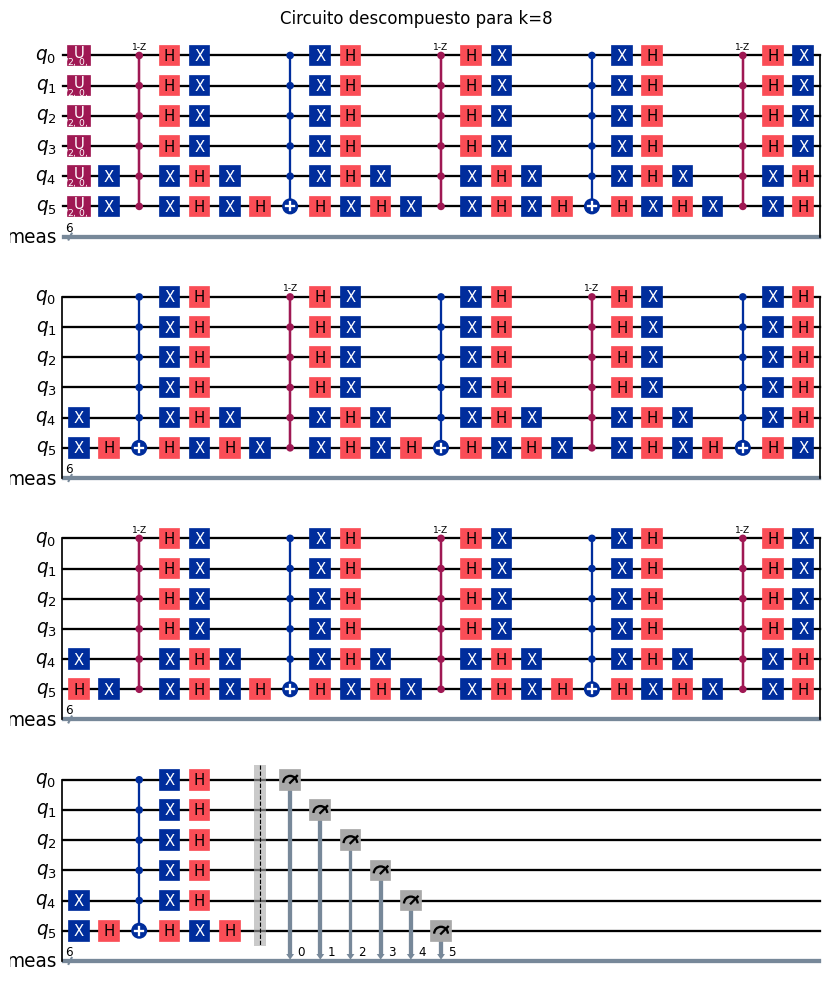

k=9:


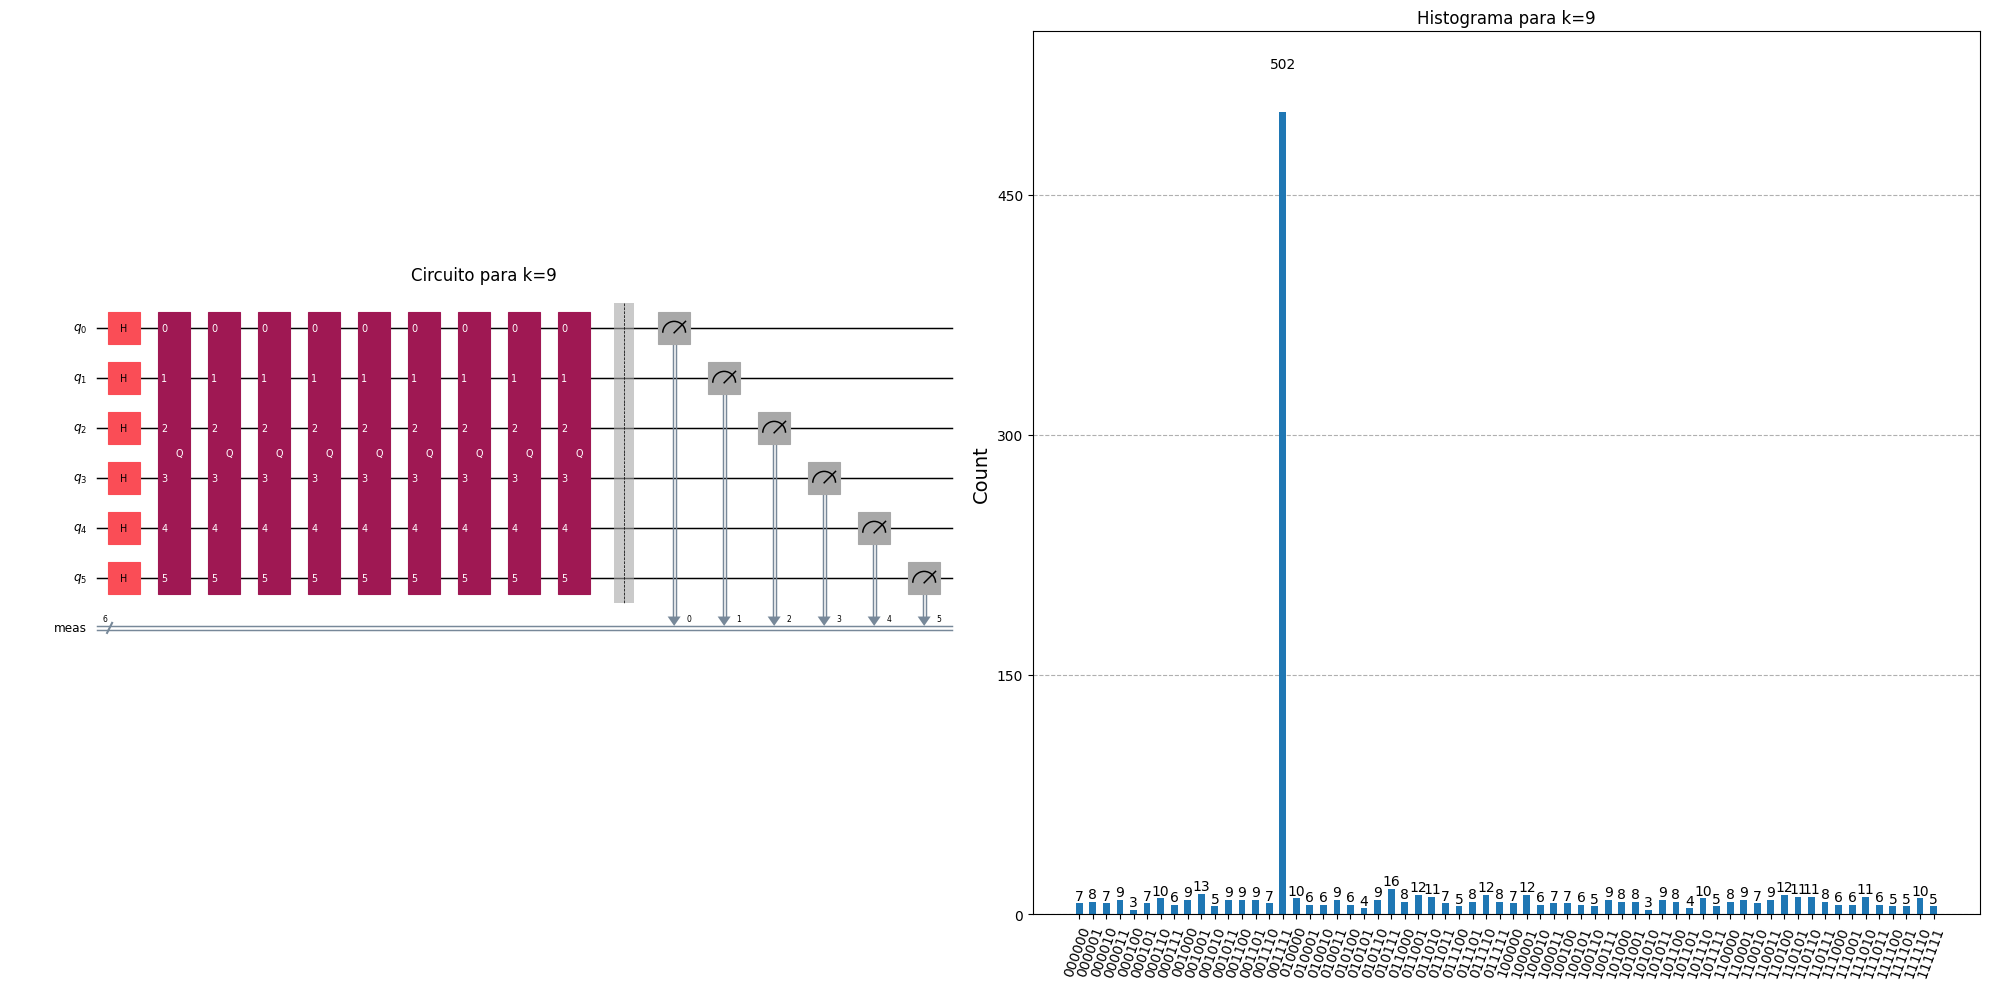

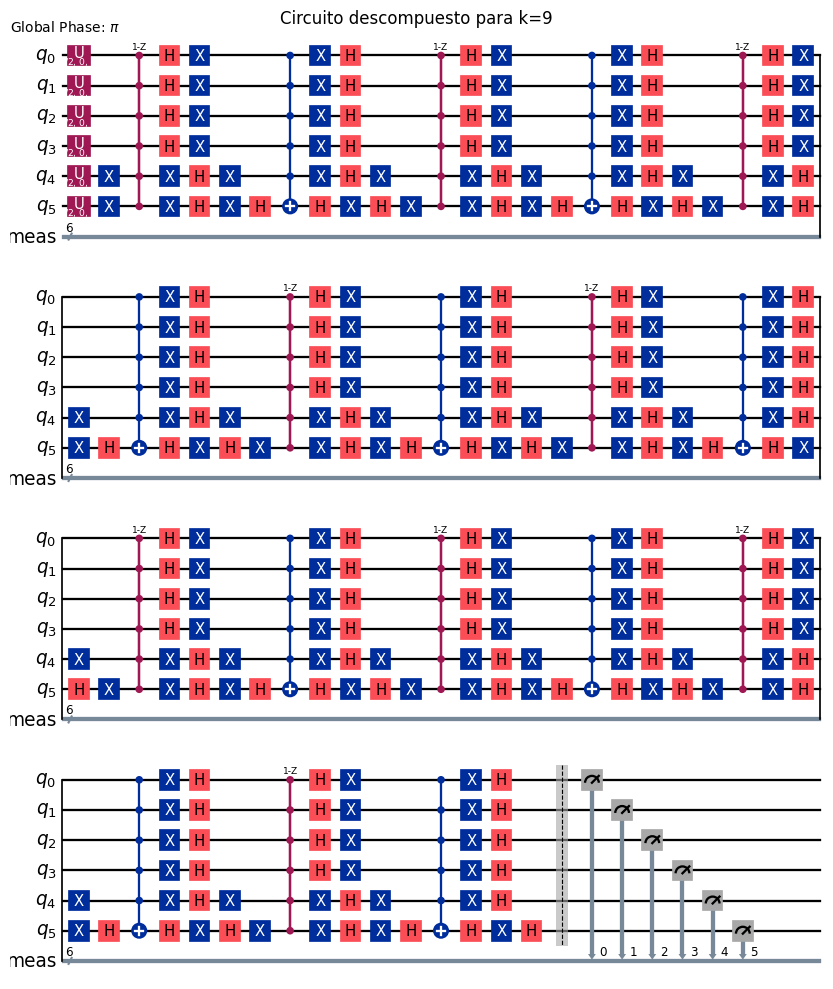

k=10:


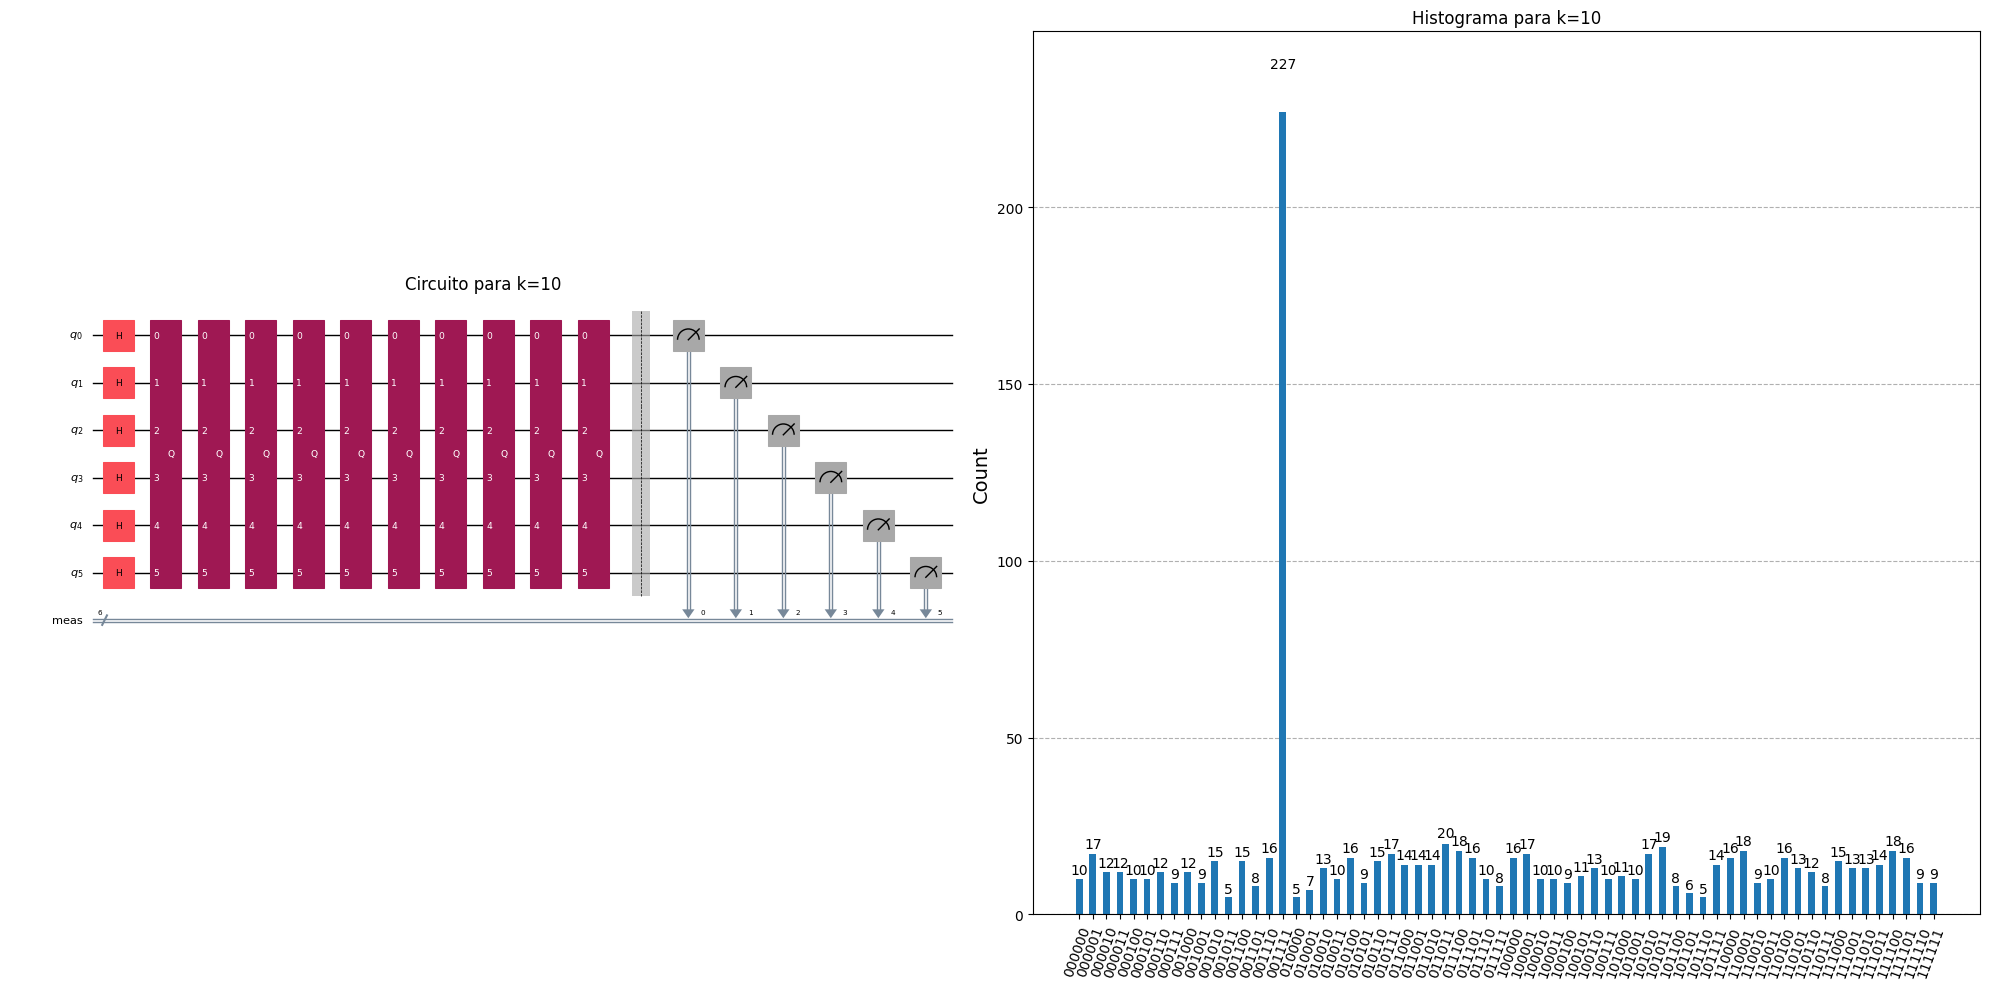

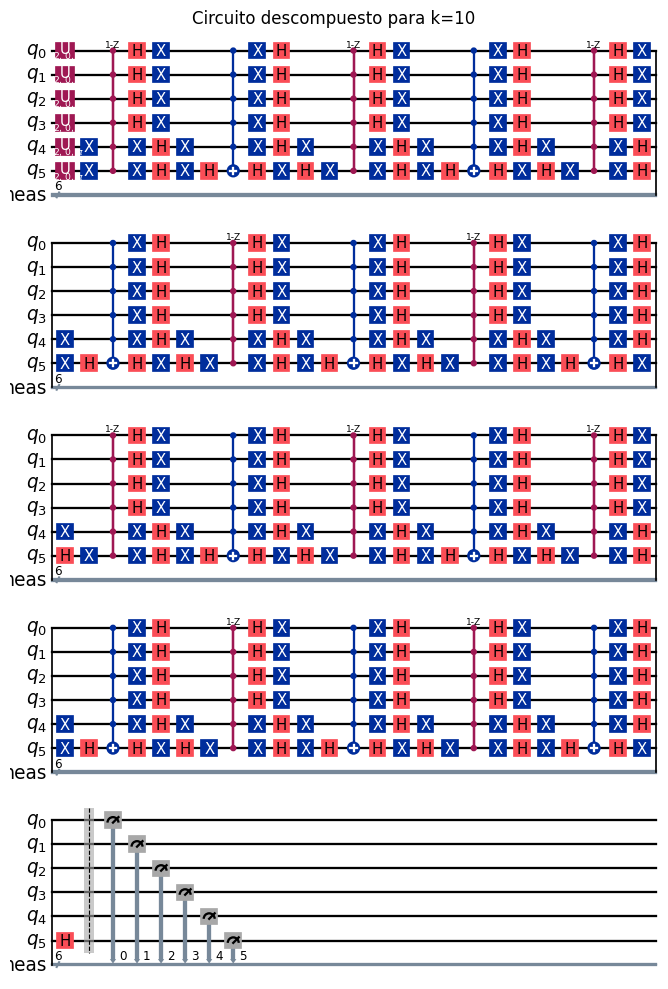

In [242]:
for k in range(1, 11):

    #Crea circuito
    qc = QuantumCircuit(num_qubits3)

    #Aplica hadamard a los qubits para crear superposición
    qc.h(range(num_qubits3))
    
    #Aplica Grover k veces
    qc.compose(grover_op3.power(k), inplace=True)
    
    #Obtener probabilidades
    sv = Statevector.from_instruction(qc)
    statistics = sv.sample_counts(1000)

    qc.measure_all()

    print(f"k={k}:")
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 2)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    qc.draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito para k={k}")

    plot_histogram(statistics, ax=ax2)
    ax2.set_title(f"Histograma para k={k}")

    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(1, 1)

    ax1 = fig.add_subplot(gs[0, 0])
    qc.decompose().draw(output="mpl", style="iqp", ax=ax1)
    ax1.set_title(f"Circuito descompuesto para k={k}")

    plt.tight_layout()
    plt.show()

    """display(qc.draw(output="mpl", style="iqp"))
    display(qc.decompose().draw(output="mpl", style="iqp"))
    display(plot_histogram(statistics))"""

Se obtiene la máxima probabilidad de obtener la solución experimentalmente con 6 iteraciones

In [243]:
#Calculo valor teorico de iteraciones
it_teoricas3 = (math.pi/4)*math.sqrt(q3**n3)
print("Valor teorico de iteraciones:", it_teoricas3)
it_teoricas_exacto3 = (math.pi/(4*math.asin(1/math.sqrt(q3**n3))))-(1/2)
print("Valor exacto de iteraciones teorico:", it_teoricas_exacto3)

Valor teorico de iteraciones: 6.283185307179586
Valor exacto de iteraciones teorico: 5.766749819872207


Seguimos el mismo procedimiento de los casos anteriores para calcular el entero óptimo de iteraciones.

In [244]:
prob_anterior3=math.sin(((2*5)+1)*math.asin(1/math.sqrt(q3**n3)))**2
prob_posterior3=math.sin(((2*6)+1)*math.asin(1/math.sqrt(q3**n3)))**2
print("Probabilidad de éxito con 5 iteraciones:", prob_anterior3)
print("Probabilidad de éxito con 6 iteraciones:", prob_posterior3)

Probabilidad de éxito con 5 iteraciones: 0.9635154816192113
Probabilidad de éxito con 6 iteraciones: 0.996585680786799


La diferencia entre las probabilidades es bastante pequeña, ya que ambas opciones parecen buenos candidatos. Sin embargo, el óptimo entero en este caso es 6 que coincide con los resultados experimentales.

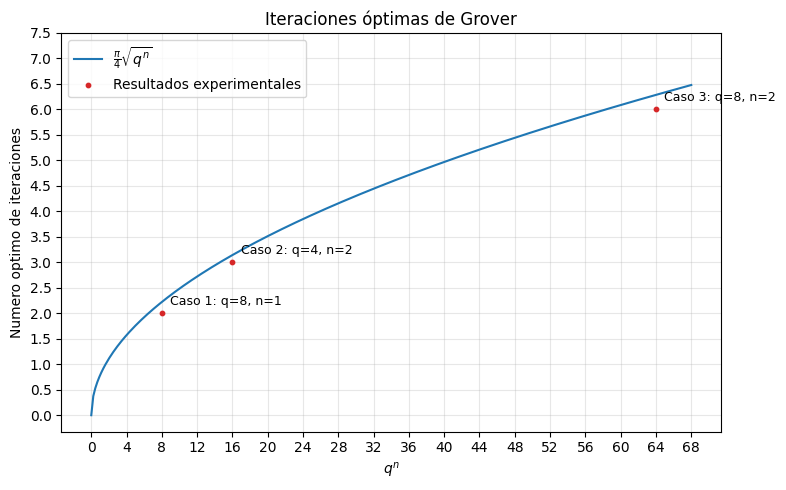

In [245]:
#Grafica comparativa: q^n frente al numero óptimo de iteraciones
x_exp = np.array([q1**n1, q2**n2, q3**n3])
y_ent = np.array([2, 3, 6])

x_teo = np.linspace(0, 68, 300)
y_teo = (math.pi / 4) * np.sqrt(x_teo)

plt.figure(figsize=(8, 5))
plt.plot(x_teo, y_teo, label=r'$\frac{\pi}{4}\sqrt{q^n}$', color='tab:blue')
plt.scatter(x_exp, y_ent, color='tab:red', s=10, label='Resultados experimentales', zorder=3)

etiquetas = [
    f'Caso 1: q={q1}, n={n1}',
    f'Caso 2: q={q2}, n={n2}',
    f'Caso 3: q={q3}, n={n3}'
]

for x, y, etiqueta in zip(x_exp, y_ent, etiquetas):
    plt.annotate(etiqueta, (x, y), textcoords='offset points', xytext=(6, 6), fontsize=9)

plt.xlabel(r'$q^n$')
plt.ylabel('Numero optimo de iteraciones')
plt.title('Iteraciones óptimas de Grover')
plt.xticks(np.arange(0, 70, 4))
plt.yticks(np.arange(0, 8, 0.5))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()